## Regional Financial Vulnerability Index (RFVI) Construction and Multi-Level Aggregation (2018-2024)

This notebook constructs the **Regional Financial Vulnerability Index (RFVI)** using the three structural pillars of vulnerability: **Sensitivity, Resilience, and Exposure (S-R-E)**.

It performs the complete workflow from data validation to national, regional, provincial, and city-level vulnerability analysis.

##### Workflow Overview

The notebook follows a structured sequence:

**1) Geographic Data Audit**

- Validates the presence and completeness of key geographic identifiers (Region, Province, City_Municipality) for each survey month
- Flags missing or placeholder values
- Ensures geographic consistency before aggregation

**2) Household-Level RFVI Construction**

- Decodes label-encoded categorical variables back to original names
- Normalizes Sensitivity, Resilience, and Exposure using Min-Max scaling (0-1)
- Computes Regional Financial Vulnerability Index (RFVI)

This produces the household-level vulnerability index for each survey month.

##### Multi-Level Aggregation and Analysis

After constructing RFVI at the household level, the notebook generates insights across geographic levels:

**3) National Trend (2018-2024)**

- Computes the national mean RFVI per survey month
- Visualizes the time trend of financial vulnerability

**4) Regional Monthly Aggregation**

- Aggregates household RFVI to the regional level
- Produces monthly regional averages

**5) Overall Regional Ranking (2018–2024)**

- Computes long-run regional mean RFVI
- Ranks regions from most to least vulnerable overall

**6) Monthly Top 10 Provincial Rankings**

- Identifies the 10 most vulnerable provinces per survey month
- Highlights shifting provincial vulnerability patterns

**7) Monthly Top 10 City/Municipality Rankings**

- Identifies the 10 most vulnerable cities/municipalities per survey month
- Shows how vulnerability at a city/municipality level changes over time

**8) Regional SRE Structural Decomposition**

- Aggregates Sensitivity, Resilience, and Exposure at the regional level
- Examines which pillar drives vulnerability in each region
- Establishes structural interpretation prior to clustering

All processed datasets and visualizations are saved in the `Survey Data with Factor Scores and RFVI` folder.

---
### Audit of Geographic Data

This script performs a month-by-month audit of geographic identifiers in the master survey datasets.

Process:

- For each month, the script checks whether the key geographic columns `Region`, `Province`, and `City_Municipality` exist and are valid
- Columns with missing data or placeholders (like "Unknown City") are flagged as MISSING, while complete entries are flagged as COMPLETE

Purpose:
- Ensures that geographic pillars are consistently available across all survey months
- Helps identify months or files with missing or placeholder values before further analysis or RFVI construction

In [1]:
import pandas as pd
from pathlib import Path
import json
import os

# --- 1. LOAD CONFIGURATION ---
with open(Path("./data/interim/config.json")) as f:
    cfg = json.load(f)

BASE_PATH = Path(cfg["BASE_PATH"])
MASTER_DATA_ROOT = BASE_PATH / "Survey Datasets Master (Pooled Scores)"

# Define chronological order for sorting
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

def get_sort_key(folder_name):
    """Extracts year and month index for chronological sorting."""
    parts = folder_name.split('_')
    if len(parts) == 2:
        year = int(parts[0])
        month_idx = month_order.index(parts[1])
        return (year, month_idx)
    return (0, 0)

def audit_full_chronological_geo():
    if not MASTER_DATA_ROOT.exists():
        print(f"Error: Path not found: {MASTER_DATA_ROOT}")
        return

    # 1. Get and Sort Folders Chronologically
    month_folders = [d.name for d in MASTER_DATA_ROOT.iterdir() if d.is_dir()]
    sorted_folders = sorted(month_folders, key=get_sort_key)
    
    print(f"\nAUDITING {len(sorted_folders)} MONTHS FOR GEOGRAPHIC PILLARS")
    print("=" * 110)
    # Removed Status from the header
    header = f"{'Year':<6} | {'Month':<12} | {'Region':<12} | {'Province':<12} | {'City_Municipality':<25}"
    print(header)
    print("-" * 110)

    for folder_name in sorted_folders:
        year, month = folder_name.split('_')
        file_path = MASTER_DATA_ROOT / folder_name / f"Master_SRE_{folder_name}.csv"
        
        if not file_path.exists():
            print(f"{year:<6} | {month:<12} | {'MISSING':<12} | {'MISSING':<12} | {'FILE NOT FOUND':<25}")
            continue

        try:
            # Read first 5 rows to detect placeholder values
            df_sample = pd.read_csv(file_path, nrows=5)
            df_cols = df_sample.columns.tolist()
            
            # Check Region and Province
            reg_status = "COMPLETE" if "Region" in df_cols else "MISSING"
            prv_status = "COMPLETE" if "Province" in df_cols else "MISSING"
            
            # Detailed check for City_Municipality
            if "City_Municipality" not in df_cols:
                cty_status = "MISSING"
            else:
                # Check if the column is filled with "Unknown City"
                sample_values = df_sample["City_Municipality"].astype(str).tolist()
                if any("Unknown City" in val for val in sample_values):
                    cty_status = "MISSING" # Per your requirement to flag placeholders as Missing
                else:
                    cty_status = "COMPLETE"
            
            # Print row without the overall Status column
            print(f"{year:<6} | {month:<12} | {reg_status:<12} | {prv_status:<12} | {cty_status:<25}")

        except Exception as e:
            print(f"{year:<6} | {month:<12} | ERROR: {str(e)[:40]}")

if __name__ == "__main__":
    audit_full_chronological_geo()


AUDITING 40 MONTHS FOR GEOGRAPHIC PILLARS
Year   | Month        | Region       | Province     | City_Municipality        
--------------------------------------------------------------------------------------------------------------
2018   | January      | COMPLETE     | COMPLETE     | MISSING                  
2018   | April        | COMPLETE     | COMPLETE     | MISSING                  
2018   | July         | COMPLETE     | COMPLETE     | MISSING                  
2018   | October      | COMPLETE     | COMPLETE     | MISSING                  
2019   | January      | COMPLETE     | COMPLETE     | MISSING                  
2019   | April        | COMPLETE     | COMPLETE     | MISSING                  
2019   | July         | COMPLETE     | COMPLETE     | MISSING                  
2019   | October      | COMPLETE     | COMPLETE     | MISSING                  
2022   | January      | COMPLETE     | COMPLETE     | COMPLETE                 
2022   | February     | COMPLETE     | COMPLET

The audit shows that **Region and Province columns are complete for all months**, while **City/Municipality data are missing for 2018 and 2019** due to survey design.

This indicates that geographic identifiers are generally consistent, with only the earliest surveys lacking detailed city/municipality information.

---
### Household-Level Regional Financial Vulnerability Index (RFVI) Construction

Household-level RFVI is computed after decoding previously **label-encoded categorical values back to their original names.**

**For each survey month:**

- Encoded region, demographic, and employment variables are **decoded back to their original labels**
- Sensitivity, Resilience, and Exposure scores are normalized using Min-Max scaling (0–1)

**RFVI** is calculated as:
    $$RFVI = \frac{\text{Sensitivity} + (1 - \text{Resilience}) + \text{Exposure}}{3}$$

Where:
- Higher Sensitivity increases vulnerability
- Higher Exposure increases vulnerability
- Higher Resilience reduces vulnerability *(Note: Resilience is inverted as vulnerability increases when it decreases)*

This process produces the household-level vulnerability index with fully decoded variables, ready for aggregation or further analysis.

The datasets are saved in `Survey Data with Factor Scores and RFVI` folder.

In [2]:
import pandas as pd
from pathlib import Path
import json
import os
import gc

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Datasets Master (Pooled Scores)"
    OUTPUT_ROOT = BASE_PATH / "Survey Data with Factor Scores and RFVI"
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    print(f"Configuration Loaded. Saving to: {OUTPUT_ROOT}")
except Exception as e:
    print(f"Error loading config: {e}")

# --- 2. MASTER DECODER (Updated with Full Regional Names) ---
MASTER_DECODE = {
    'Work Indicator': {0: 'no', 1: 'yes'},
    'C04-Sex': {0: 'female', 1: 'male'},
    'Region': {
        0: 'Autonomous Region in Muslim Mindanao (ARMM)', 
        1: 'Cordillera Administrative Region (CAR)', 
        2: 'National Capital Region (NCR)', 
        3: 'Region I (Ilocos Region)', 
        4: 'Region II (Cagayan Valley)',
        5: 'Region III (Central Luzon)', 
        6: 'Region IV-A (CALABARZON)', 
        7: 'Region IV-B (MIMAROPA)', 
        8: 'Region IX (Zamboanga Peninsula)',
        9: 'Region V (Bicol Region)', 
        10: 'Region VI (Western Visayas)', 
        11: 'Region VII (Central Visayas)', 
        12: 'Region VIII (Eastern Visayas)',
        13: 'Region X (Northern Mindanao)', 
        14: 'Region XI (Davao Region)', 
        15: 'Region XII (SOCCSKSARGEN)', 
        16: 'Region XIII (Caraga)'
    },
    'Available for Work': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'Look for Additional Work': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'Looked for Work or Tried to Establish Business During the Past Week': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'Previous Job Indicator': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'Want More Hours of Work': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'Other Job Indicator': {0: 'no', 1: 'not applicable', 2: 'yes'},
    'C03-Relationship to Household Head': {
        0: 'boarder', 1: 'child', 2: 'domestic helper', 3: 'grandchild', 
        4: 'head', 5: 'in-law relative', 6: 'non-relative', 7: 'other relative', 
        8: 'parent', 9: 'sibling', 10: 'spouse'
    },
    'C06-Marital Status': {
        0: 'annulled', 1: 'divorced/separated', 2: 'married or common-law/live-in', 
        3: 'single', 4: 'unknown', 5: 'widowed'
    },
    'New Employment Criteria (jul 05, 2005)': {0: 'employed', 1: 'not in the labor force', 2: 'unemployed'},
    'C05-Age as of Last Birthday': {
        0: '00 - 14', 1: '15 - 24', 2: '25 - 34', 3: '35 - 44', 
        4: '45 - 54', 5: '55 - 64', 6: '65 and over'
    }
}

def normalize(series):
    """Min-Max scaling to 0-1 range."""
    if series.max() == series.min():
        return series * 0.0
    return (series - series.min()) / (series.max() - series.min())

def construct_rfvi_idempotent():
    month_folders = sorted([d for d in SOURCE_DIR.iterdir() if d.is_dir()])
    
    print(f"Processing {len(month_folders)} months to decode variables and construct RFVI...")
    print("-" * 75)

    for folder in month_folders:
        source_file = folder / f"Master_SRE_{folder.name}.csv"
        out_month_dir = OUTPUT_ROOT / folder.name
        save_path = out_month_dir / f"RFVI_{folder.name}.csv"

        if save_path.exists():
            print(f"   [SKIP] {folder.name} already processed.")
            continue

        if not source_file.exists():
            print(f"   [WARN] {folder.name}: Source file not found.")
            continue

        print(f"   [RUN]  Decoding & Processing {folder.name}...", end="\r")

        try:
            df = pd.read_csv(source_file, low_memory=False)

            # --- DECODING STEP ---
            for col, mapping in MASTER_DECODE.items():
                if col in df.columns:
                    df[col] = df[col].map(mapping)

            # --- NORMALIZATION & RFVI ---
            df['Sensitivity_norm'] = normalize(df['Sensitivity_Score'])
            df['Resilience_norm']  = normalize(df['Resilience_Score'])
            df['Exposure_norm']    = normalize(df['Exposure_Score'])

            df['RFVI'] = (df['Sensitivity_norm'] + (1 - df['Resilience_norm']) + df['Exposure_norm']) / 3

            # --- SAVE ---
            os.makedirs(out_month_dir, exist_ok=True)
            df.to_csv(save_path, index=False)

            del df
            gc.collect()

        except Exception as e:
            print(f"\n   [ERR]  Failed to process {folder.name}: {e}")

    print("\n" + "="*75)
    print("CONSTRUCTION COMPLETE: FULLY DECODED VARIABLE NAMES SAVED.")
    print("="*75)

if __name__ == "__main__":
    construct_rfvi_idempotent()

Configuration Loaded. Saving to: G:\My Drive\Labor Force Survey\Survey Data with Factor Scores and RFVI
Processing 40 months to decode variables and construct RFVI...
---------------------------------------------------------------------------
   [SKIP] 2018_April already processed.
   [SKIP] 2018_January already processed.
   [SKIP] 2018_July already processed.
   [SKIP] 2018_October already processed.
   [SKIP] 2019_April already processed.
   [SKIP] 2019_January already processed.
   [SKIP] 2019_July already processed.
   [SKIP] 2019_October already processed.
   [SKIP] 2022_April already processed.
   [SKIP] 2022_August already processed.
   [SKIP] 2022_December already processed.
   [SKIP] 2022_February already processed.
   [SKIP] 2022_January already processed.
   [SKIP] 2022_July already processed.
   [SKIP] 2022_June already processed.
   [SKIP] 2022_March already processed.
   [SKIP] 2022_May already processed.
   [SKIP] 2022_November already processed.
   [SKIP] 2022_October 

---
### Direct National RFVI Trend (2018-2024)

This calculates the national average RFVI from all observations for each survey month.

Visualization:

- A line chart displays the national mean RFVI over time
- Each point represents the overall national vulnerability for that survey period

Calculating Direct National Means for 40 months...


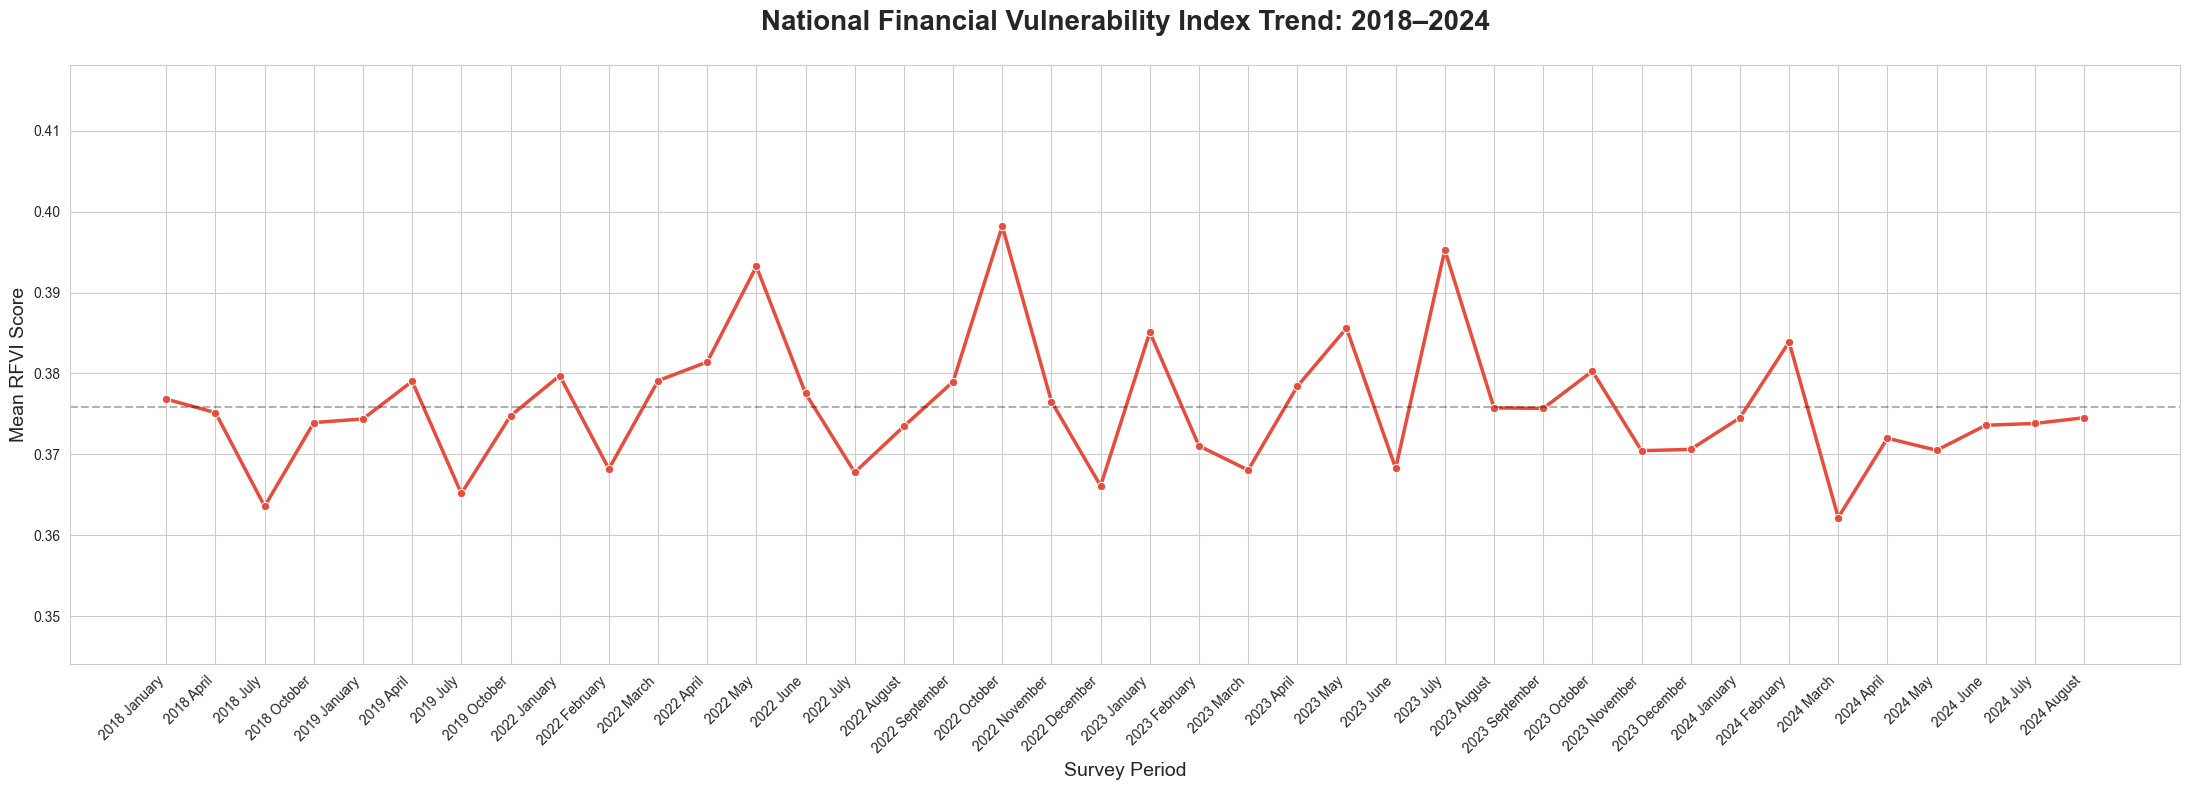

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import gc

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
except Exception as e:
    print(f"Error loading config: {e}")

# Strict chronological order for X-axis sorting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

def get_direct_national_trend():
    all_monthly_data = []
    
    # 1. Get and sort folders chronologically
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    
    def sort_key(f):
        parts = f.name.split('_')
        return (int(parts[0]), month_order.index(parts[1]))
    
    sorted_folders = sorted(folders, key=sort_key)
    
    print(f"Calculating Direct National Means for {len(sorted_folders)} months...")

    for folder in sorted_folders:
        year_val, month_val = folder.name.split('_')
        file_path = folder / f"RFVI_{folder.name}.csv"
        
        if file_path.exists():
            try:
                # 2. Load ONLY the RFVI column to be extremely RAM efficient
                df = pd.read_csv(file_path, usecols=['RFVI'], low_memory=False)
                
                # 3. Calculate the mean of all observations in the file
                national_mean = df['RFVI'].mean()
                
                # 4. Store as a single row for this month
                all_monthly_data.append({
                    'Period': f"{year_val} {month_val}",
                    'Year': int(year_val),
                    'Month': month_val,
                    'RFVI': national_mean
                })
                
                print(f"   Processed: {folder.name}", end="\r")
                del df
                gc.collect()
            except Exception as e:
                print(f"   [ERR] Skipping {folder.name}: {e}")
            
    return pd.DataFrame(all_monthly_data)

# --- EXECUTION ---
trend_df = get_direct_national_trend()

# --- 2. VISUALIZATION ---
plt.figure(figsize=(22, 8))
sns.set_style("whitegrid")

# Calculate dynamic limits for a better "zoom"
y_min = trend_df['RFVI'].min() * 0.95  # 5% below the lowest point
y_max = trend_df['RFVI'].max() * 1.05  # 5% above the highest point

ax = sns.lineplot(
    data=trend_df, 
    x='Period', 
    y='RFVI', 
    marker='o', 
    color='#e74c3c', 
    linewidth=2.5
)

# Formatting
plt.title("National Financial Vulnerability Index Trend: 2018–2024", 
          fontsize=20, weight='bold', pad=25)
plt.ylabel("Mean RFVI Score", fontsize=14)
plt.xlabel("Survey Period", fontsize=14)

# Set the axis to focus on the data range
plt.ylim(y_min, y_max) 

# Optional: Add horizontal lines for the overall mean to show peaks/valleys
plt.axhline(trend_df['RFVI'].mean(), color='black', linestyle='--', alpha=0.3, label='Overall Mean')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
### Regional Aggregation and Monthly RFVI Summaries

After computing household-level RFVI, the RFVI is aggregated at the **regional level**.

**For each survey month:**
- Household RFVI values are aggregated by Region
- Mean RFVI per region is computed per month

This is the **regional aggregation phase** of RFVI construction.

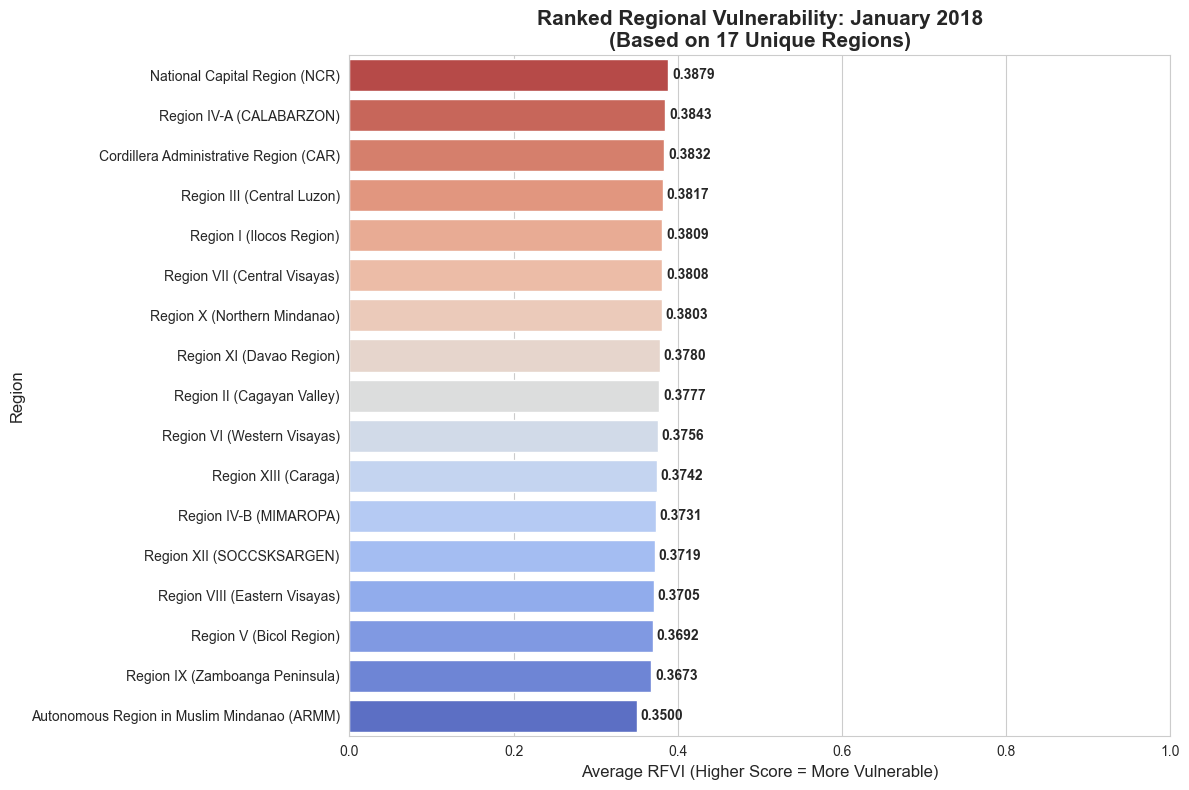

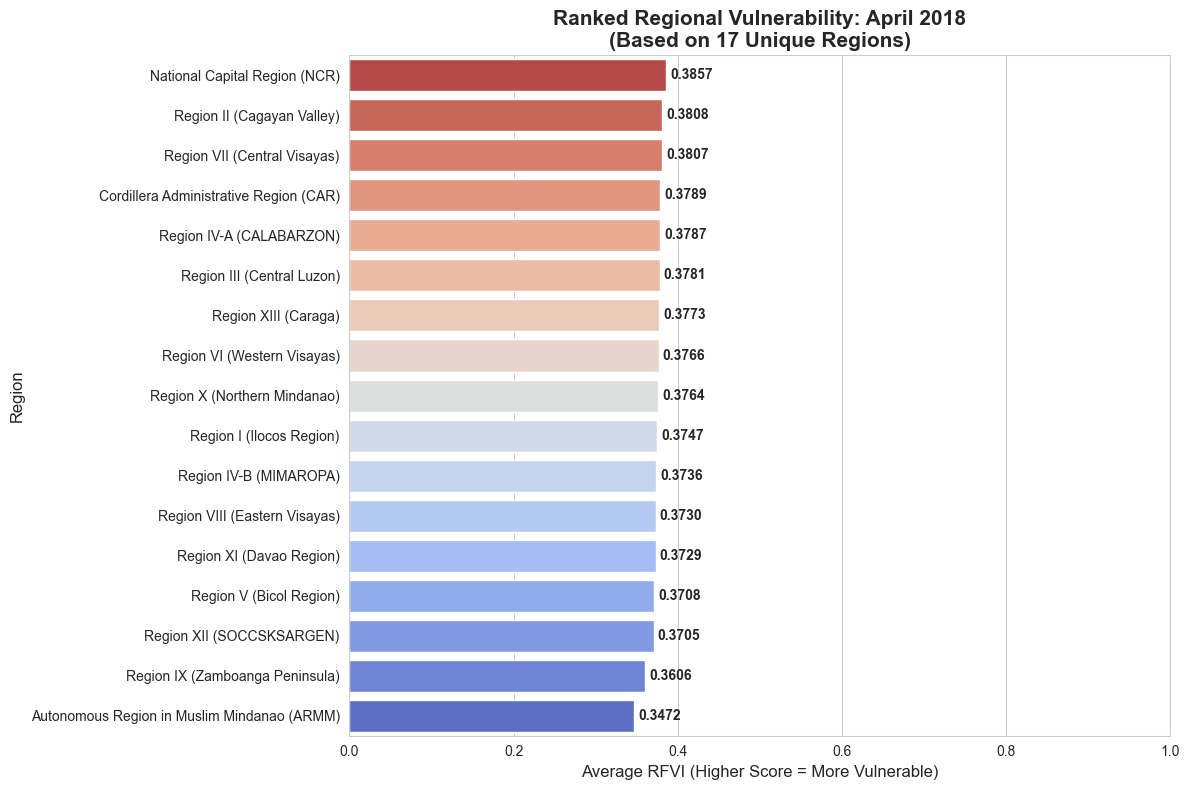

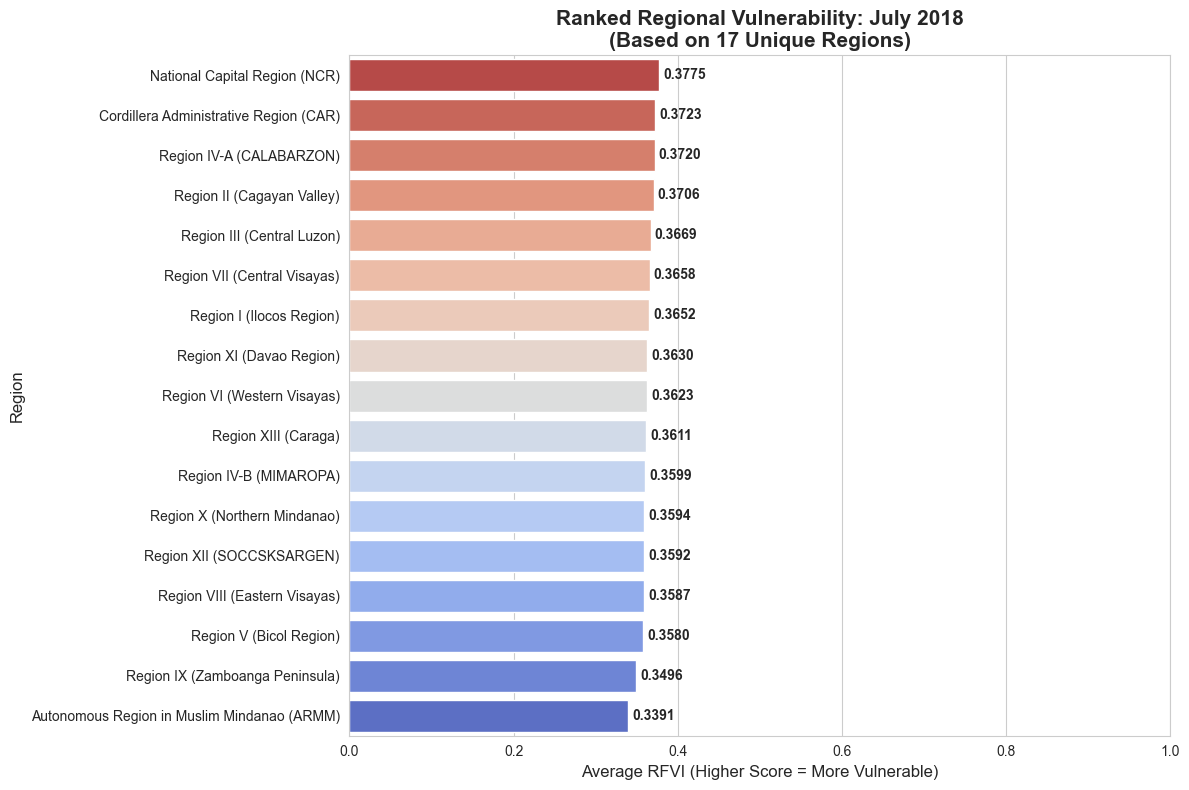

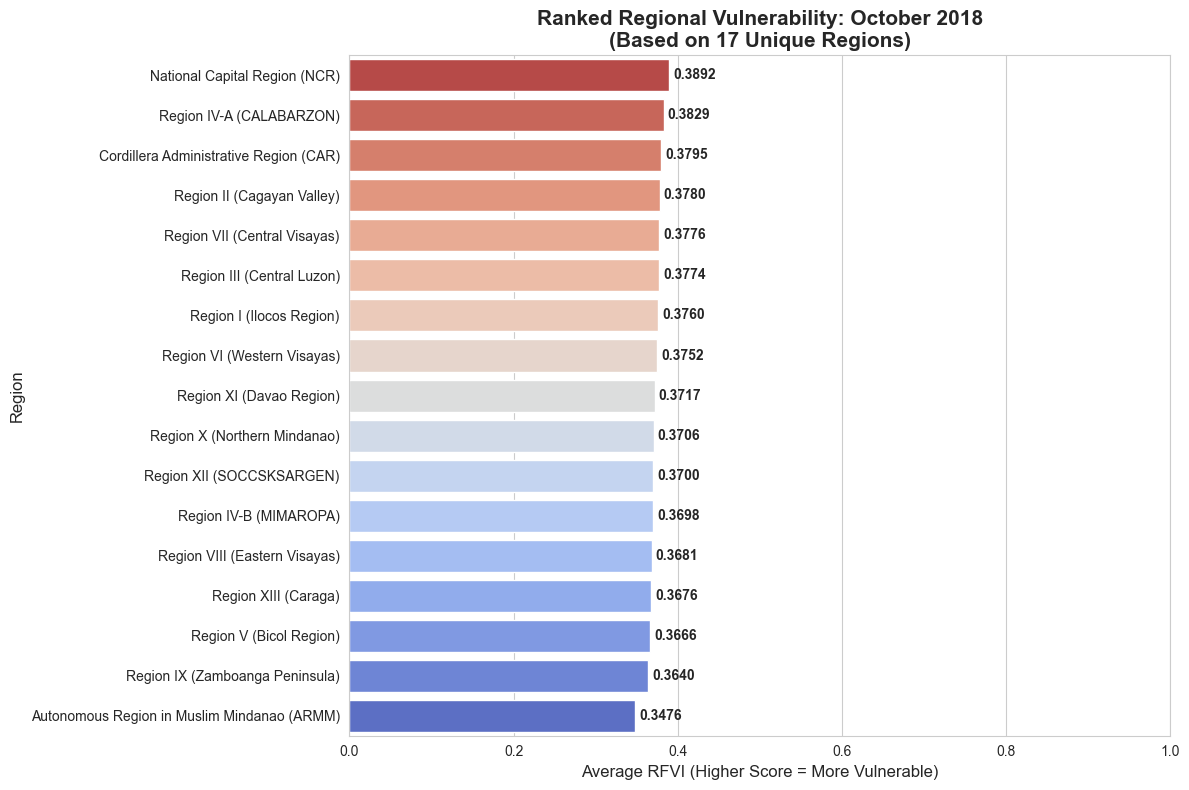

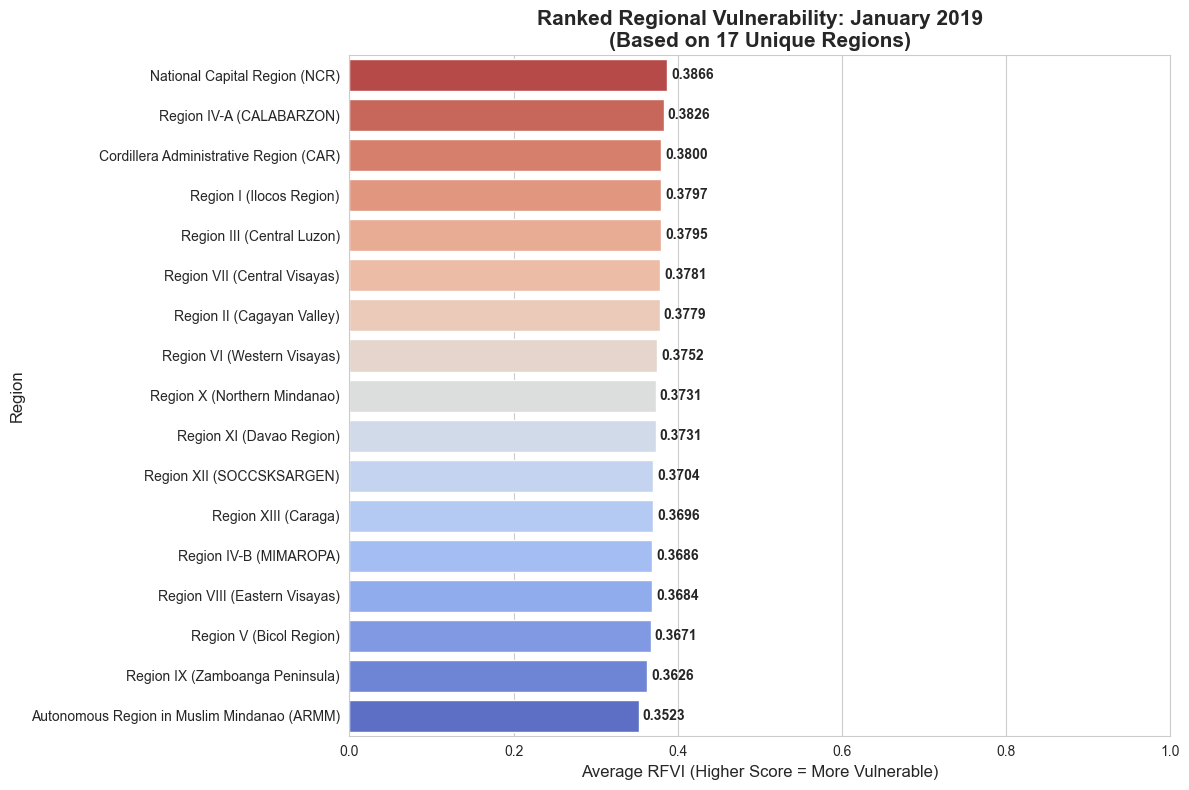

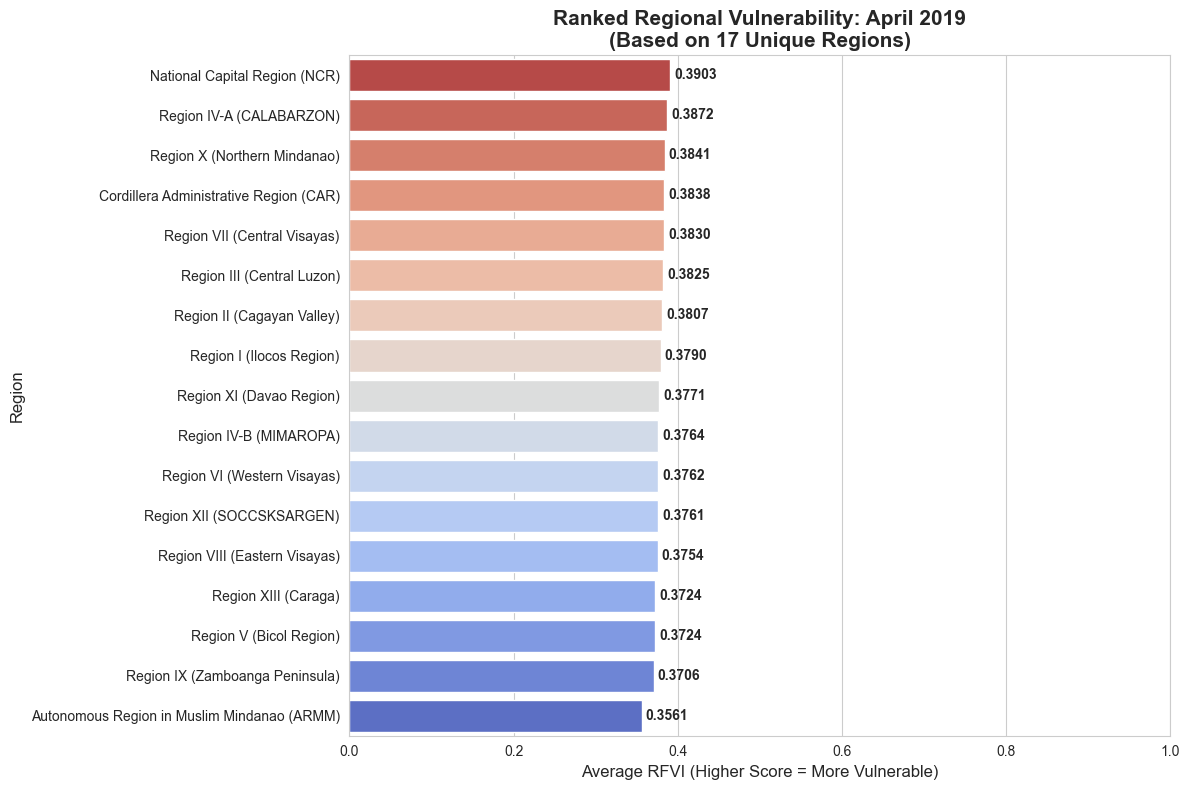

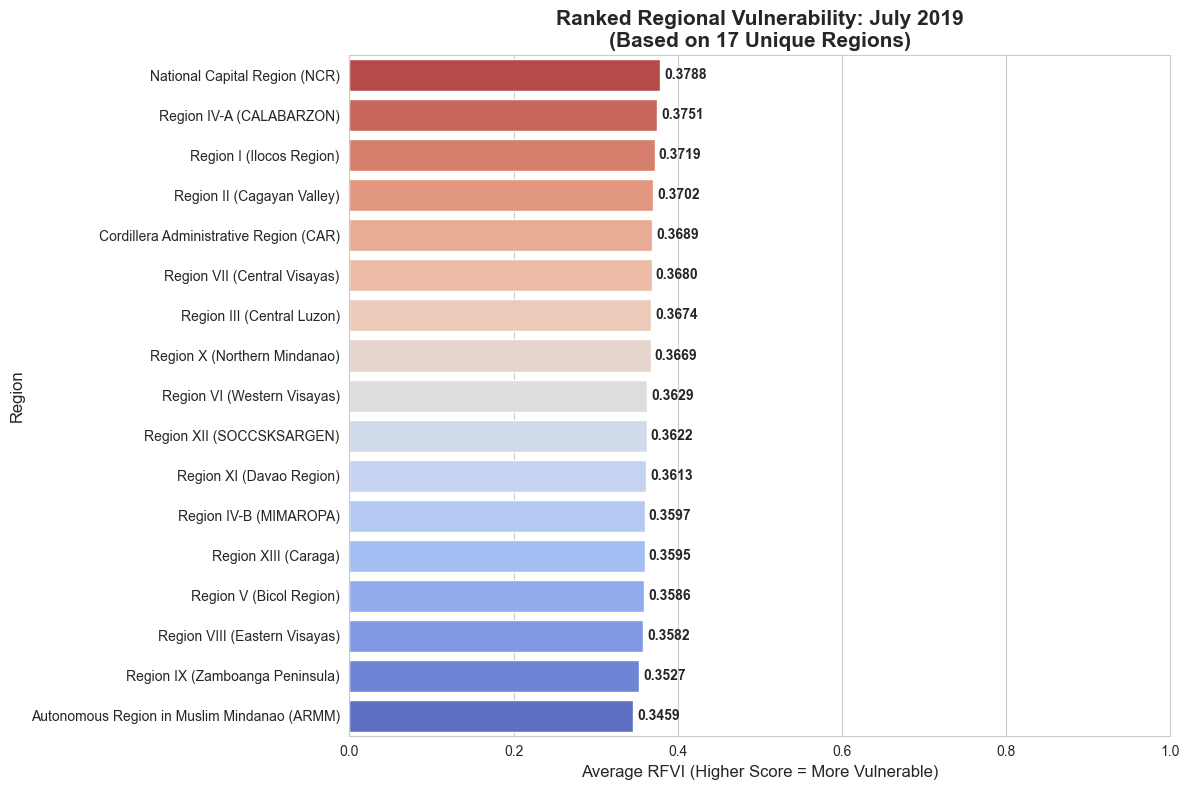

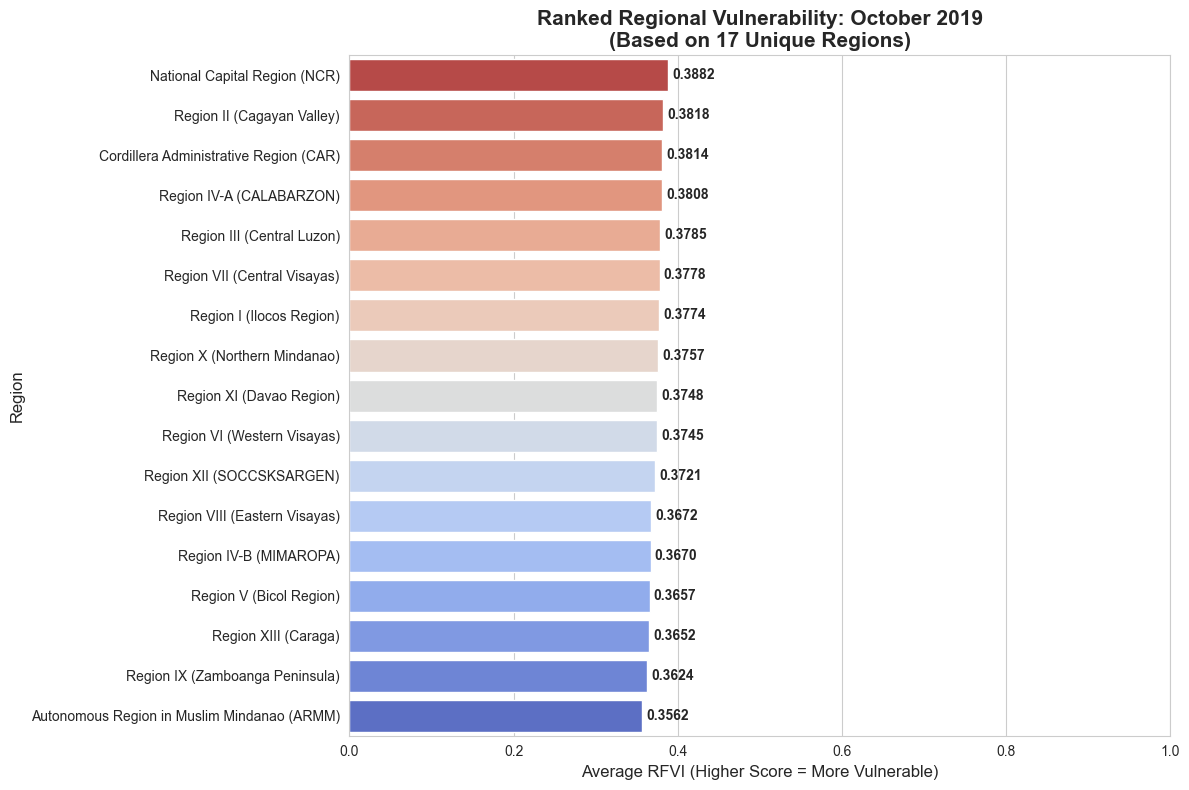

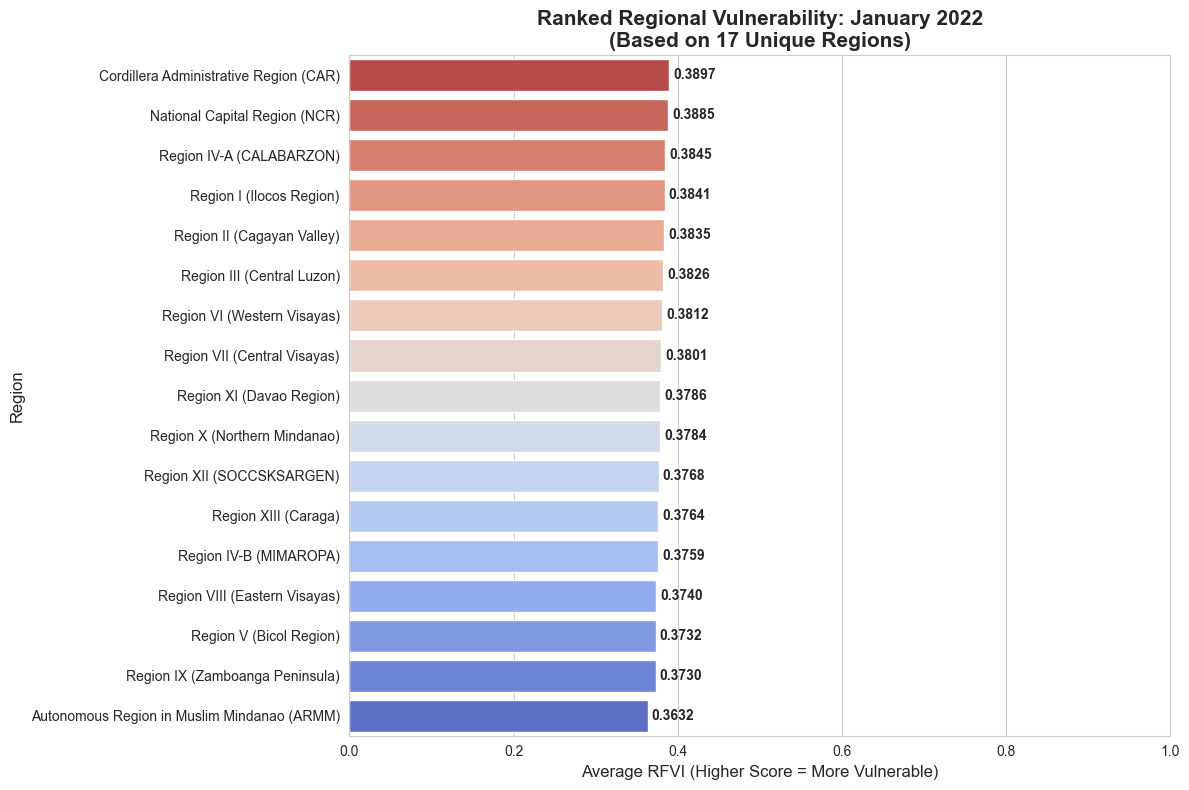

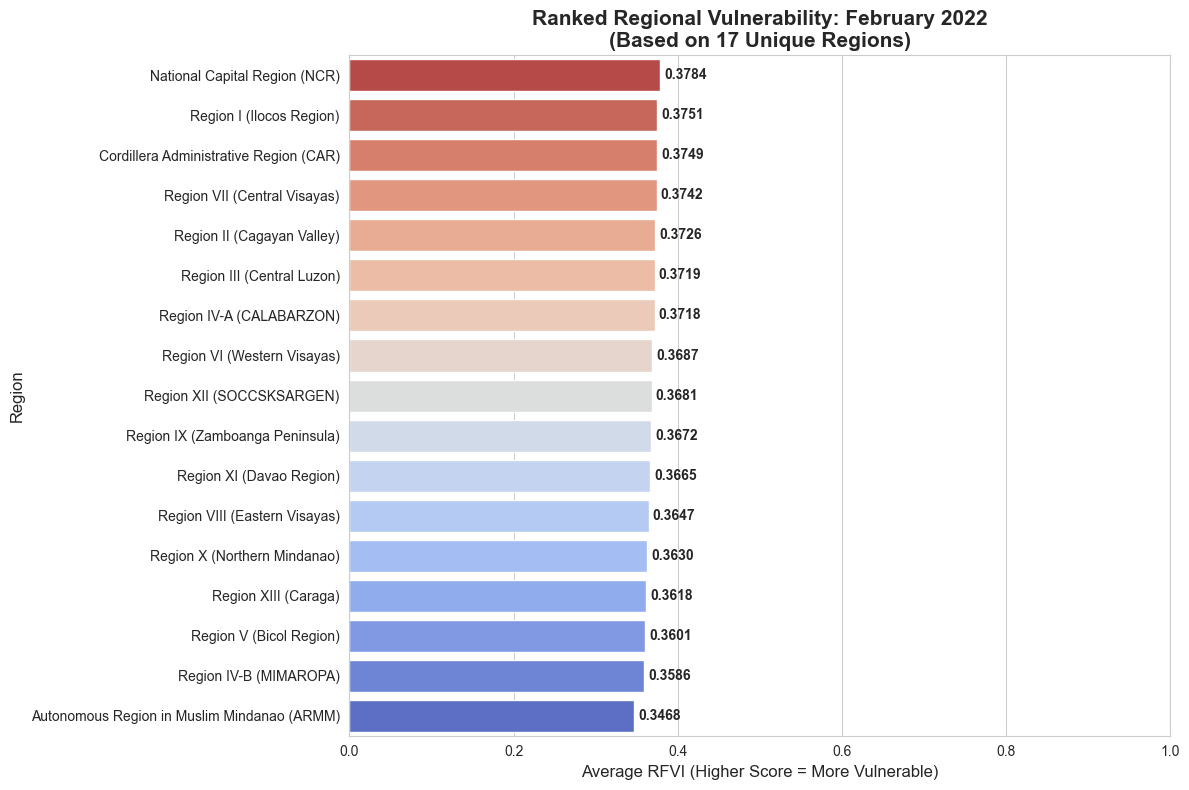

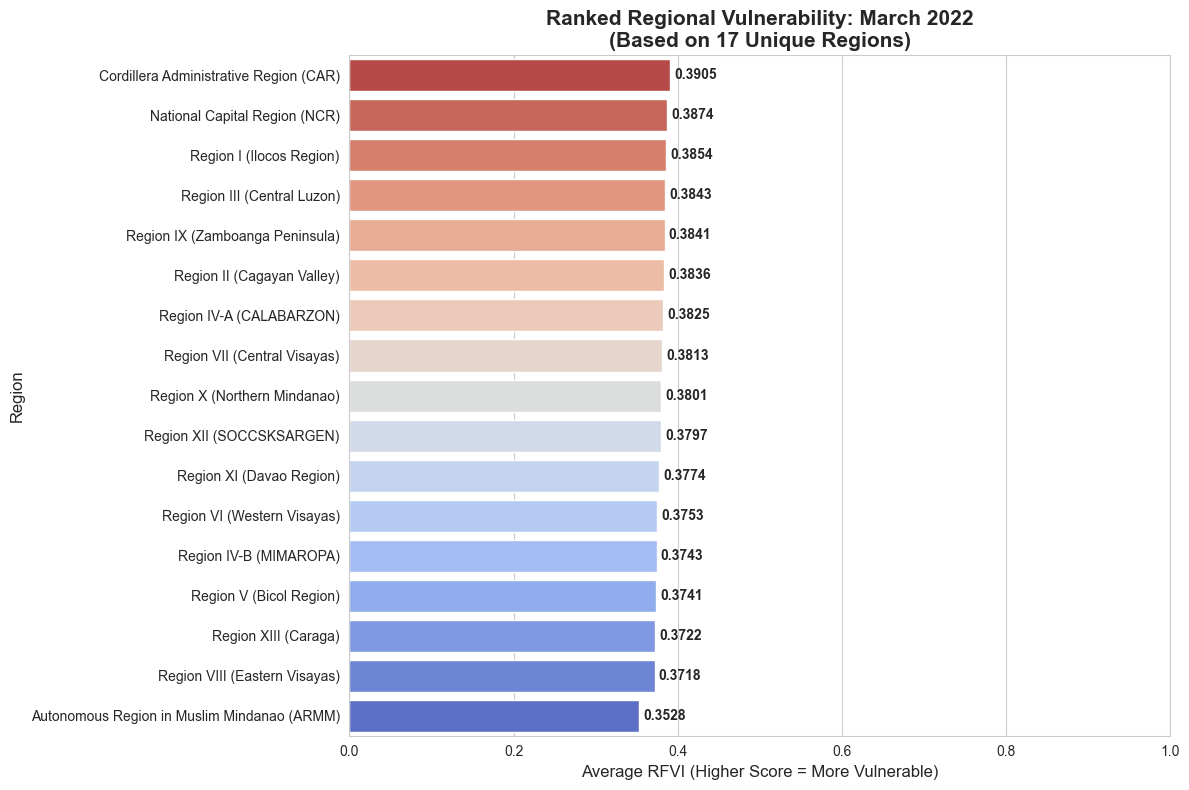

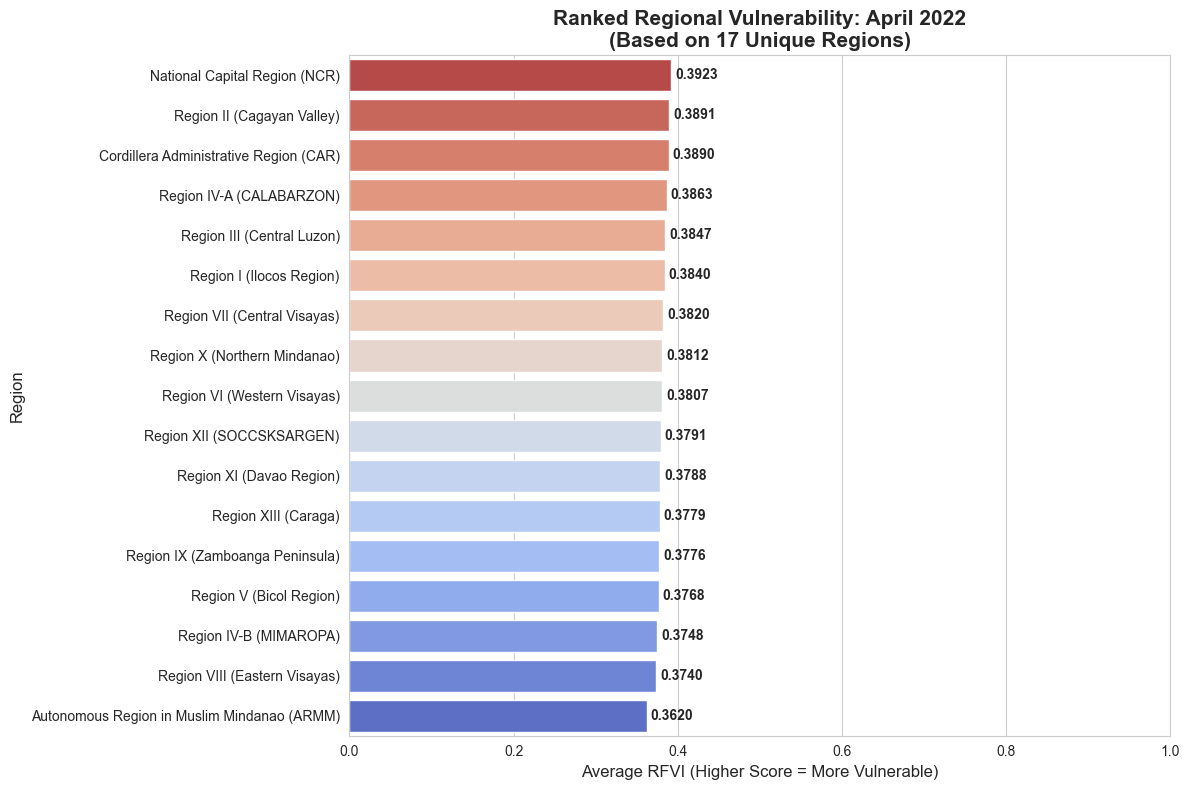

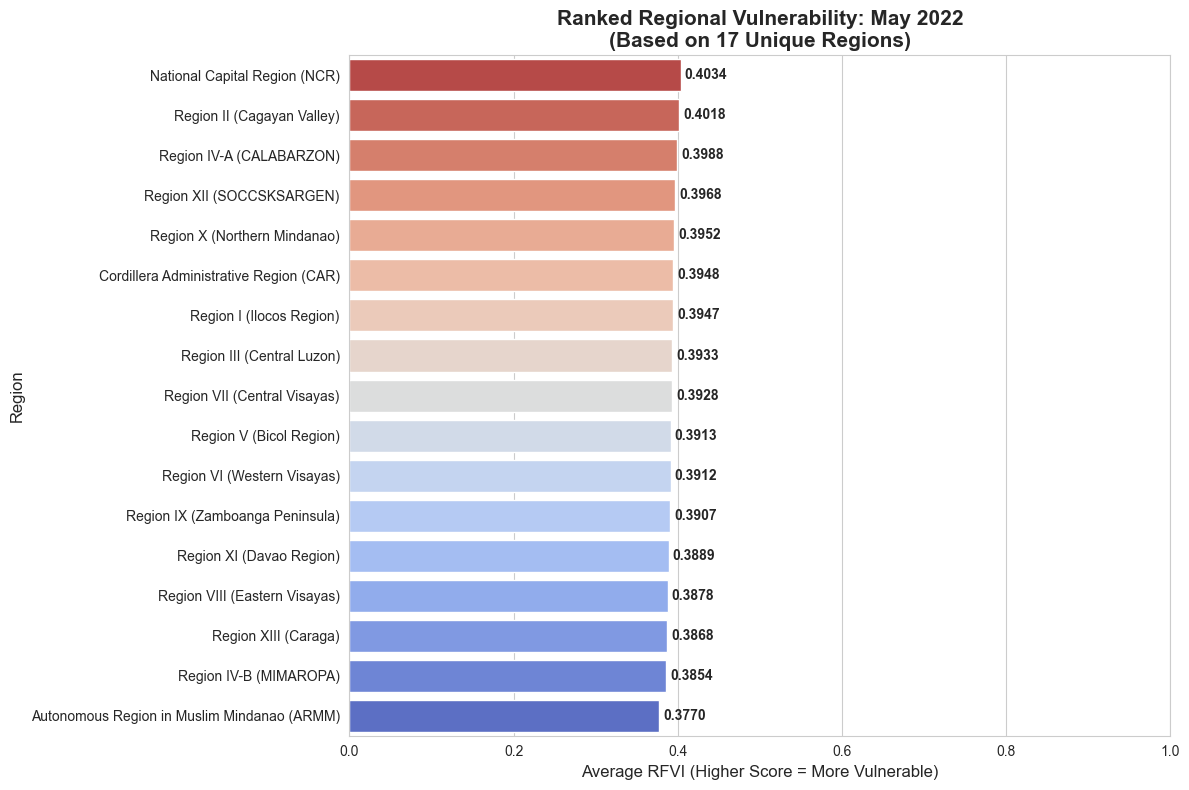

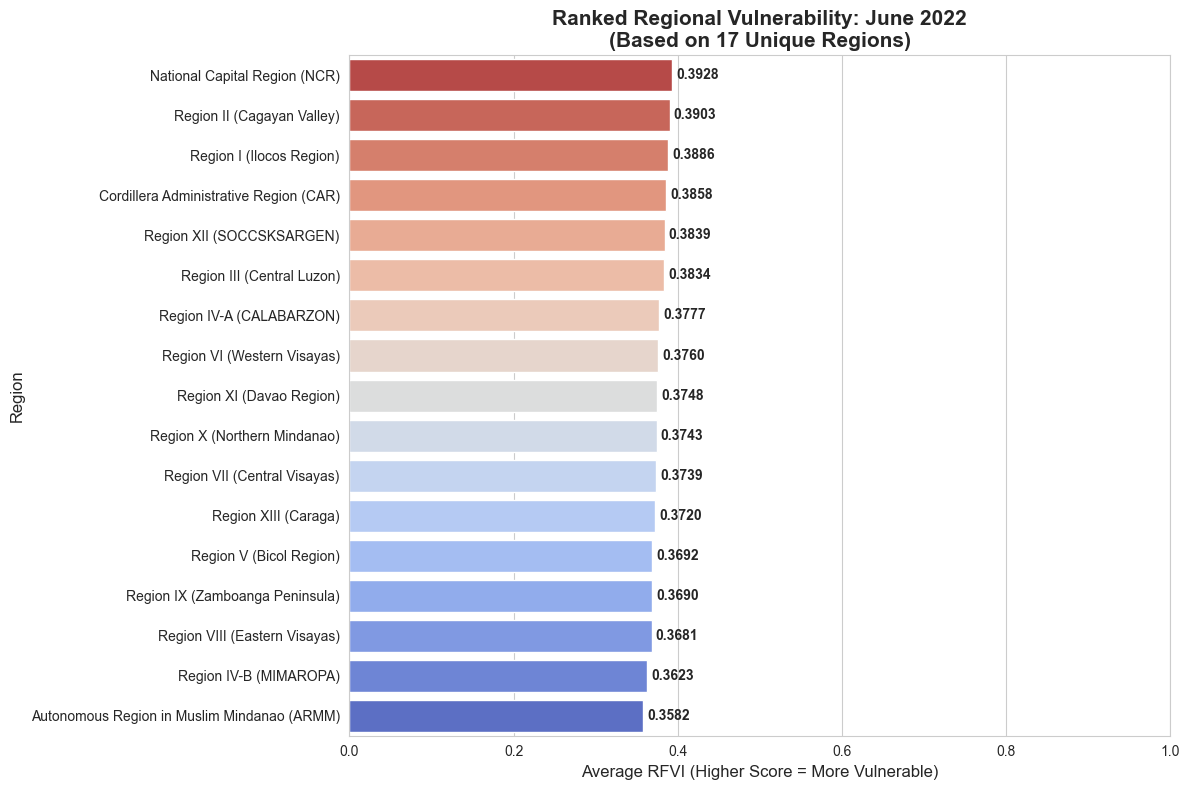

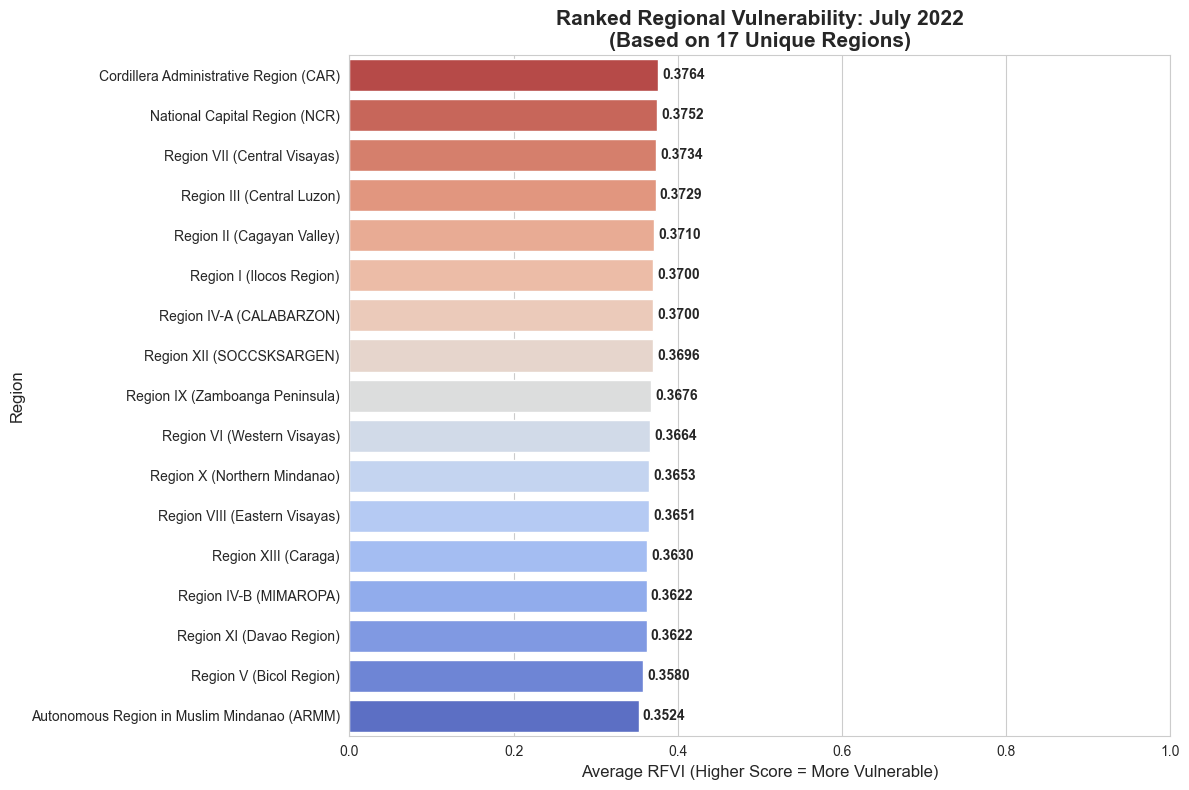

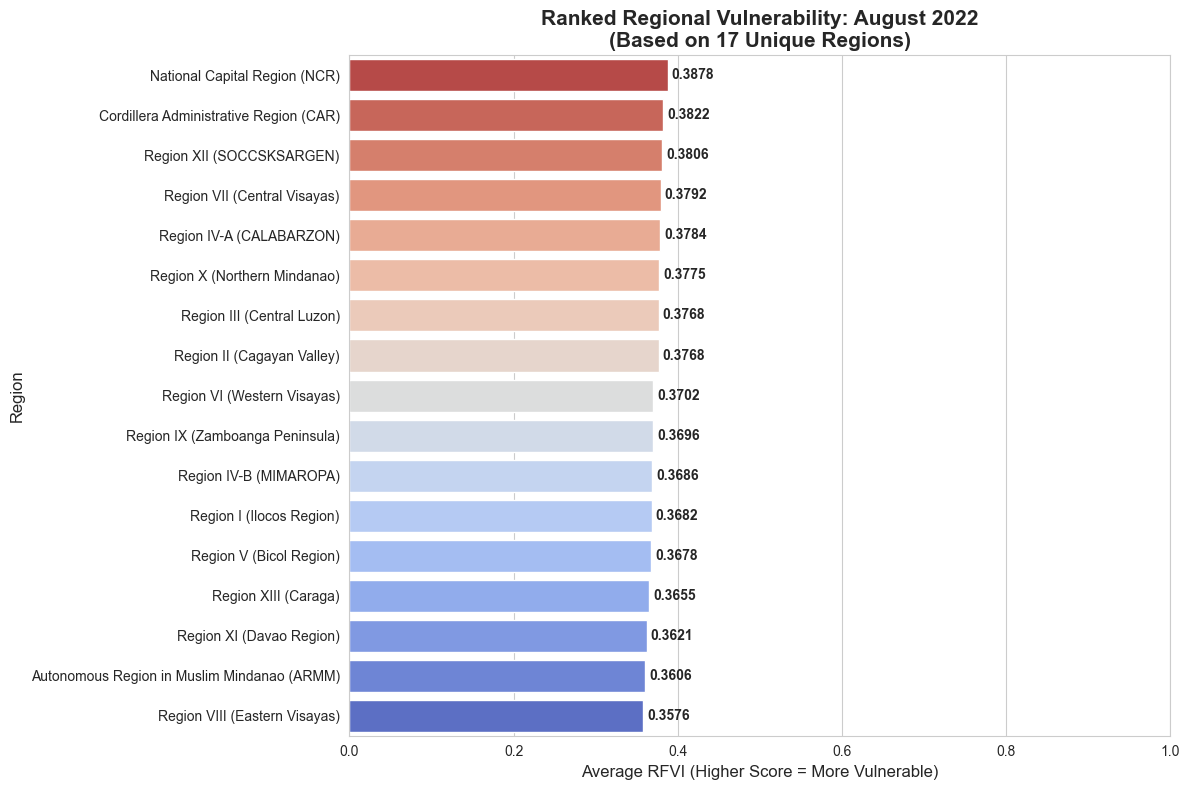

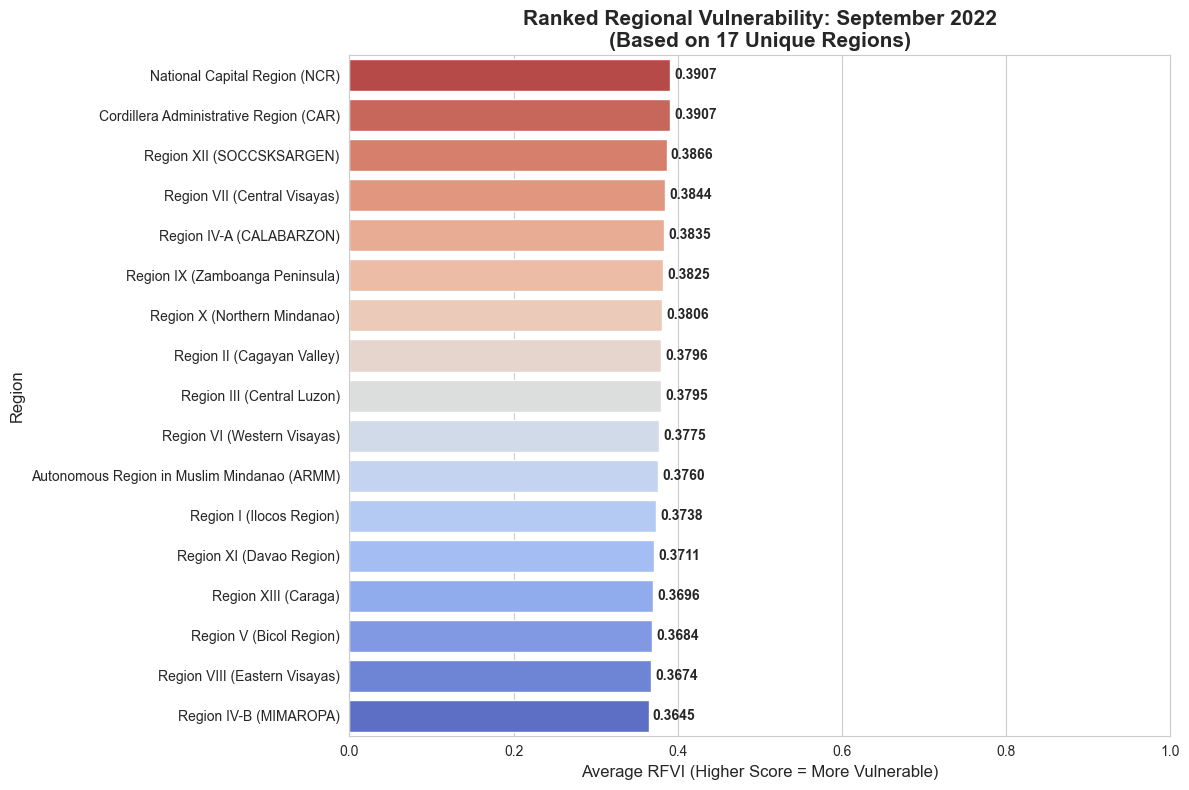

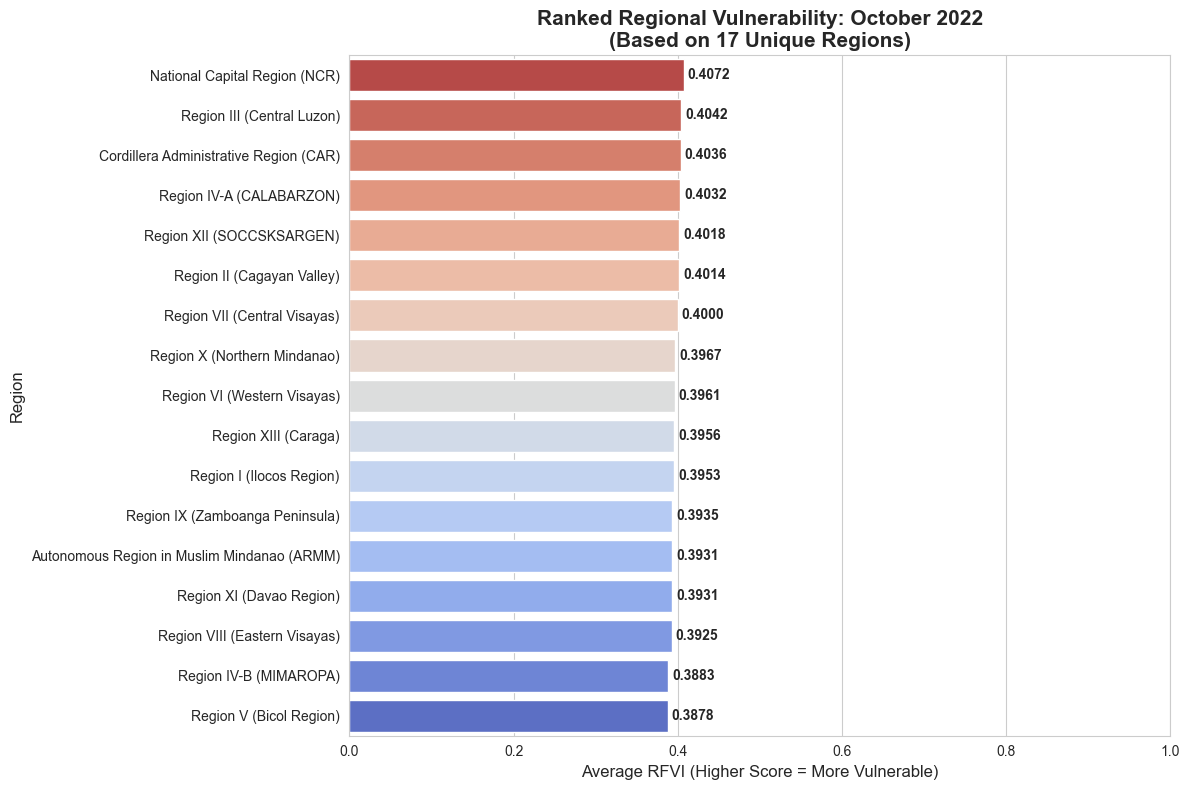

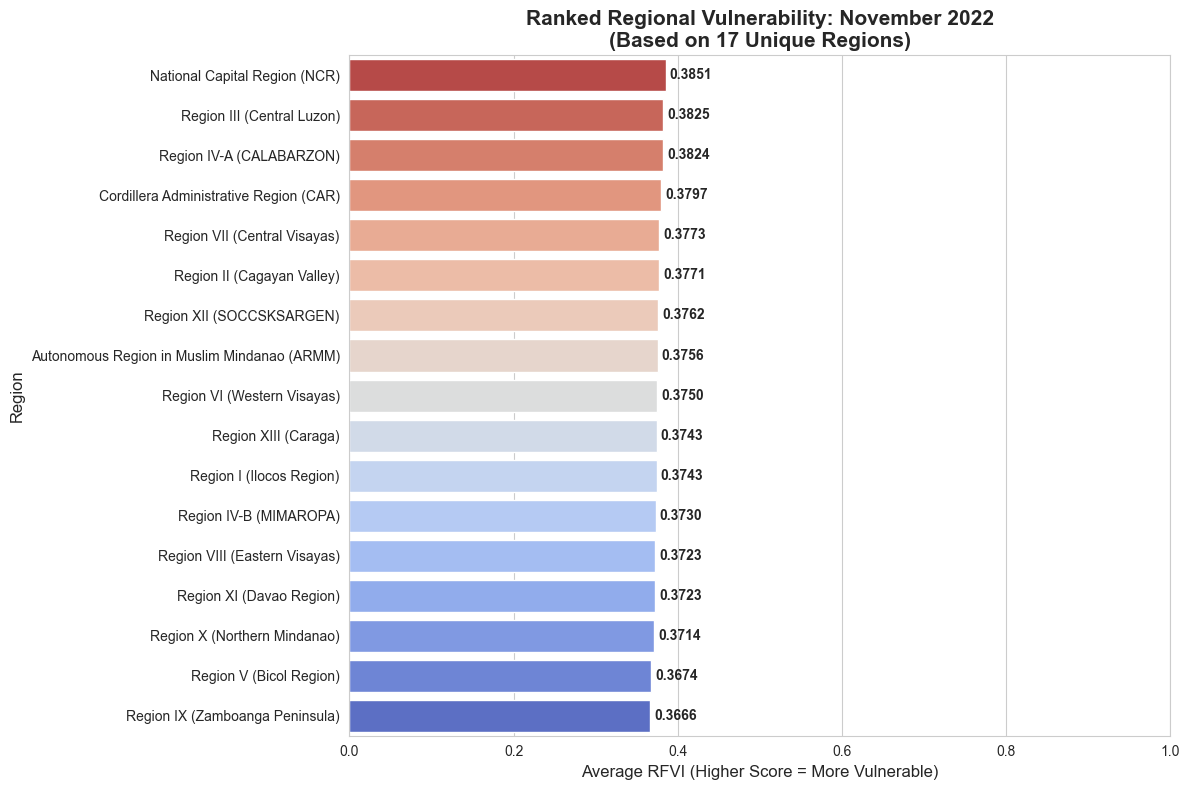

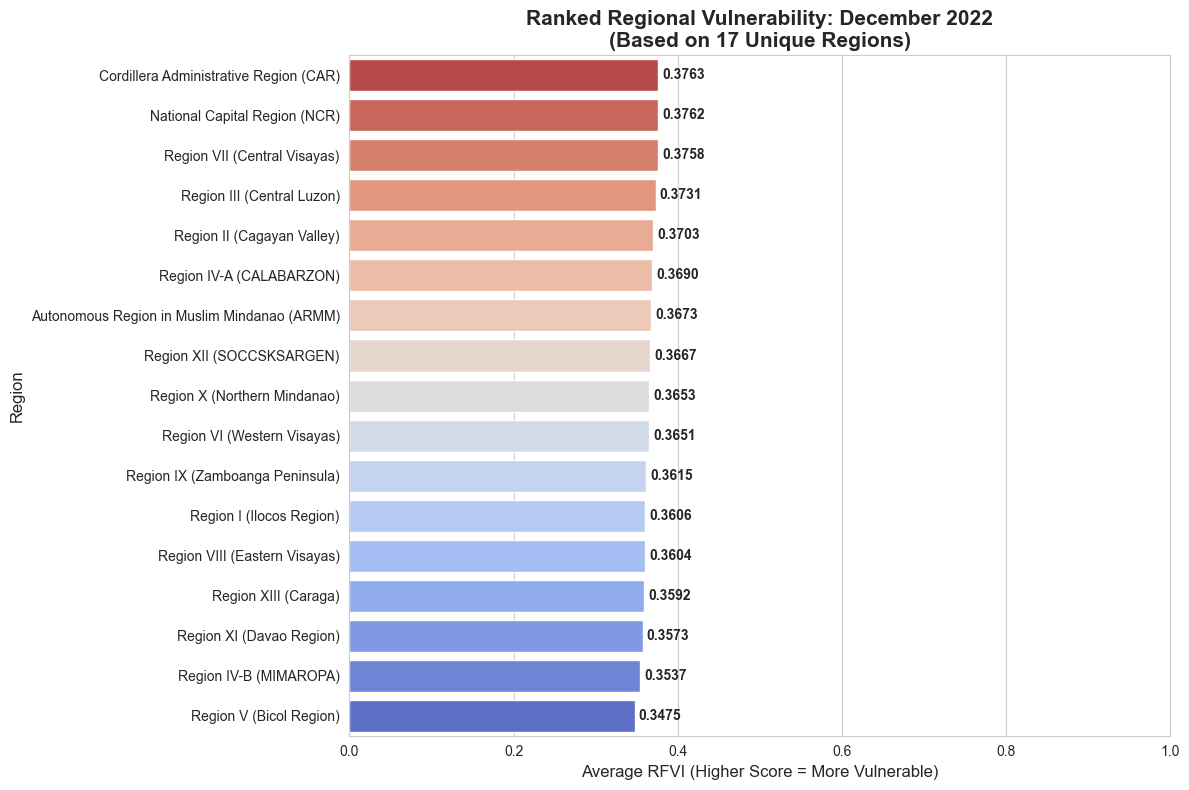

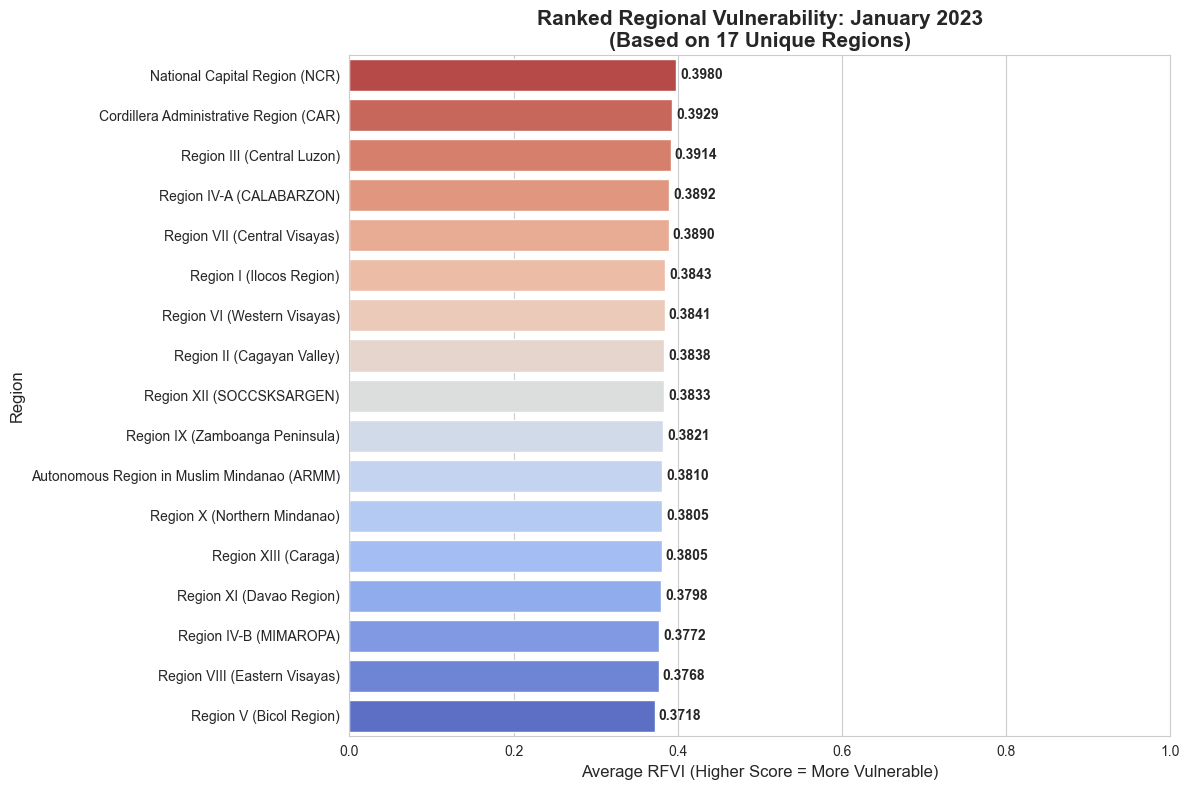

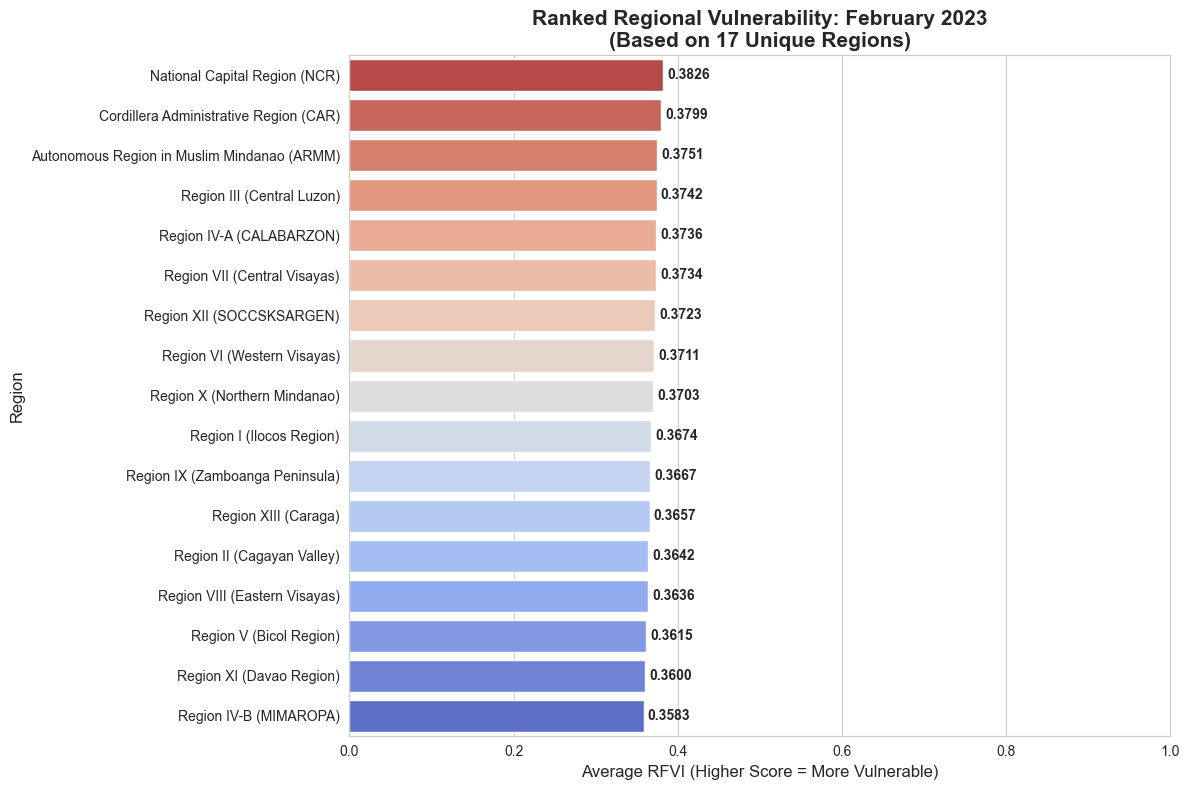

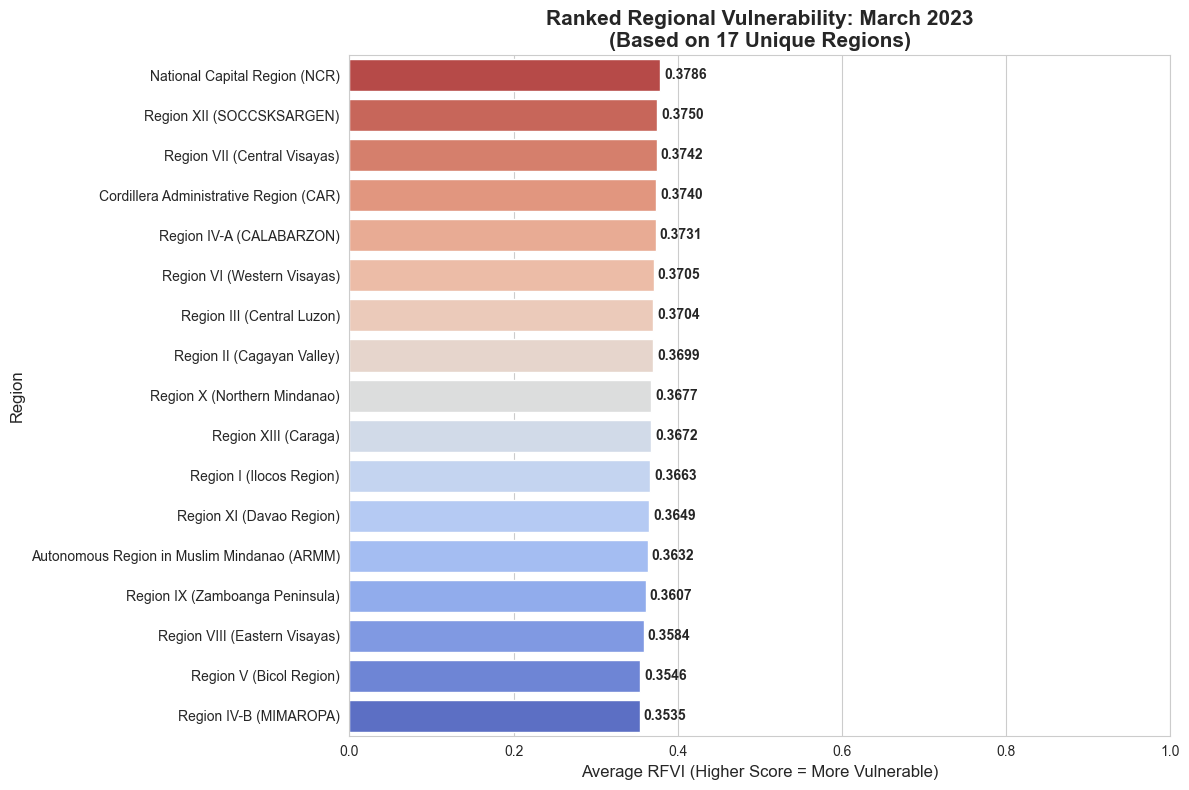

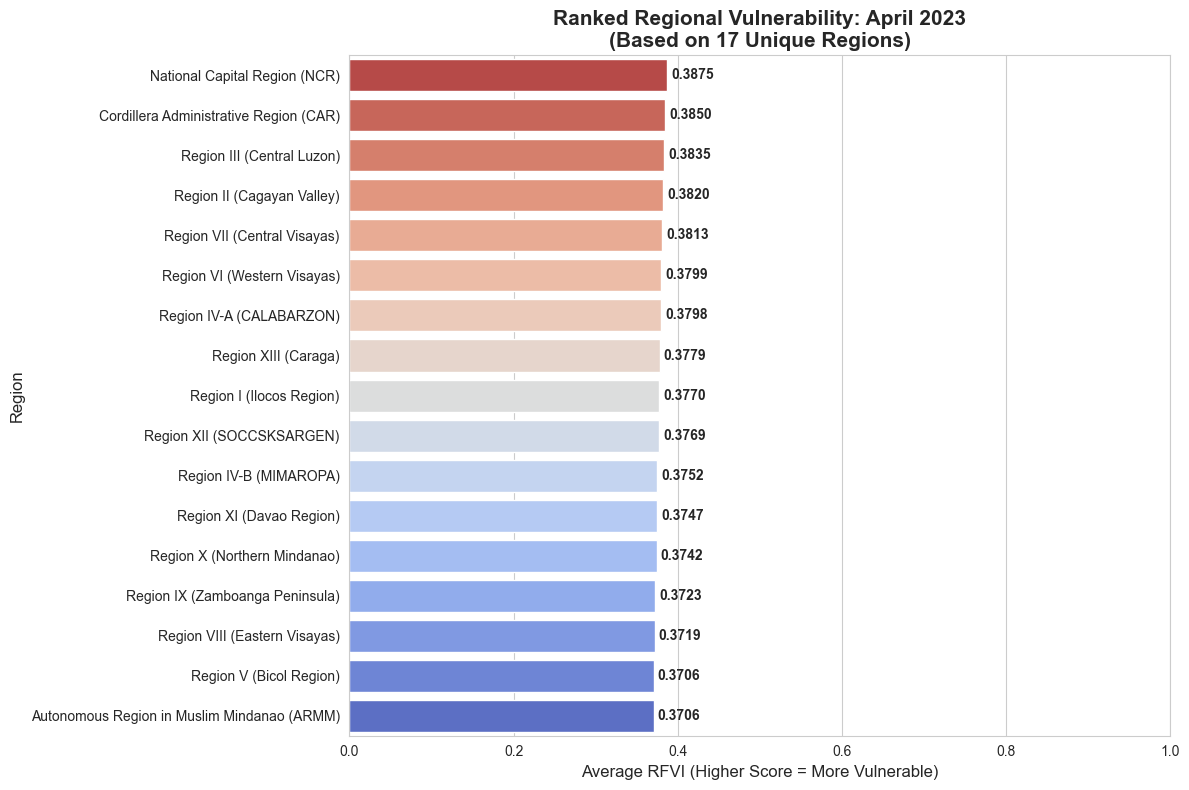

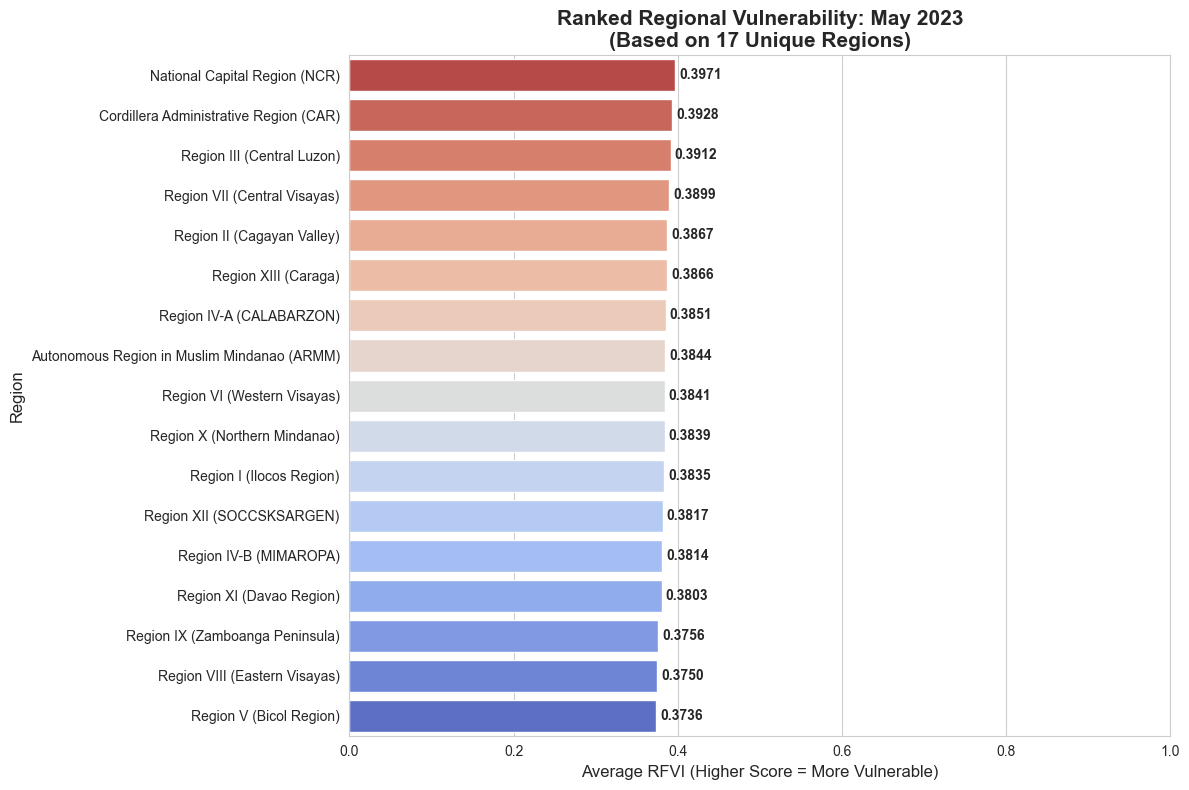

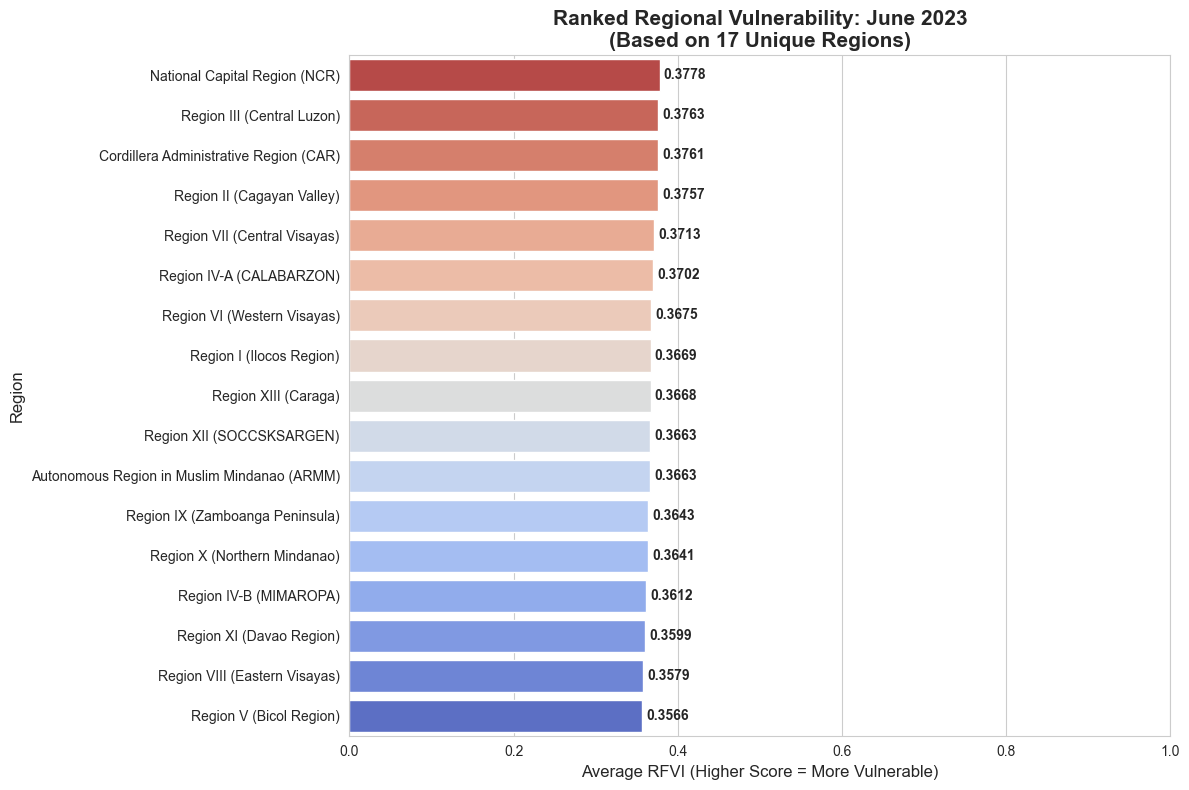

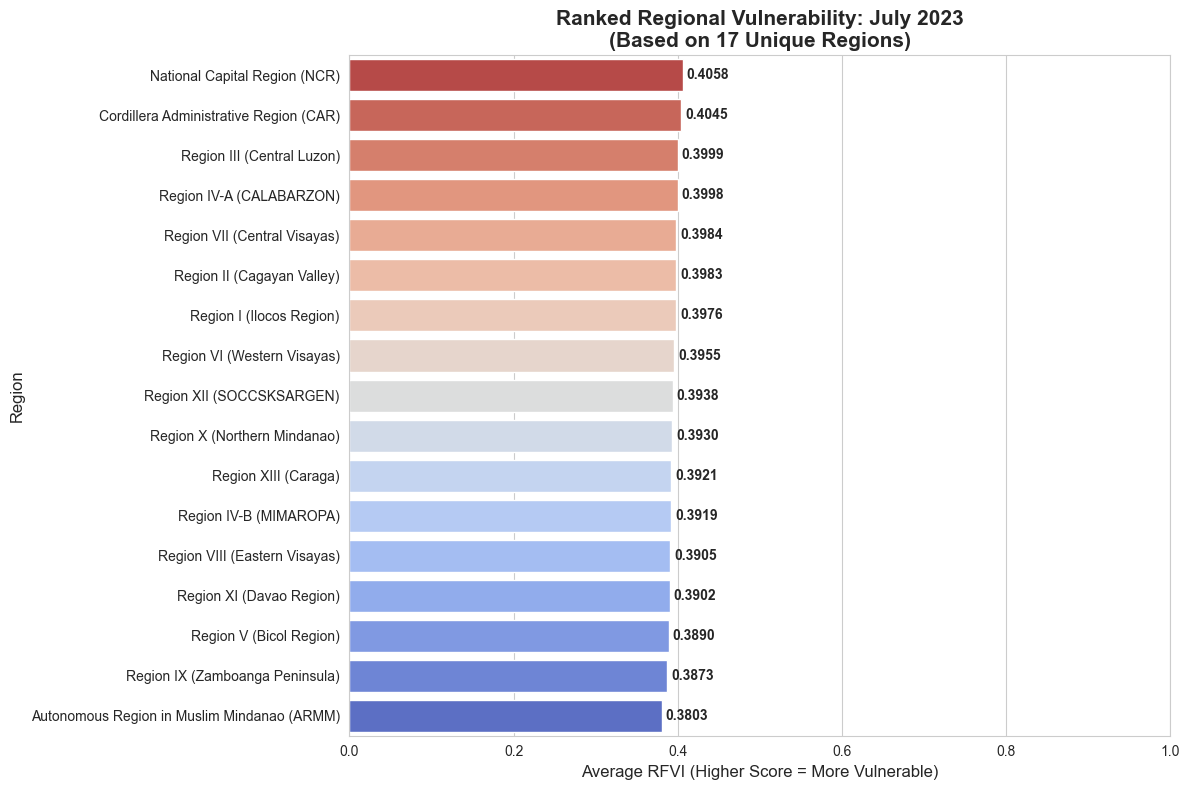

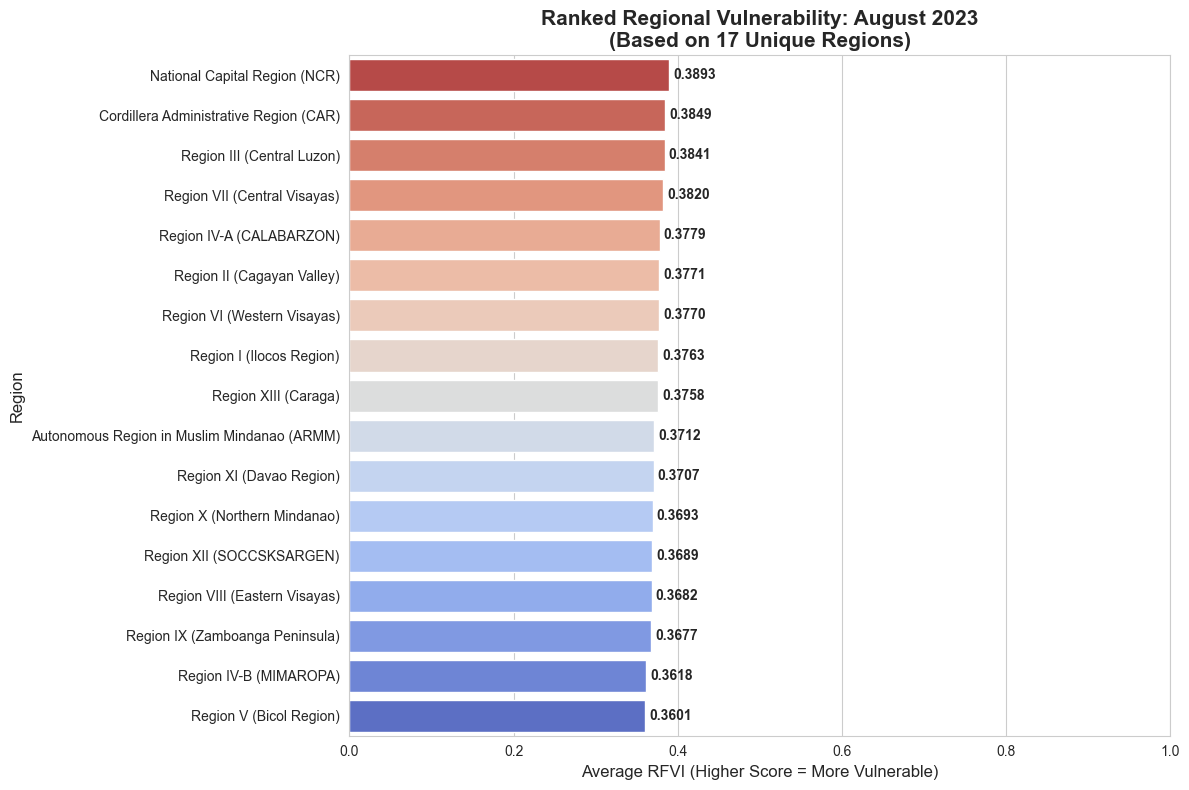

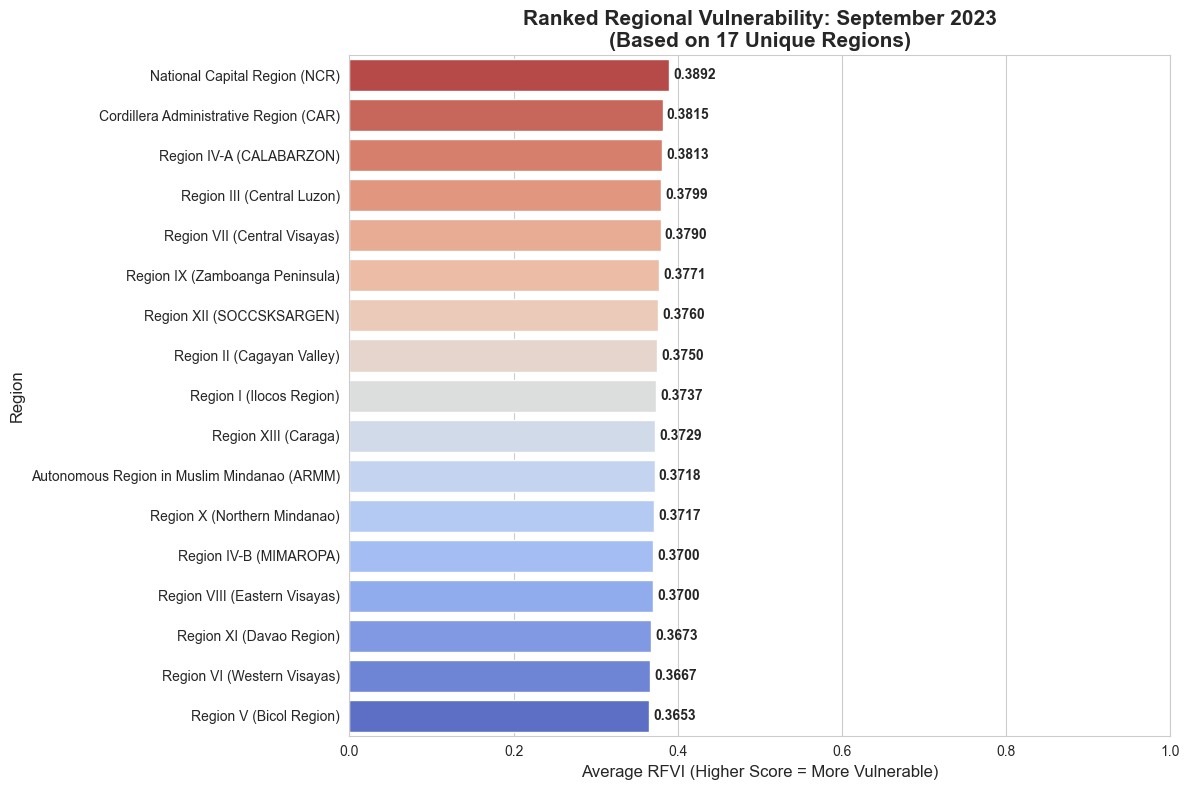

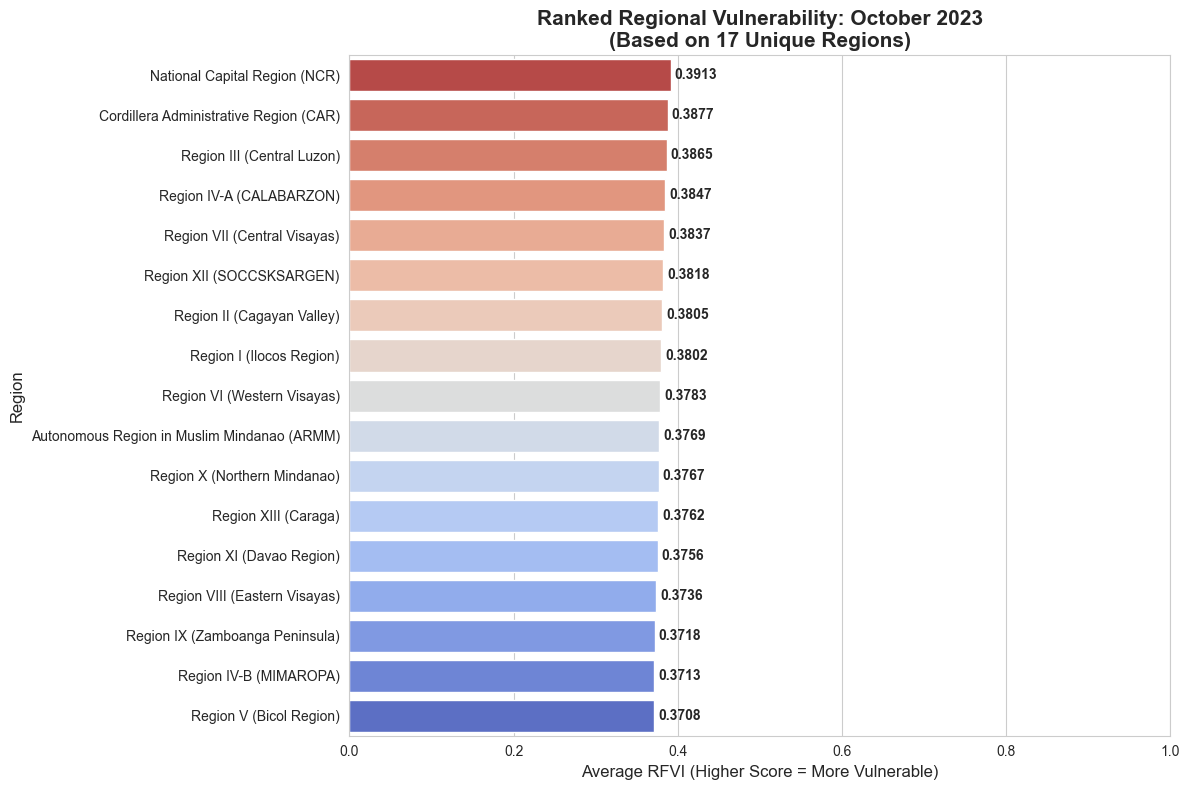

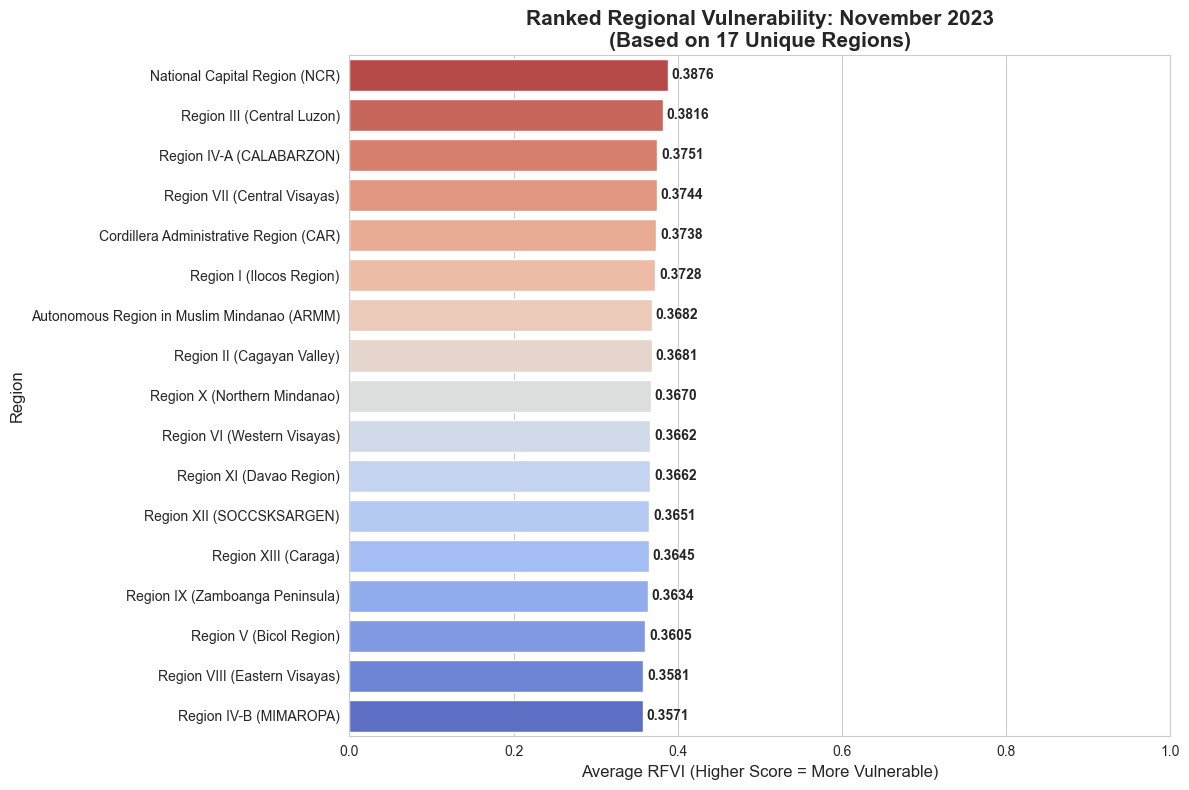

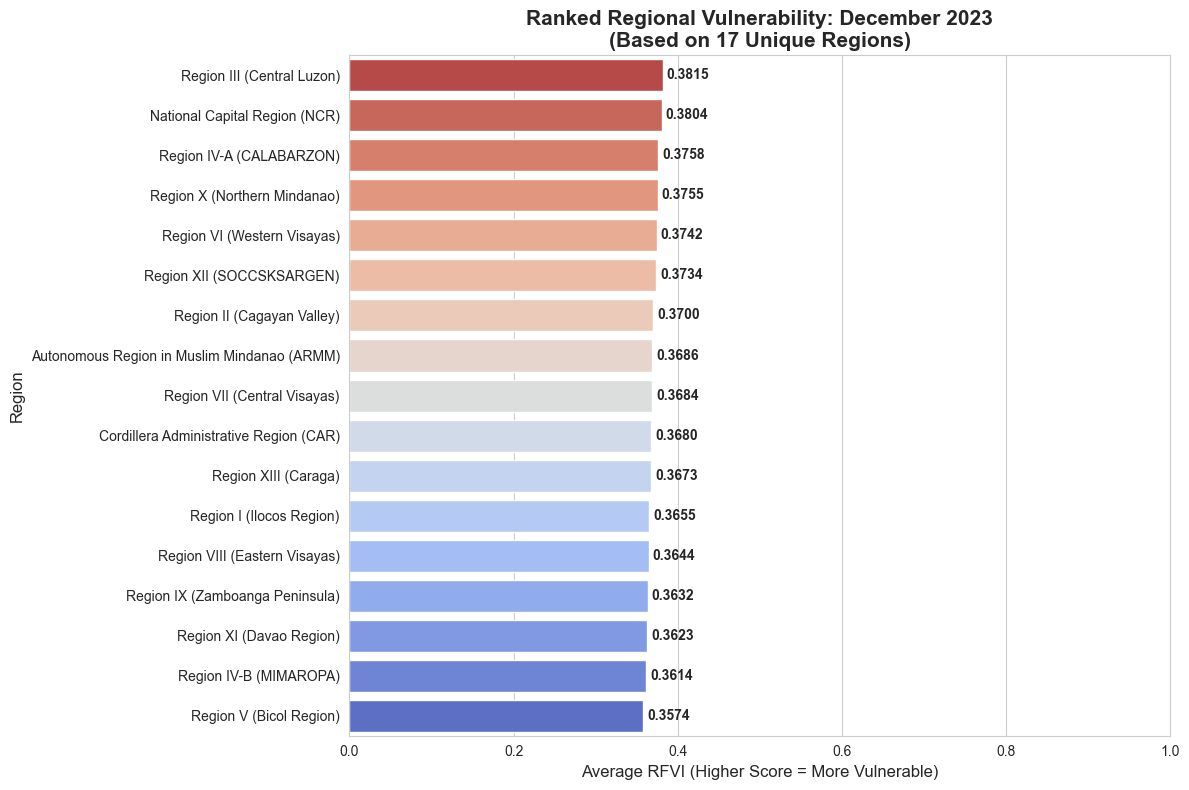

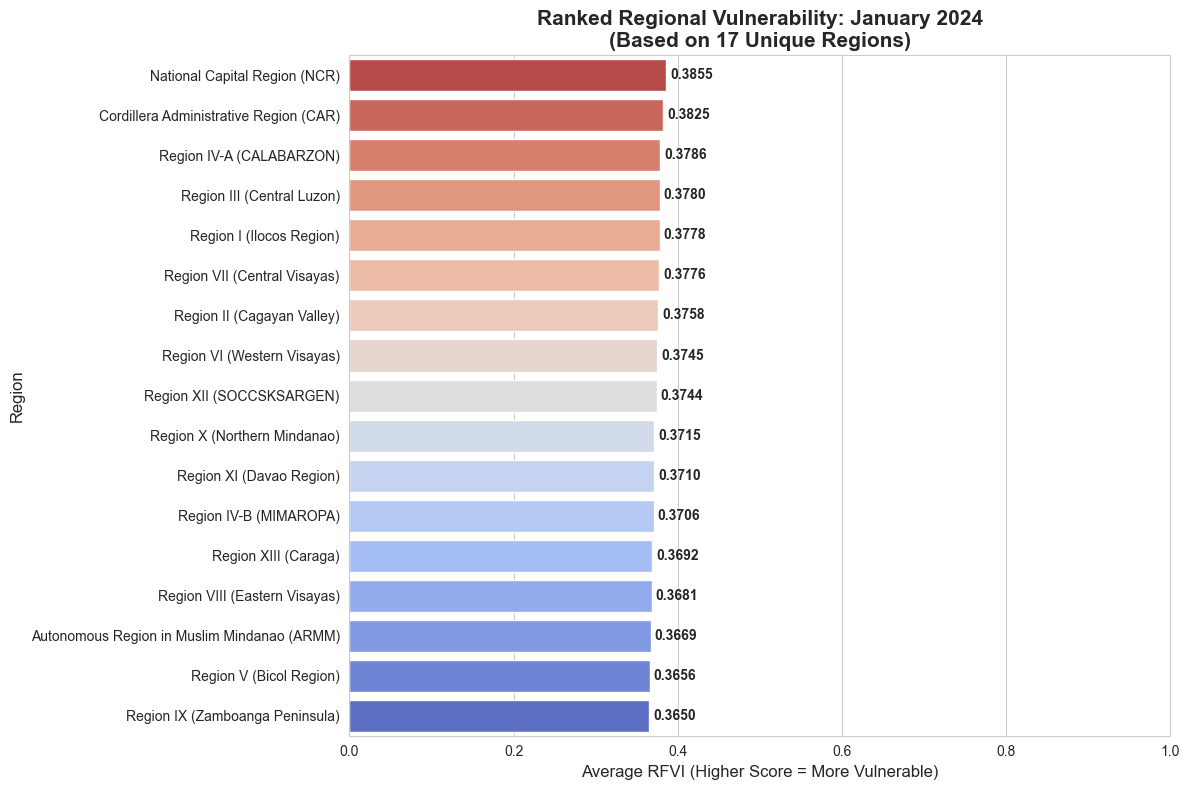

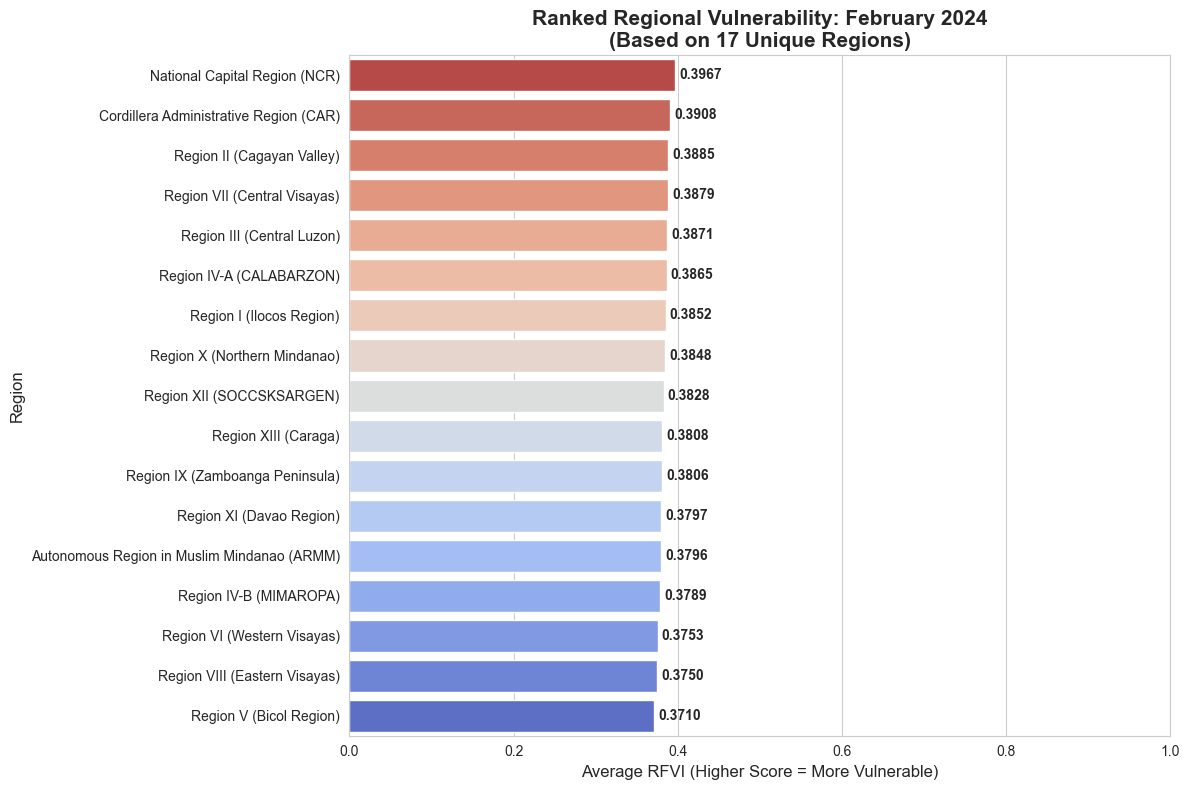

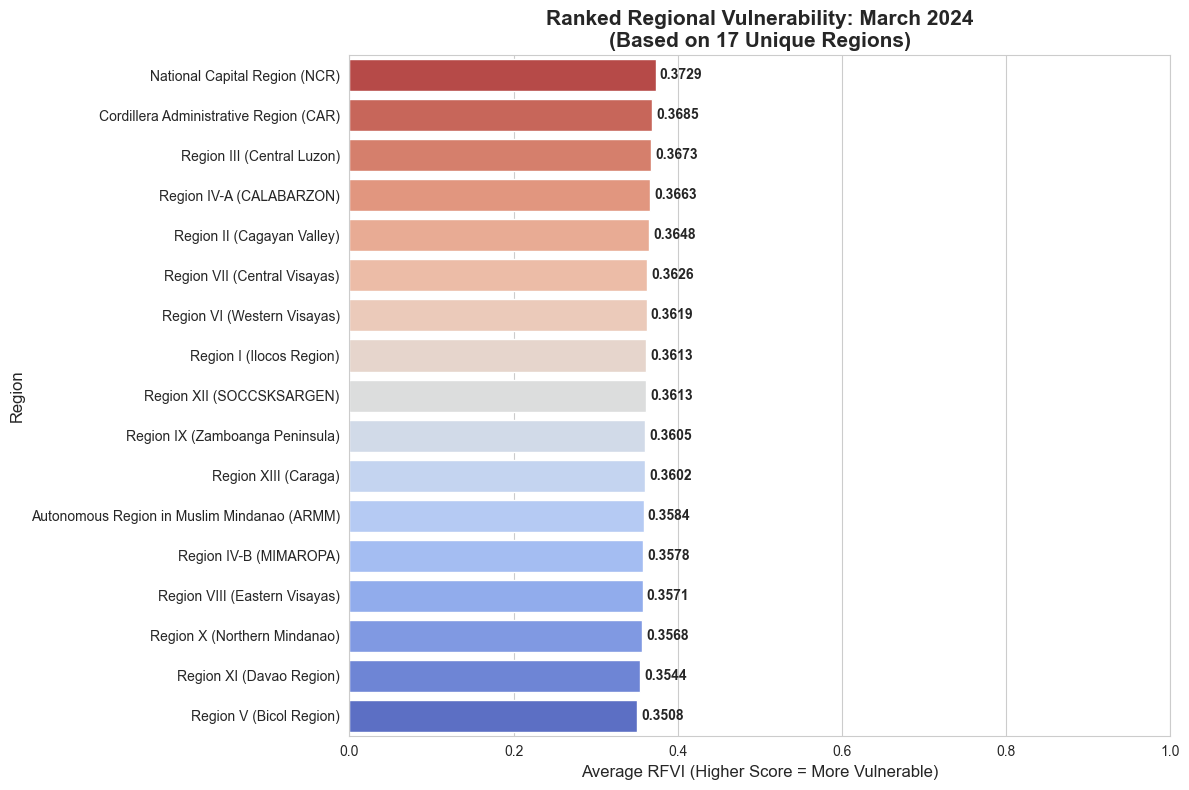

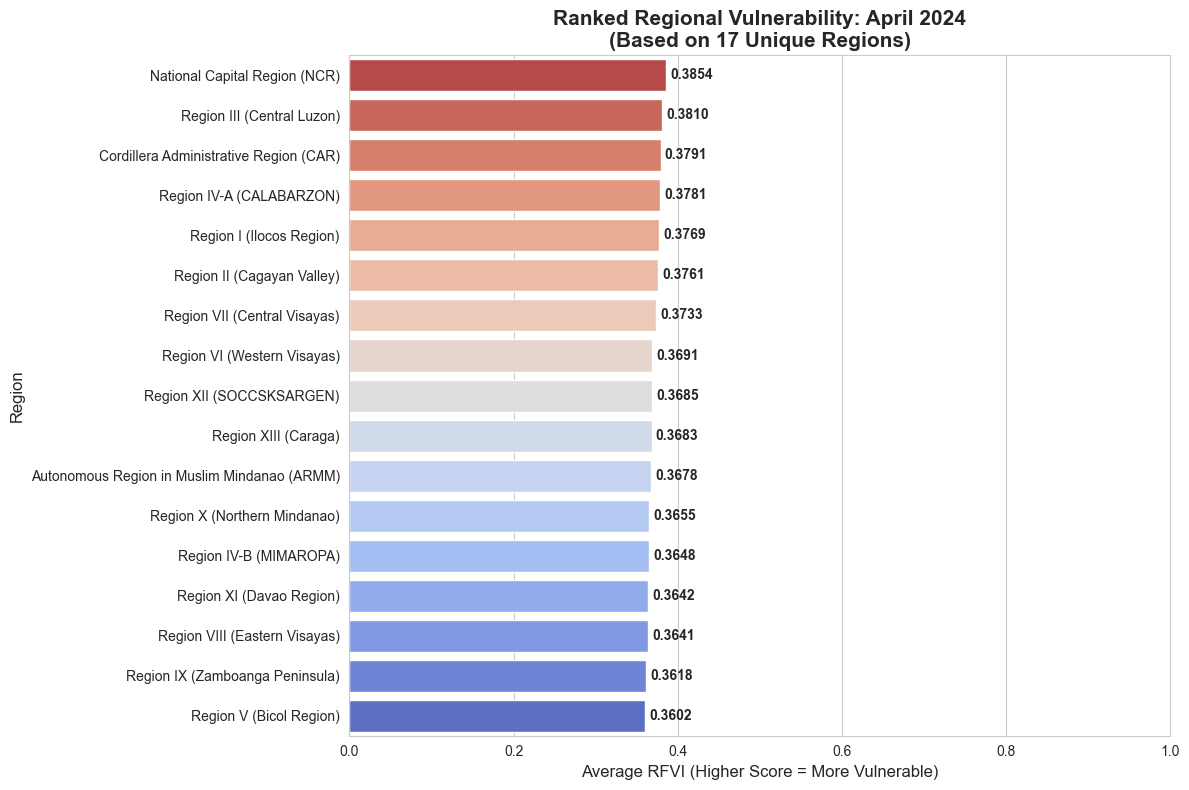

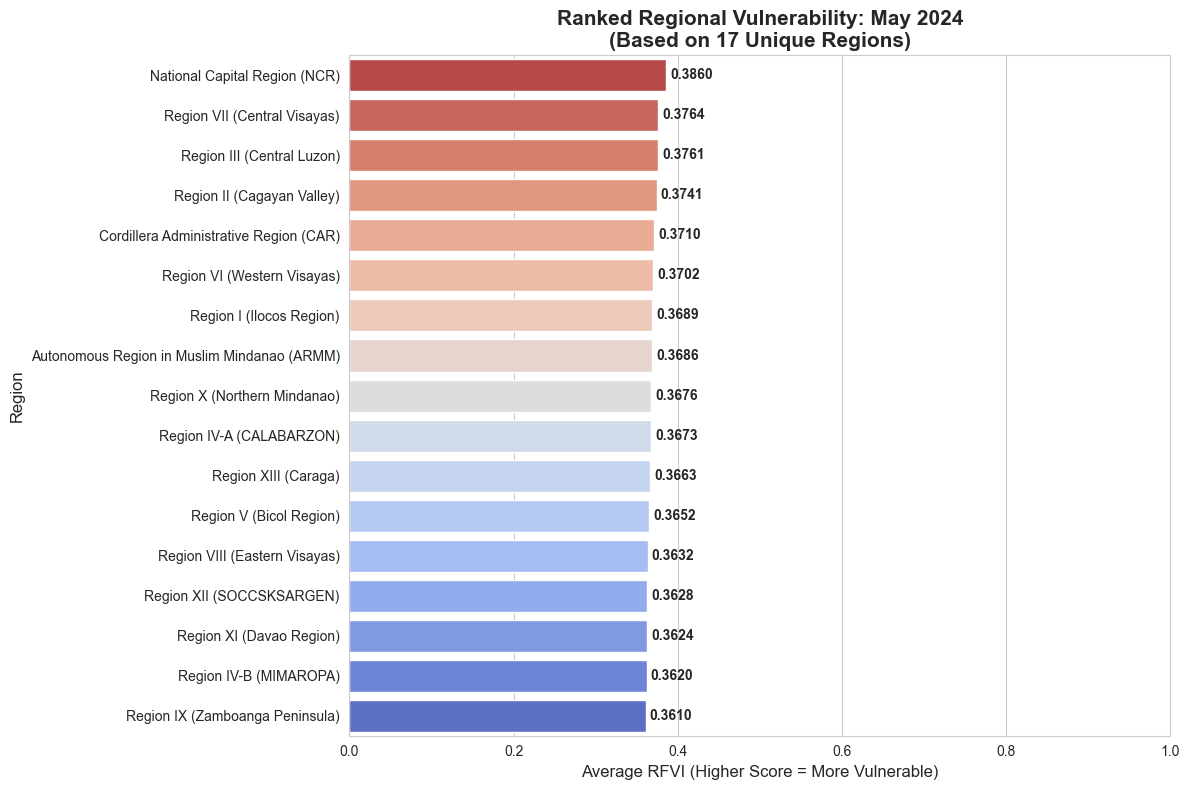

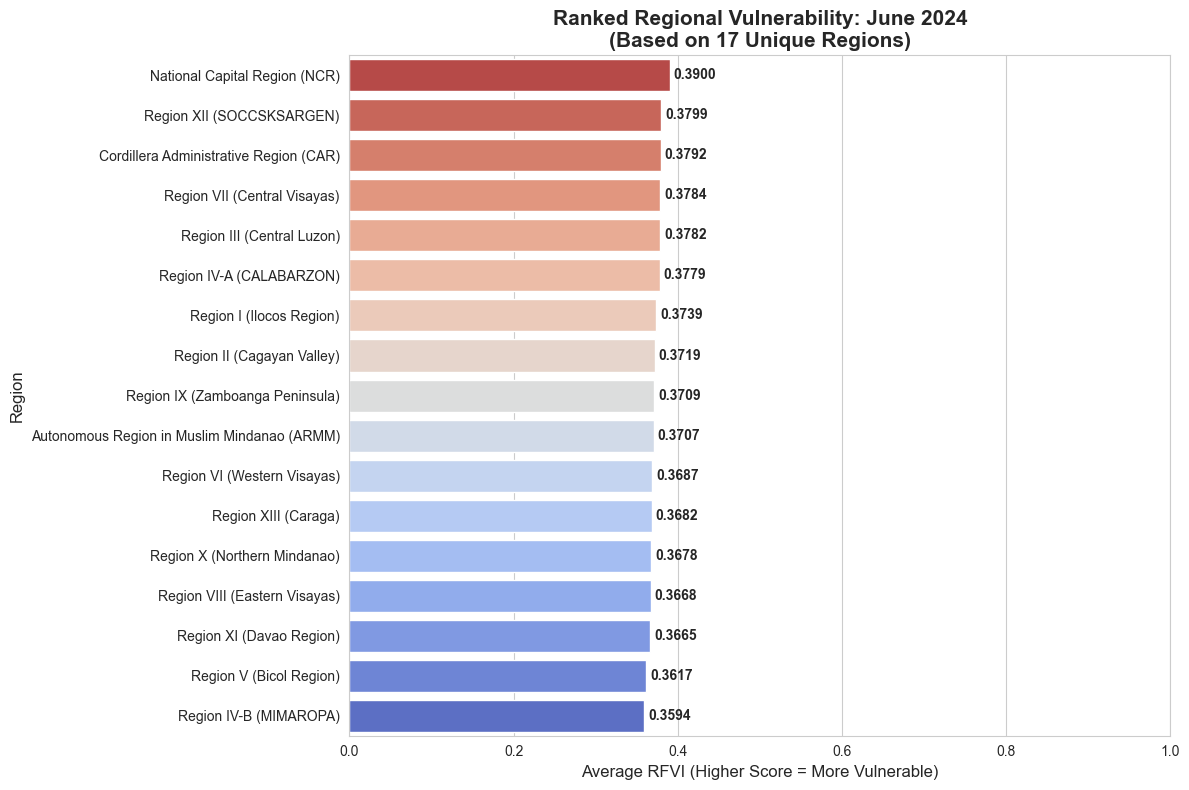

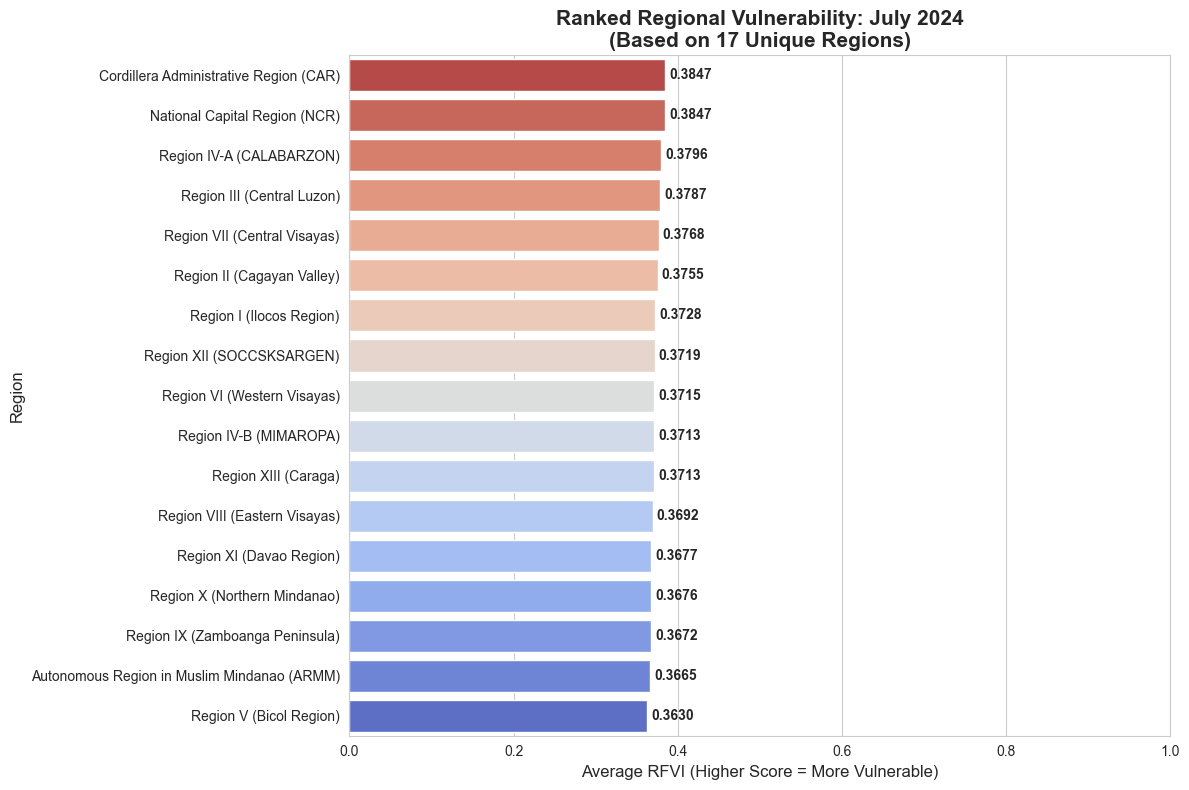

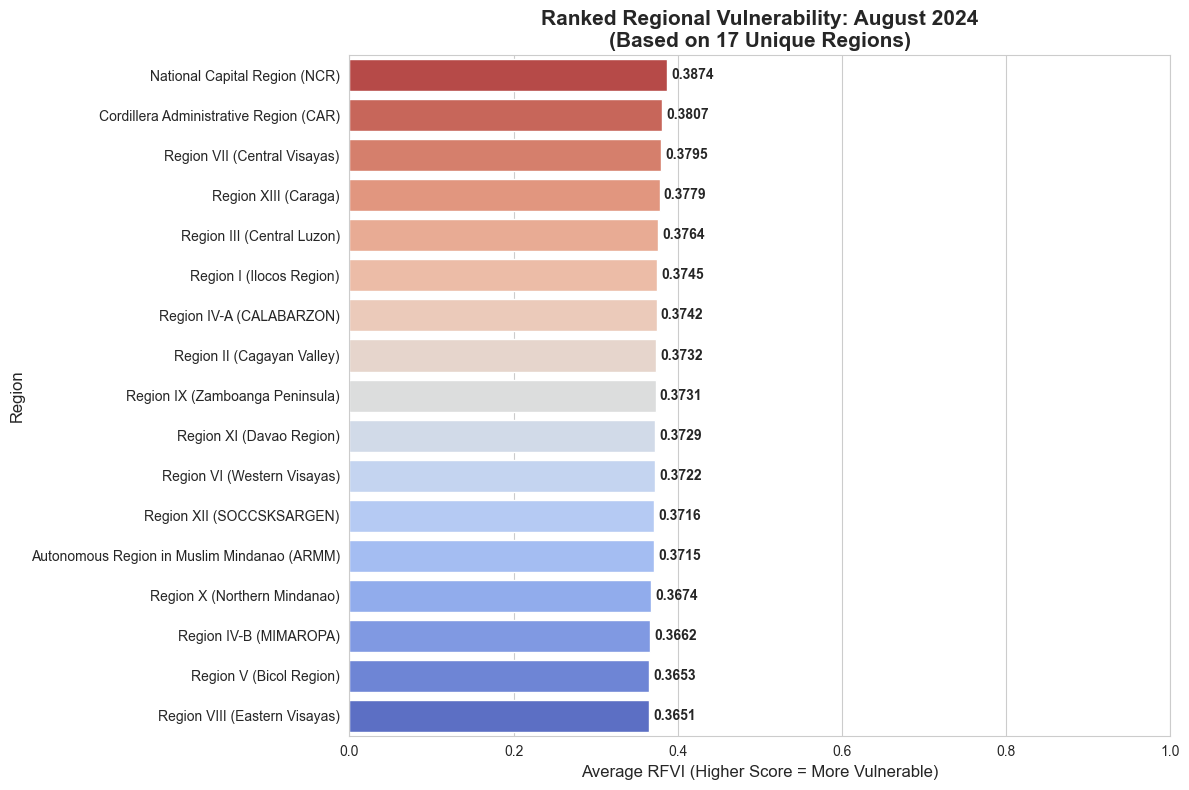

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

# --- 1. LOAD CONFIGURATION ---
BASE_PATH = Path(cfg["BASE_PATH"])
SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

def plot_clean_monthly_rankings():
    # 1. Get and sort folders chronologically
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    
    def sort_key(f):
        parts = f.name.split('_')
        return (int(parts[0]), month_order.index(parts[1]))
    
    sorted_folders = sorted(folders, key=sort_key)

    for folder in sorted_folders:
        year_val, month_val = folder.name.split('_')
        file_path = folder / f"RFVI_{folder.name}.csv"
        
        if file_path.exists():
            # 2. Load only the necessary columns
            df = pd.read_csv(file_path, usecols=['Region', 'RFVI'], low_memory=False)
            
            # 3. Explicitly Group by Unique Region and calculate Mean RFVI
            # This ensures we have exactly one bar per unique region string
            region_means = df.groupby('Region')['RFVI'].mean().reset_index()
            
            # 4. Sort from Highest RFVI to Lowest
            region_means = region_means.sort_values('RFVI', ascending=False).reset_index(drop=True)
            
            # Count unique regions for confirmation (should be 17 for Philippines)
            num_regions = region_means['Region'].nunique()

            # 5. Plotting
            plt.figure(figsize=(12, 8))
            
            # Create a horizontal bar chart
            sns.barplot(
                data=region_means, 
                x='RFVI', 
                y='Region', 
                hue='Region',
                palette='coolwarm_r', # High RFVI (Vulnerable) = Red, Low = Blue
                legend=False
            )

            # 6. Formatting
            plt.title(f"Ranked Regional Vulnerability: {month_val} {year_val}\n(Based on {num_regions} Unique Regions)", 
                      fontsize=15, weight='bold')
            plt.xlabel("Average RFVI (Higher Score = More Vulnerable)", fontsize=12)
            plt.ylabel("Region", fontsize=12)
            plt.xlim(0, 1) # Maintain consistent scale
            
            # Add numeric labels to each bar for precise reading
            for i, val in enumerate(region_means['RFVI']):
                plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontweight='bold')

            plt.tight_layout()
            plt.show()
            plt.close()

if __name__ == "__main__":
    plot_clean_monthly_rankings()

Key Insight:

- Rankings **vary across months**, indicating that regional vulnerability is not static but responds to time-specific economic and structural conditions.
- Some regions may consistently appear in higher or lower positions, while others shift significantly between survey rounds.

Implication:

Regional financial vulnerability exhibits temporal fluctuations. The changing rankings highlight short-term shocks or adjustments, while repeated high or low placements may indicate persistent vulnerability or resilience.

These monthly visualizations therefore support:
- Temporal monitoring of regional vulnerability trends
- Identification of regions with recurring high vulnerability
- Differentiation between temporary spikes and long-term risk

---
### Overall RFVI Ranking (2018-2024)

After generating the RFVI ranking across survey months, the final overall RFVI ranking across all regions is also computed.

The overall RFVI visualization:
- Ranks regions from most to least vulnerable by mean RFVI
- Displays percentage of RFVI values

This provides an **overall financial vulnerability ranking across time.**

Reading 40 months of data to compute overall averages...

Overall ranking saved to: G:\My Drive\Labor Force Survey\Survey Data with Factor Scores and RFVI\Overall_Regional_RFVI_Ranking.csv


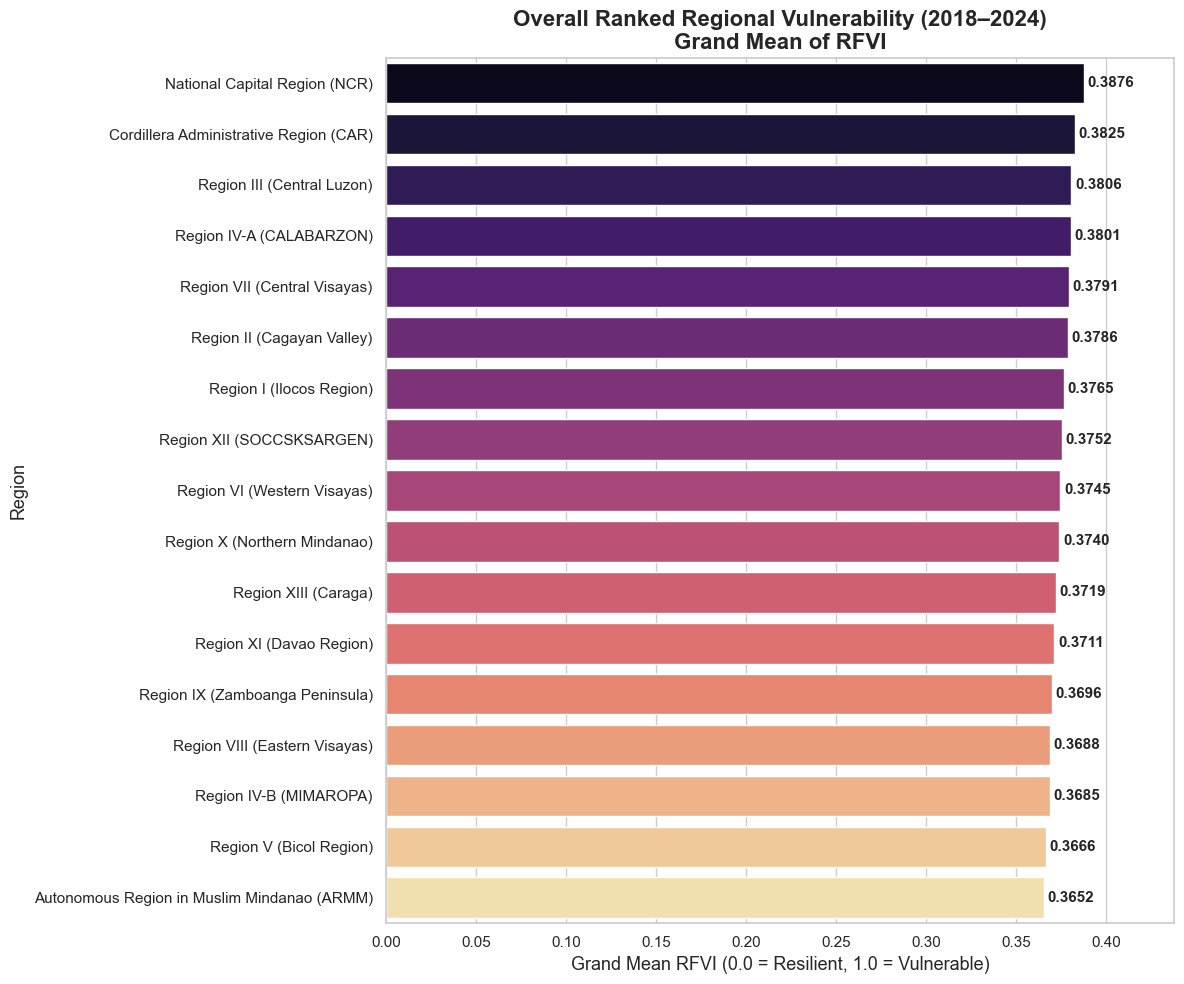


--- Regional Rankings ---
                                         Region      RFVI
0                 National Capital Region (NCR)  0.387581
1        Cordillera Administrative Region (CAR)  0.382473
2                    Region III (Central Luzon)  0.380616
3                      Region IV-A (CALABARZON)  0.380143
4                  Region VII (Central Visayas)  0.379097
5                    Region II (Cagayan Valley)  0.378641
6                      Region I (Ilocos Region)  0.376531
7                     Region XII (SOCCSKSARGEN)  0.375158
8                   Region VI (Western Visayas)  0.374517
9                  Region X (Northern Mindanao)  0.373956
10                         Region XIII (Caraga)  0.371922
11                     Region XI (Davao Region)  0.371145
12              Region IX (Zamboanga Peninsula)  0.369630
13                Region VIII (Eastern Visayas)  0.368803
14                       Region IV-B (MIMAROPA)  0.368530
15                      Region V (Bicol Regio

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc

# --- 1. SETTINGS ---
# Assuming cfg is already loaded or defined as per your previous blocks
SOURCE_DIR = Path(cfg["BASE_PATH"]) / "Survey Data with Factor Scores and RFVI"

def compute_overall_regional_average():
    # 1. Collect all monthly files
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    all_regional_data = []

    print(f"Reading {len(folders)} months of data to compute overall averages...")

    for folder in folders:
        file_path = folder / f"RFVI_{folder.name}.csv"
        if file_path.exists():
            # Load only Region and RFVI to keep memory usage low
            df = pd.read_csv(file_path, usecols=['Region', 'RFVI'])
            
            # Get the mean for THIS month first (efficient aggregation)
            monthly_mean = df.groupby('Region')['RFVI'].mean().reset_index()
            all_regional_data.append(monthly_mean)
            
            del df
            gc.collect()

    # 2. Combine all monthly averages into one Master Dataframe
    master_df = pd.concat(all_regional_data, ignore_index=True)

    # 3. Calculate the GRAND AVERAGE per Region across the whole study period
    overall_ranking = master_df.groupby('Region')['RFVI'].mean().reset_index()
    overall_ranking = overall_ranking.sort_values('RFVI', ascending=False).reset_index(drop=True)

    # 4. Save the results to a CSV for your thesis tables
    overall_ranking.to_csv(SOURCE_DIR / "Overall_Regional_RFVI_Ranking.csv", index=False)
    print(f"\nOverall ranking saved to: {SOURCE_DIR / 'Overall_Regional_RFVI_Ranking.csv'}")

    # 5. Plotting the Definitive Ranking
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")
    
    plot = sns.barplot(
        data=overall_ranking, 
        x='RFVI', 
        y='Region', 
        hue='Region',
        palette='magma', # A strong, academic palette
        legend=False
    )

    # Formatting
    plt.title("Overall Ranked Regional Vulnerability (2018–2024)\nGrand Mean of RFVI", 
              fontsize=16, weight='bold')
    plt.xlabel("Grand Mean RFVI (0.0 = Resilient, 1.0 = Vulnerable)", fontsize=13)
    plt.ylabel("Region", fontsize=13)
    plt.xlim(0, max(overall_ranking['RFVI']) + 0.05) 

    # Add data labels
    for i, val in enumerate(overall_ranking['RFVI']):
        plt.text(val + 0.002, i, f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

    return overall_ranking

if __name__ == "__main__":
    ranking = compute_overall_regional_average()
    print("\n--- Regional Rankings ---")
    print(ranking)

Key Insight:

- Based on the overall RFVI ranking, the **National Capital Region (NCR)** shows the highest average financial vulnerability, closely followed by the **Cordillera Administrative Region (CAR)**, **Region III (Central Luzon)**, and **Region IV-A (CALABARZON)**.
- **Autonomous Region in Muslim Mindanao (ARMM)** has the lowest overall RFVI, indicating comparatively lower average financial vulnerability across the period.
- The difference between the highest and lowest regions is relatively small (about 2.2 percentage points), indicating that financial vulnerability levels are fairly close across regions.
- Several Luzon-based regions appear near the top of the ranking, suggesting that higher financial vulnerability is observed across a wide range of regions, including those that are more urbanized and centrally located.

Implication:

This ranking reflects the long-term average pattern from 2018 to 2024, rather than conditions in a single survey month.

Although monthly rankings may fluctuate, this overall average helps identify:

- Regions that consistently exhibit relatively higher financial vulnerability
- Regions that show comparatively lower vulnerability over time

The narrow spread between regions suggests that financial vulnerability is present nationwide, though the intensity varies slightly.

---
### Monthly Top 10 Provincial RFVI Rankings

RFVI is summarized at the province level for each survey month.

**For each month:**

- Average RFVI is computed per province
- Provinces are ranked by RFVI
- The top 10 most vulnerable provinces are visualized

This shows which provinces appear among the most financially vulnerable in each survey period.

Generating Top 10 rankings for 40 months...


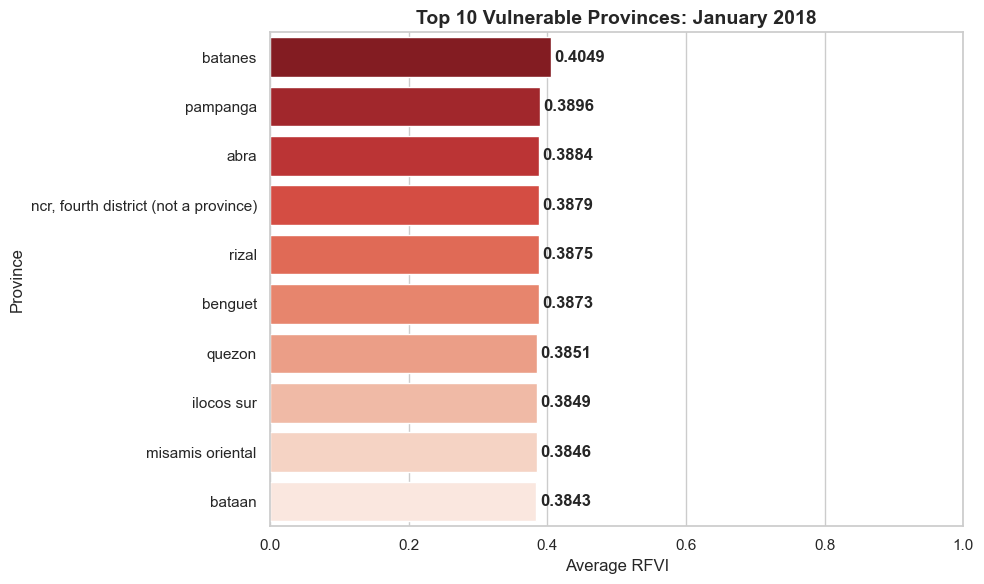

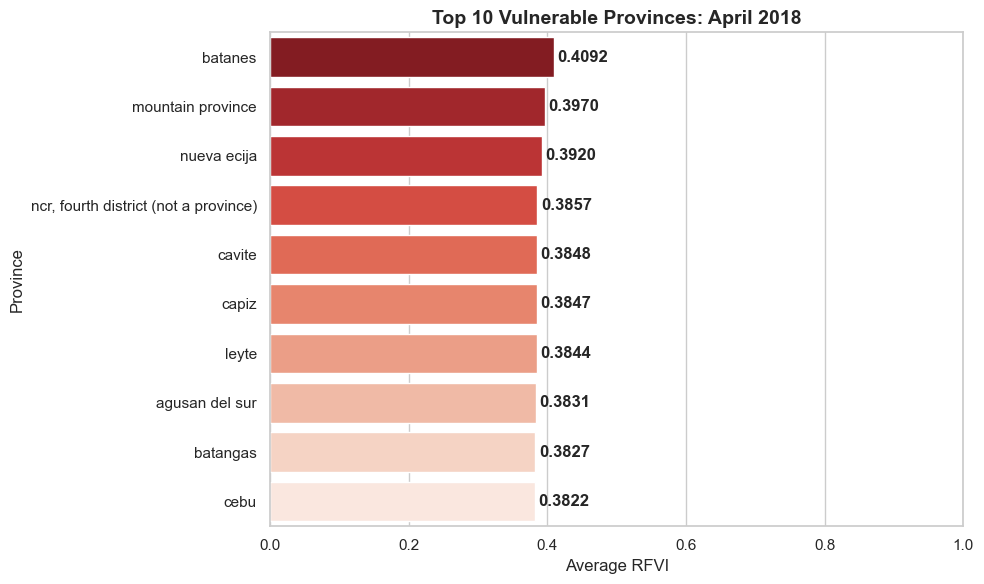

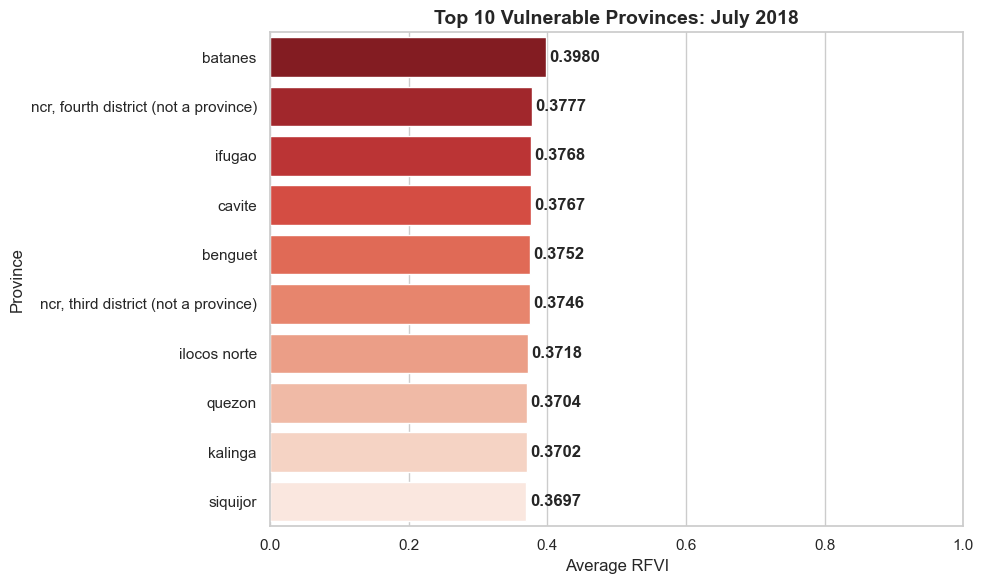

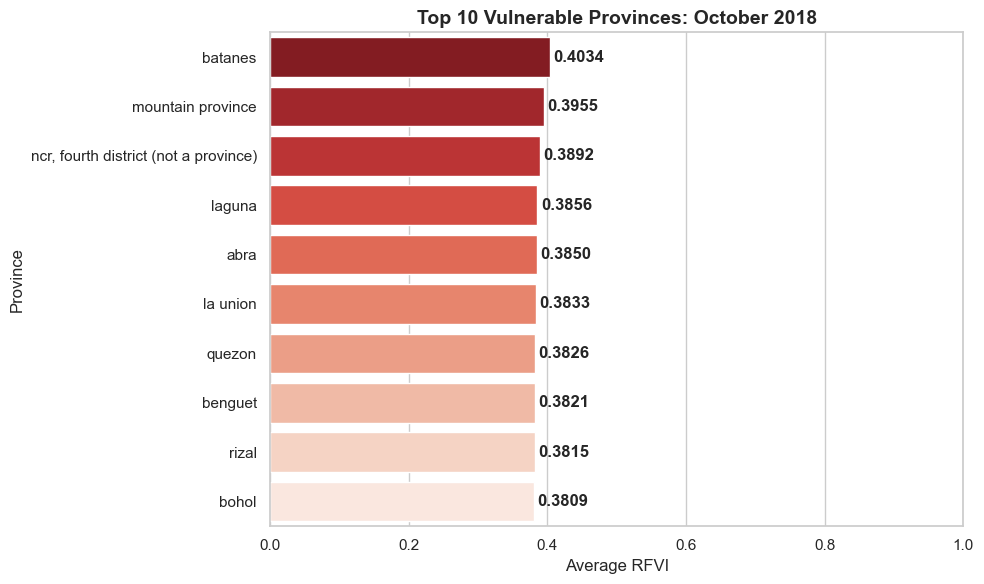

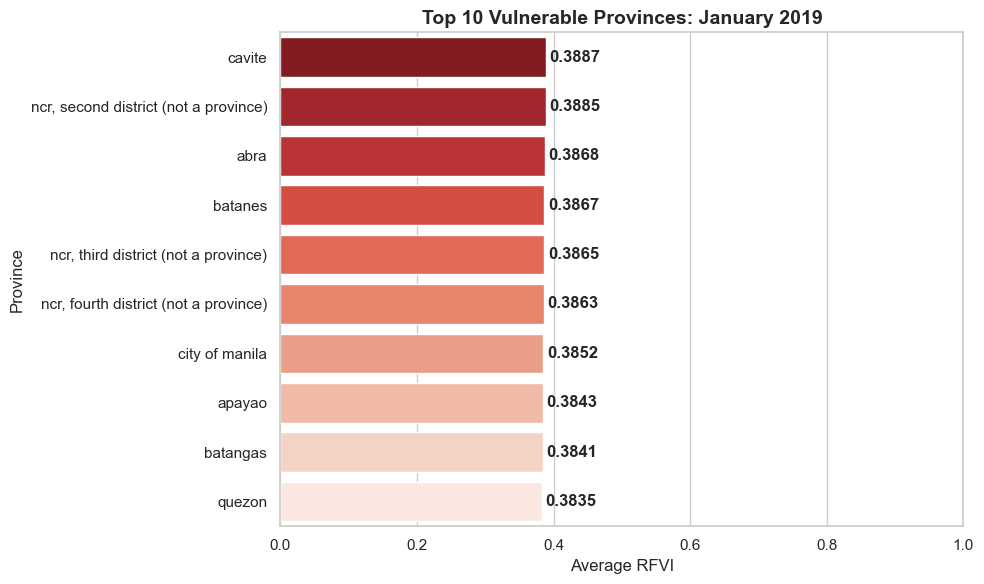

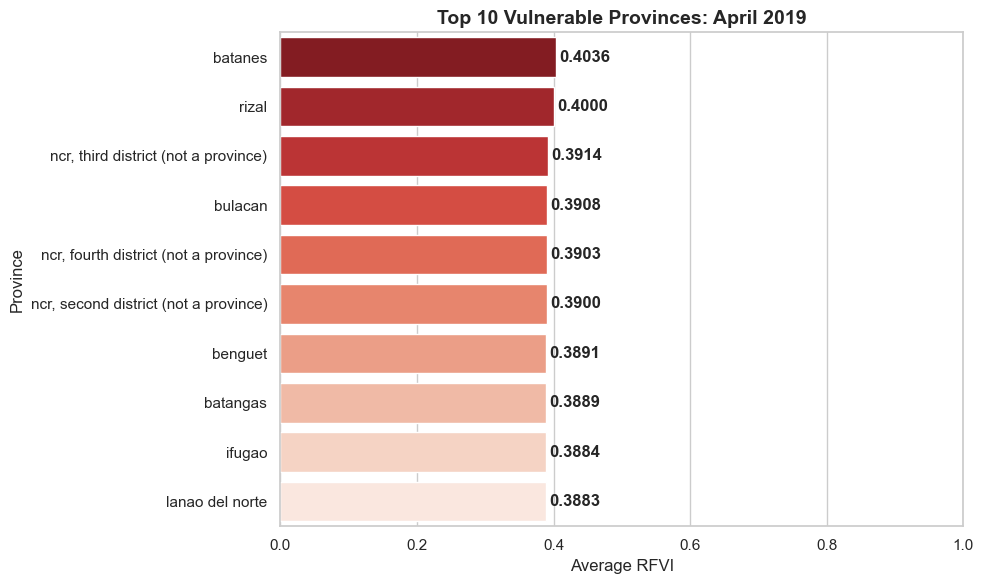

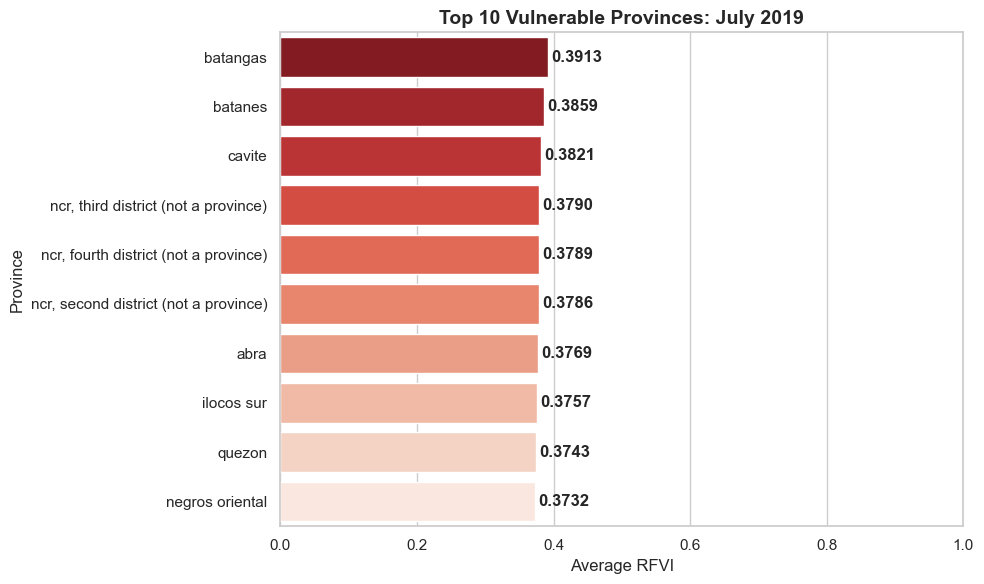

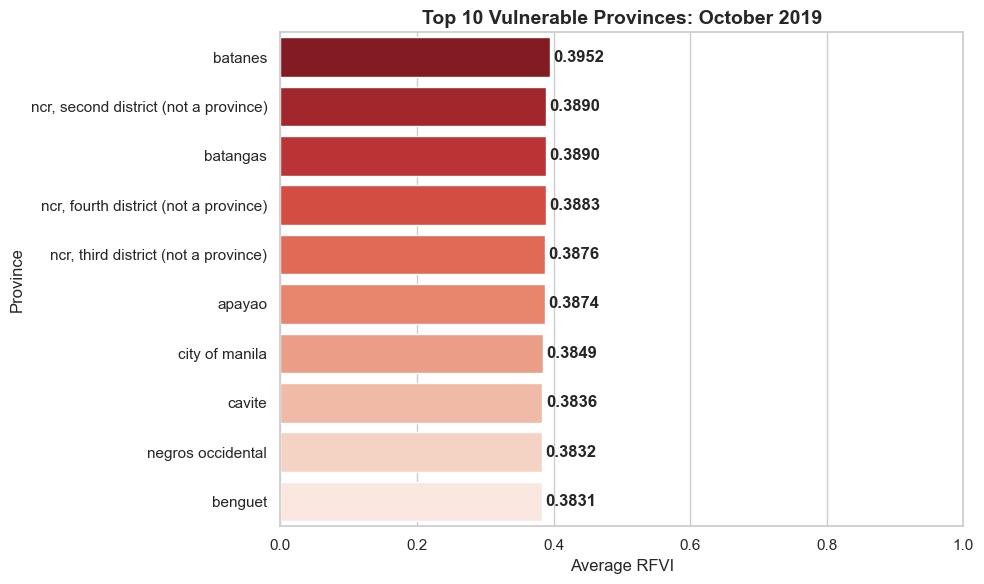

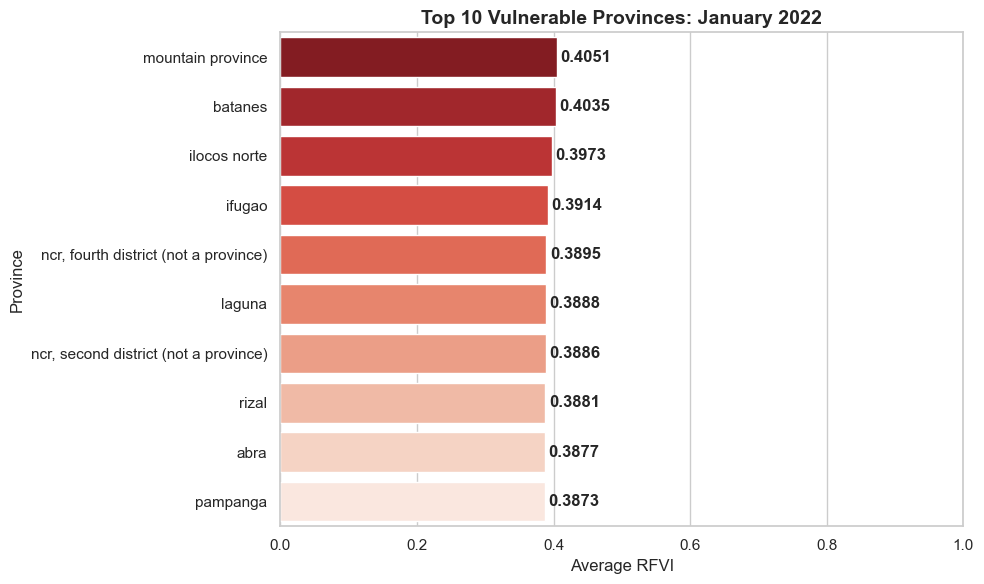

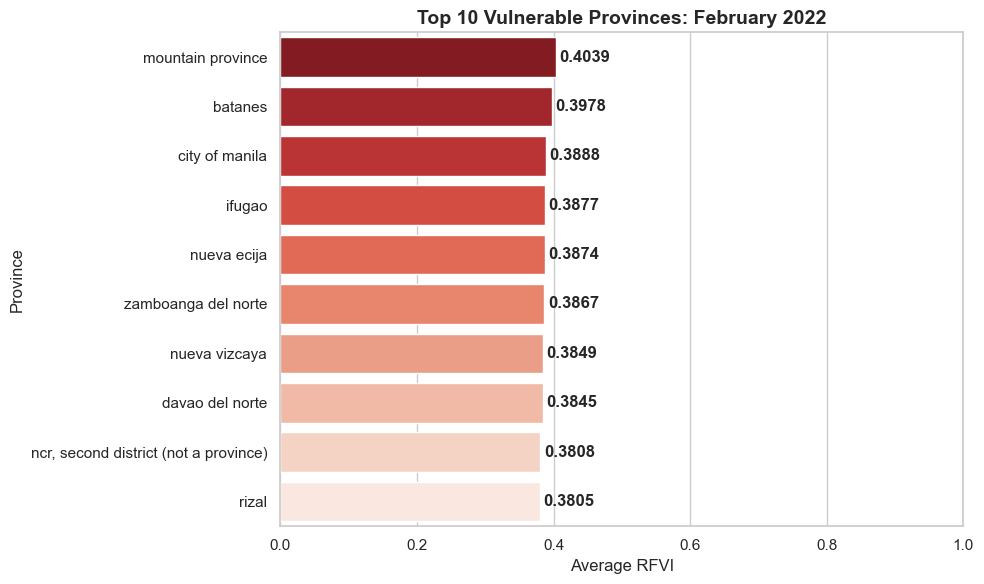

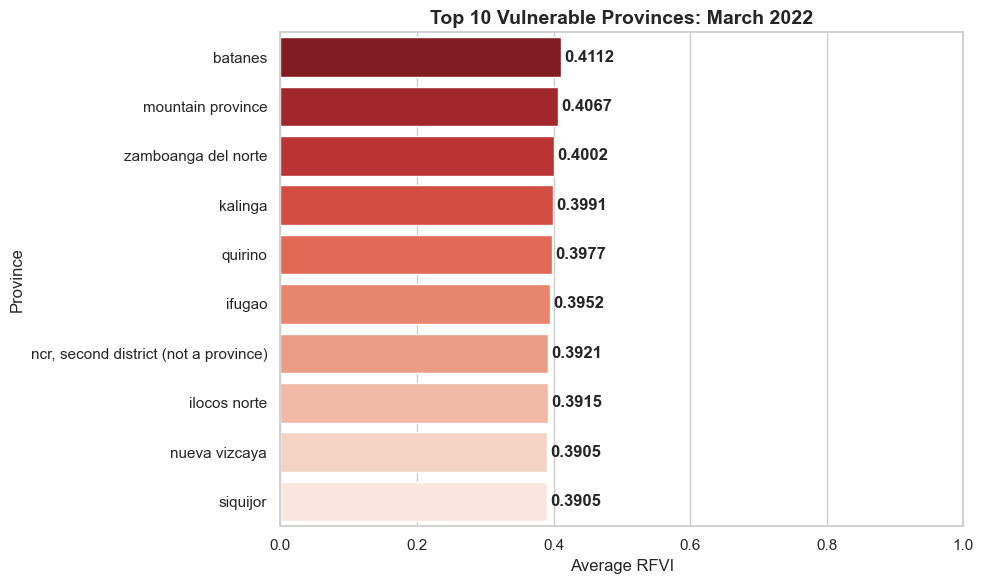

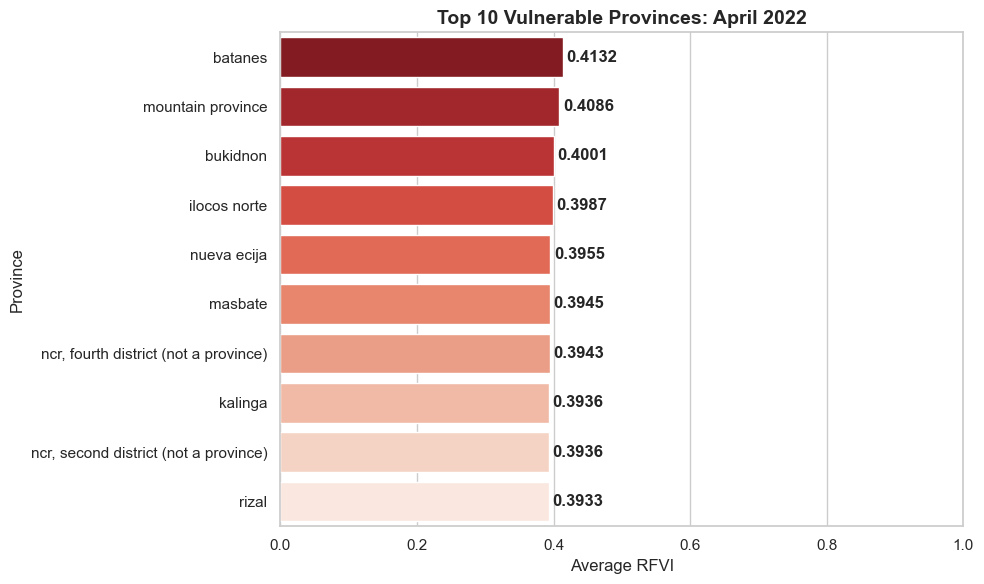

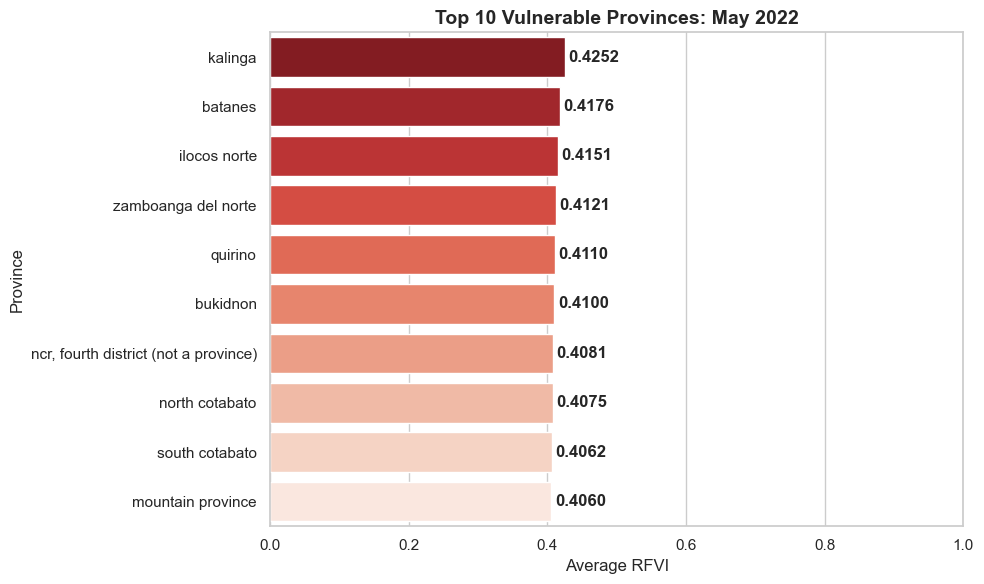

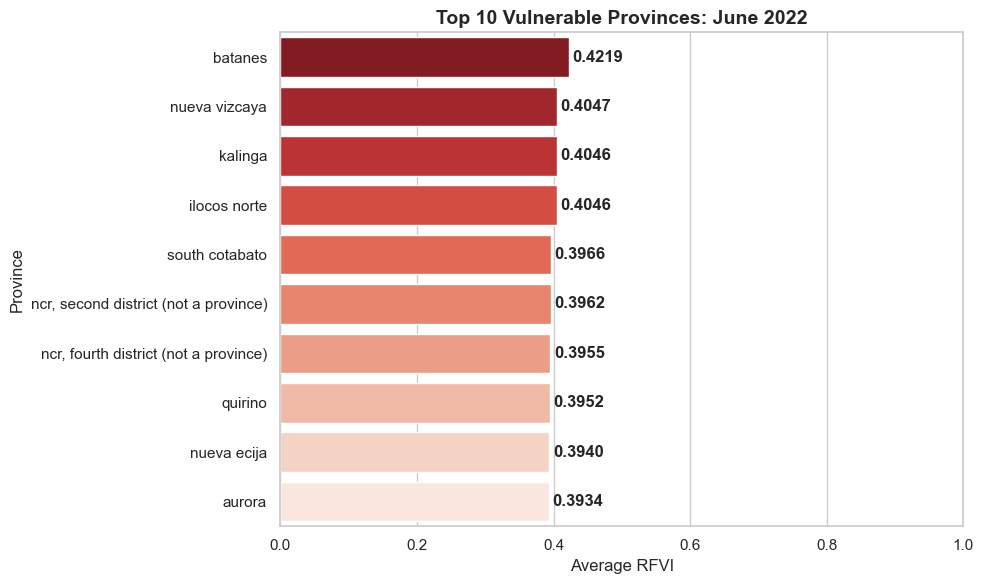

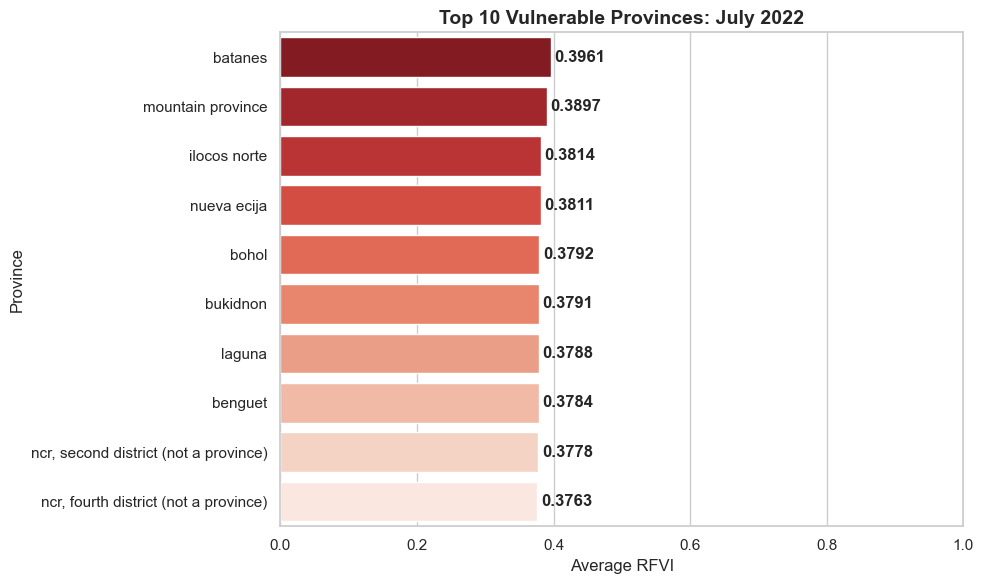

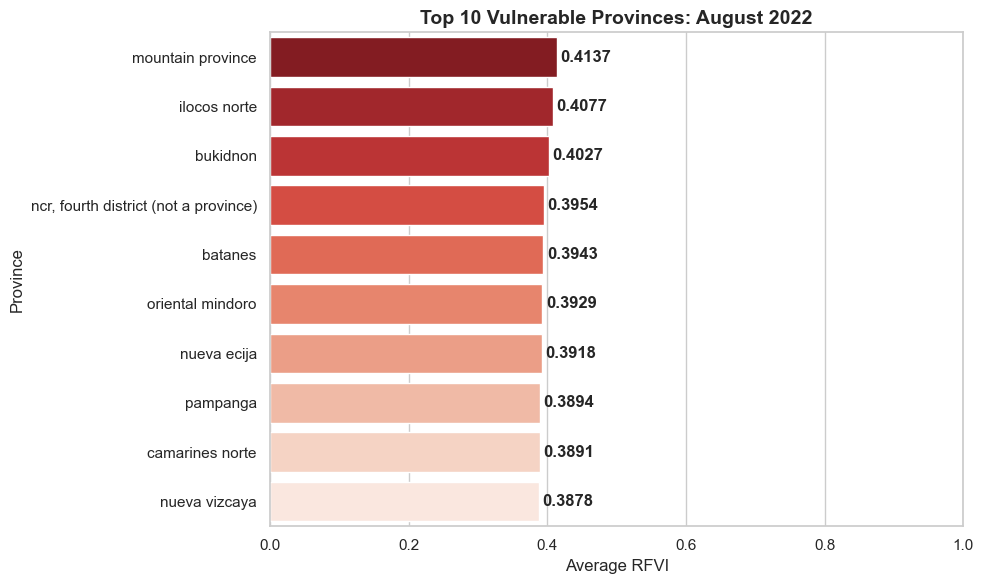

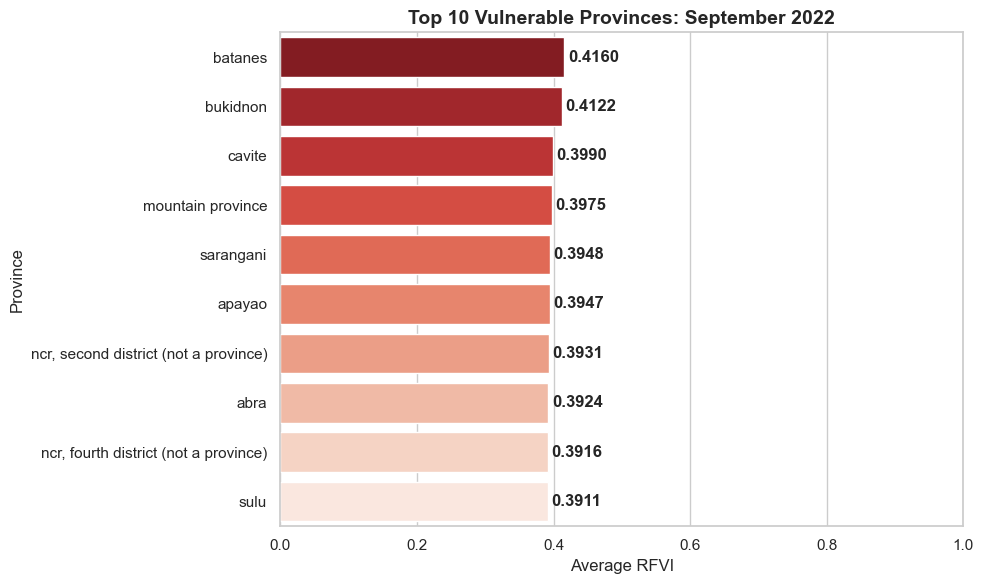

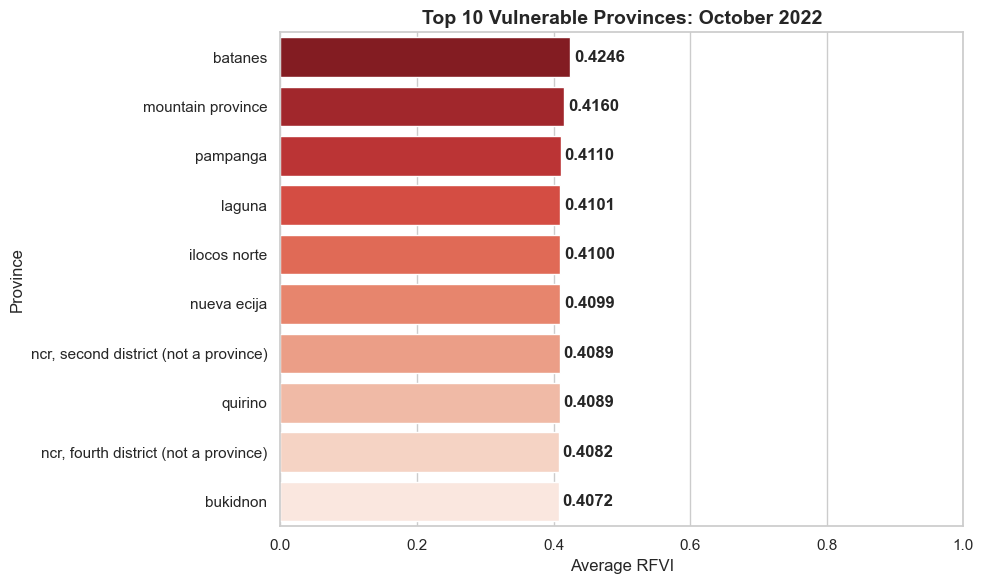

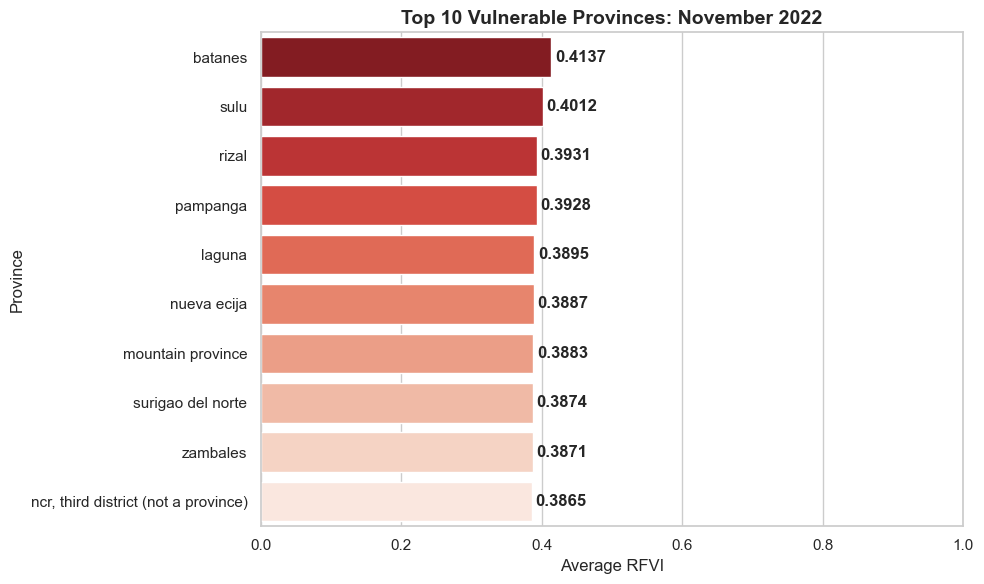

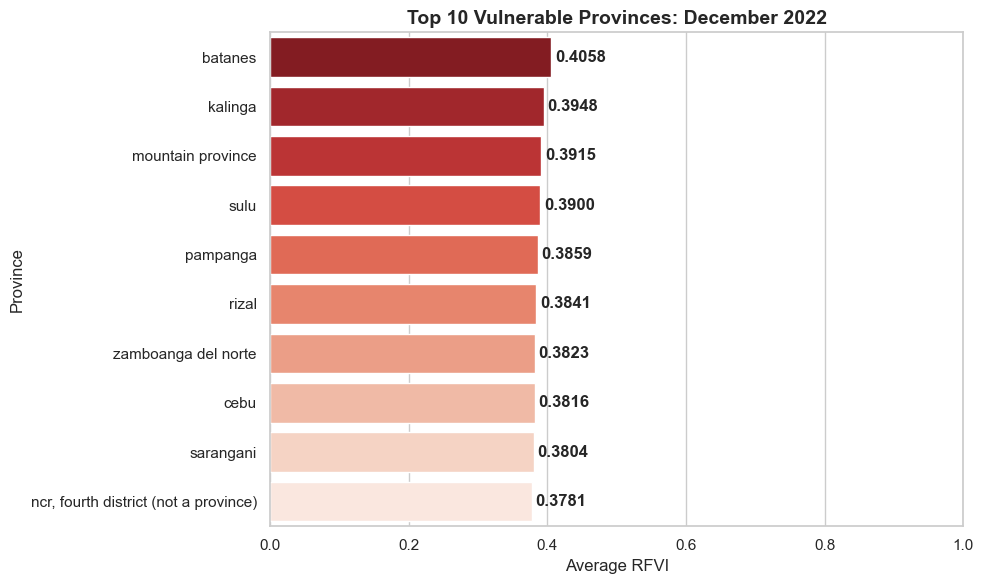

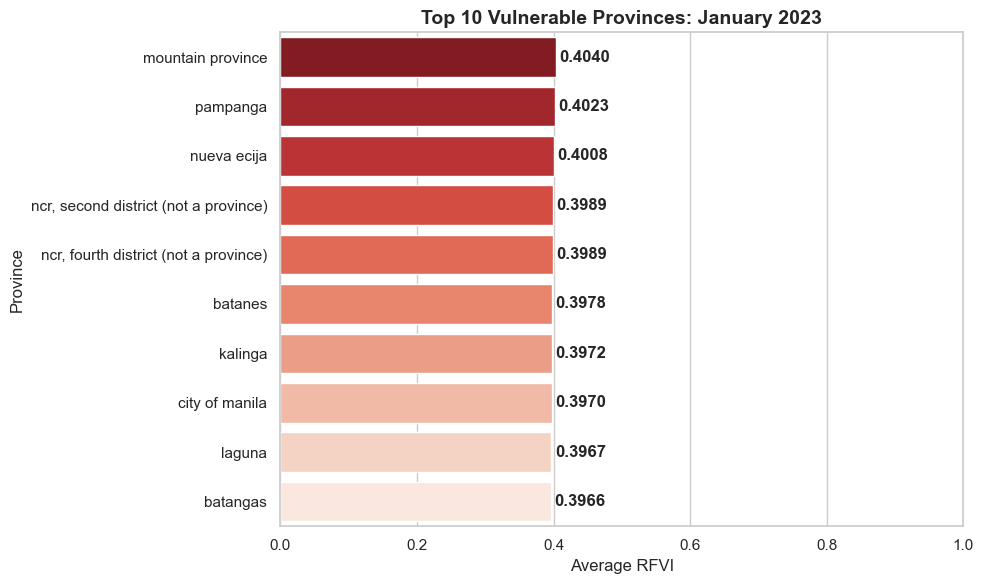

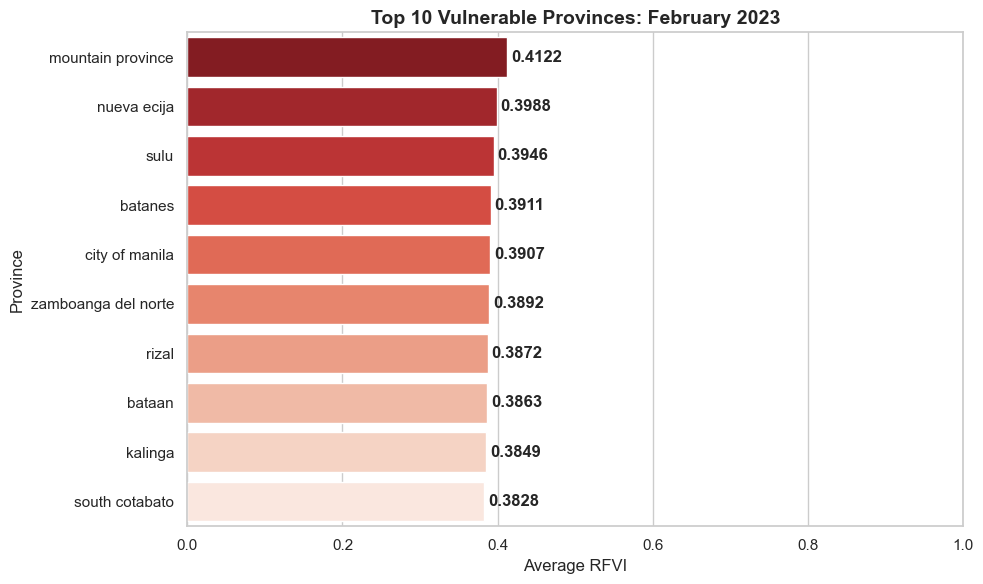

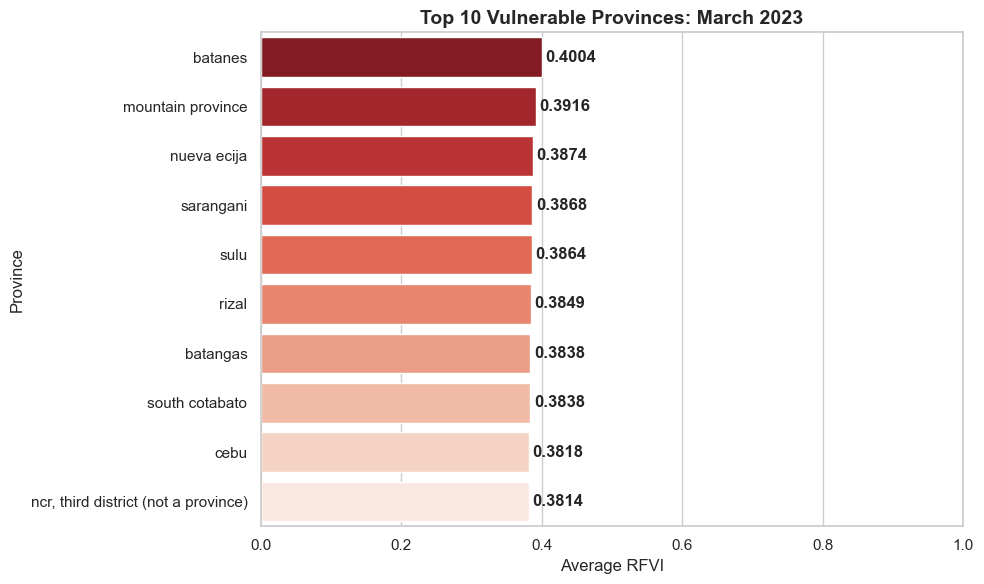

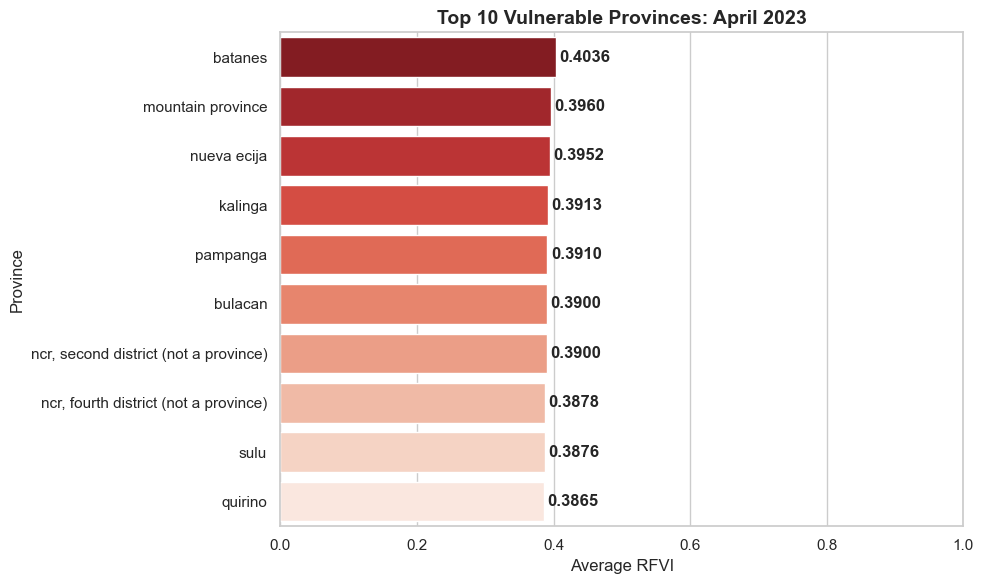

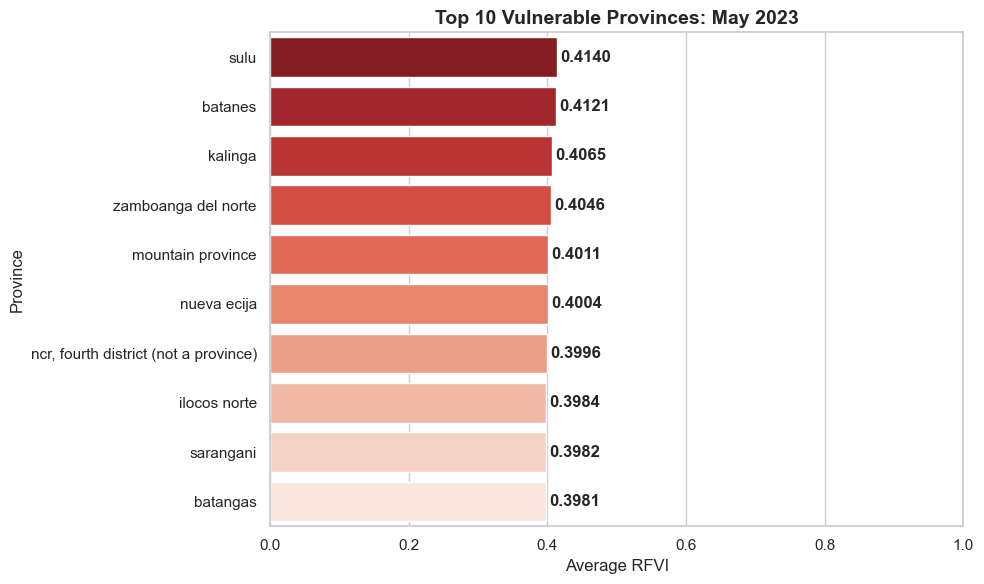

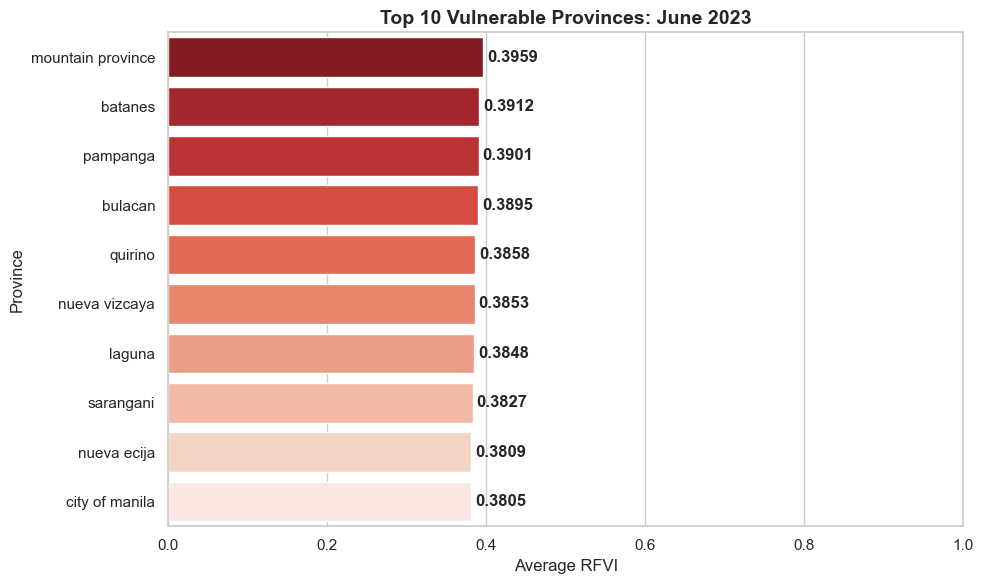

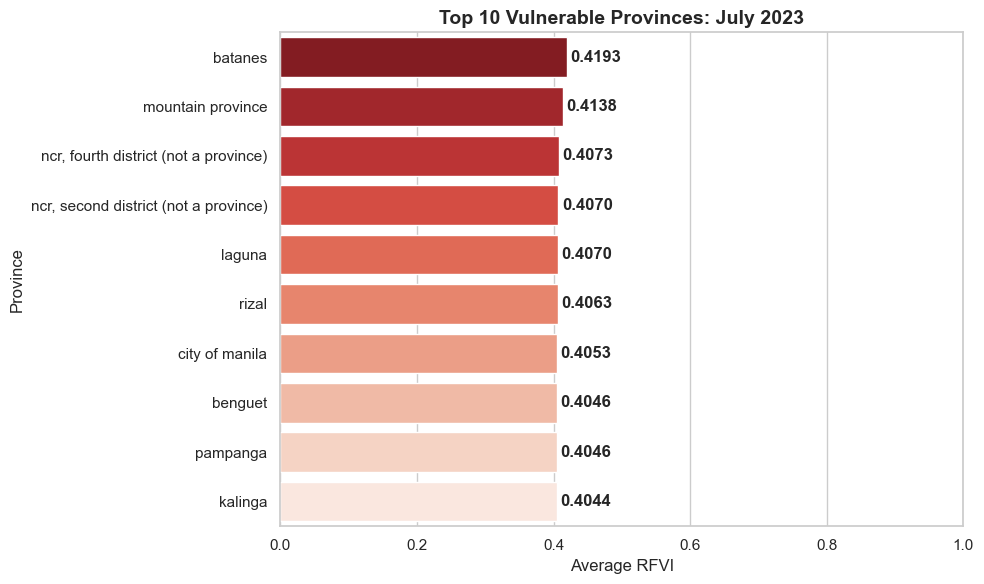

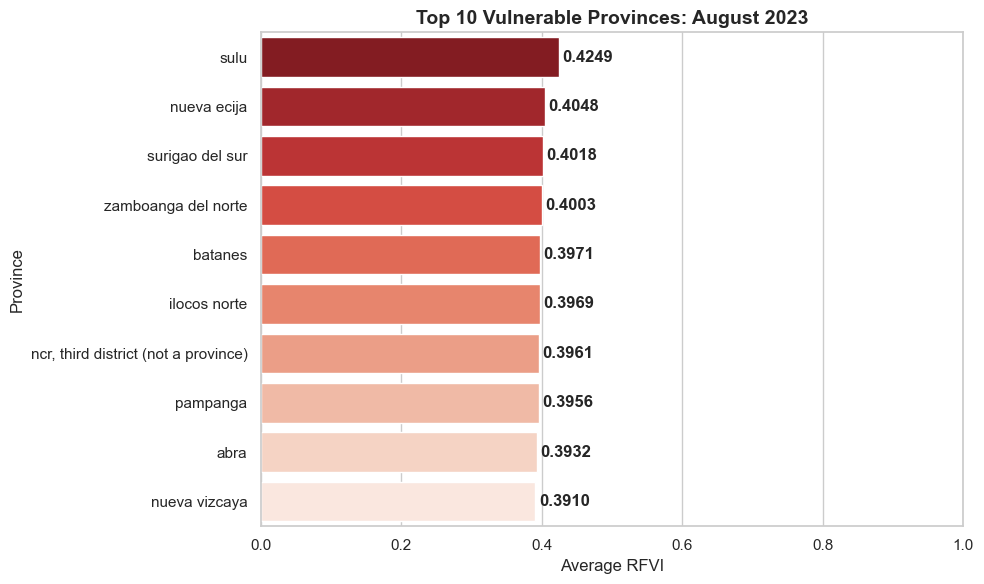

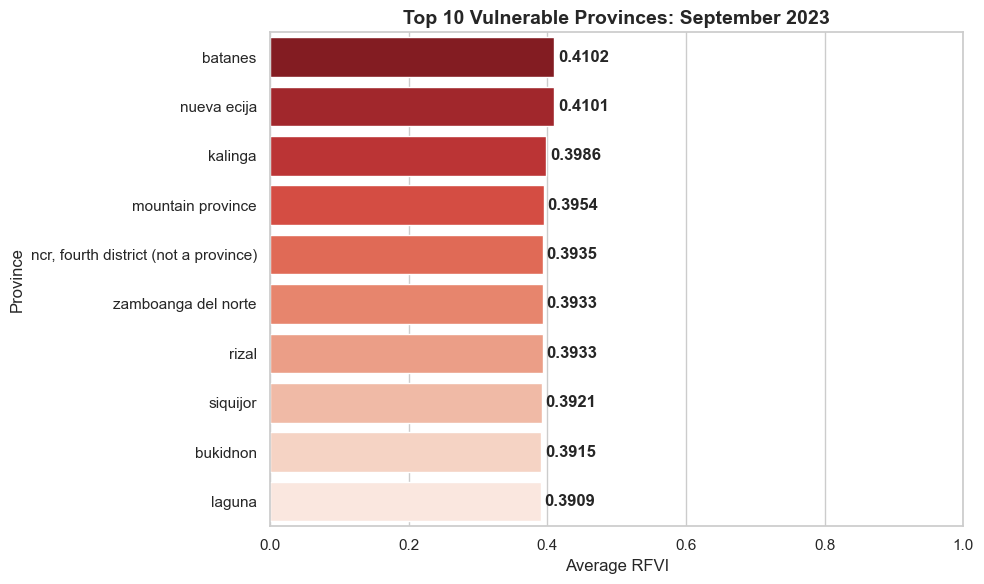

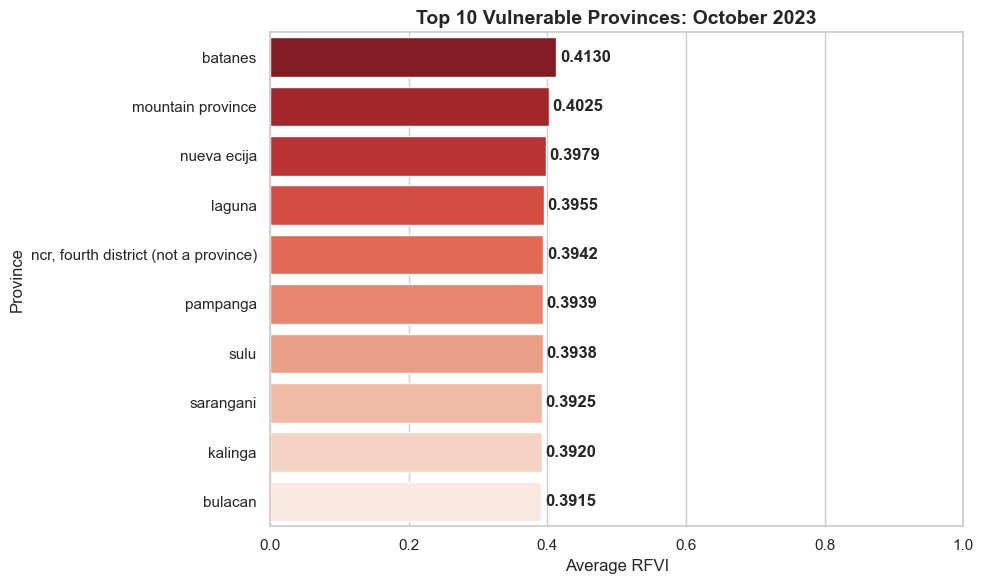

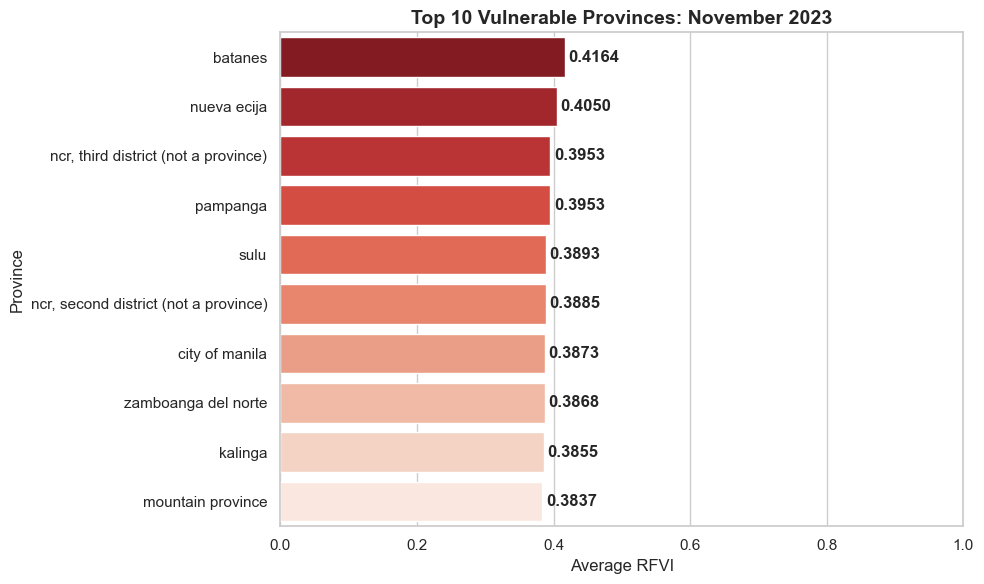

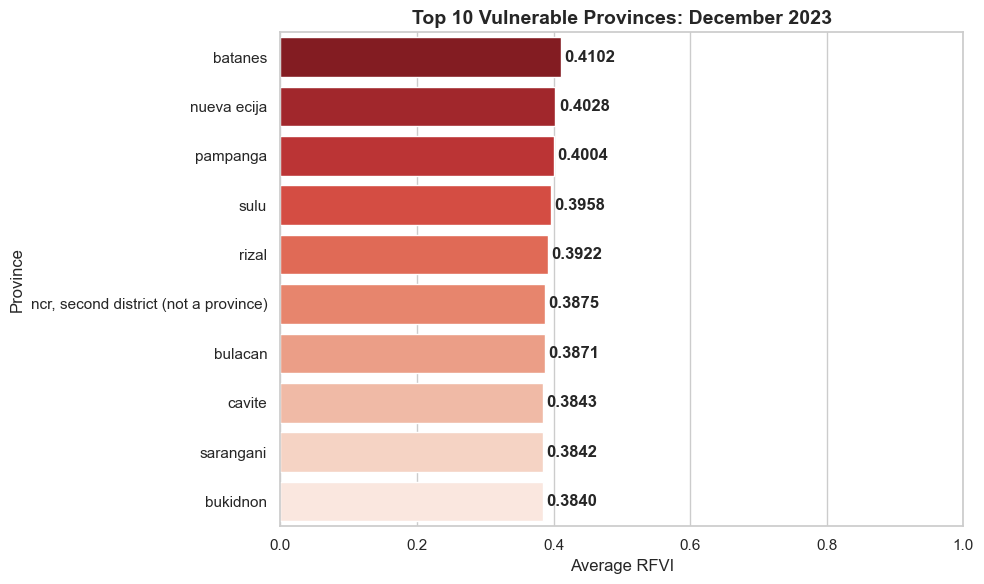

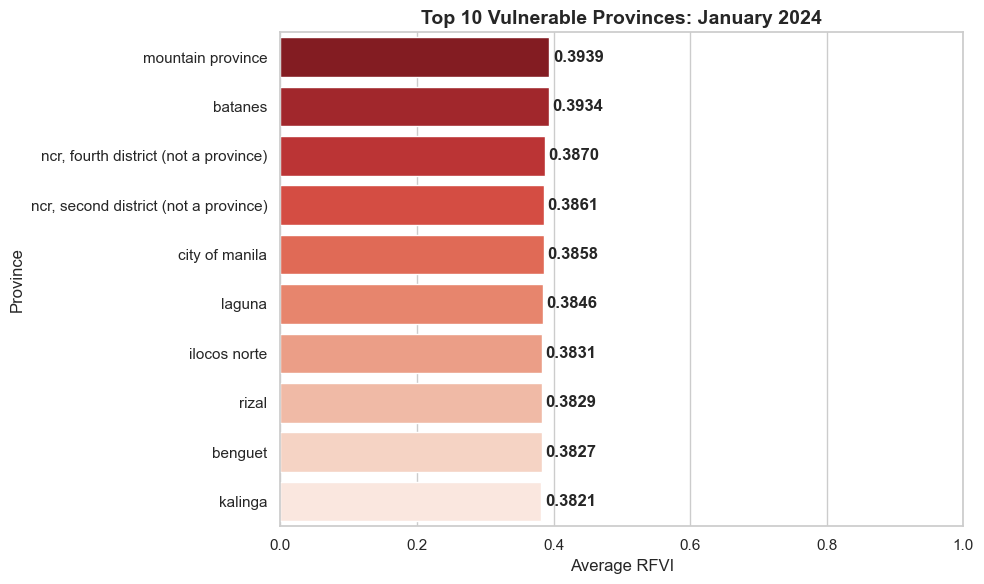

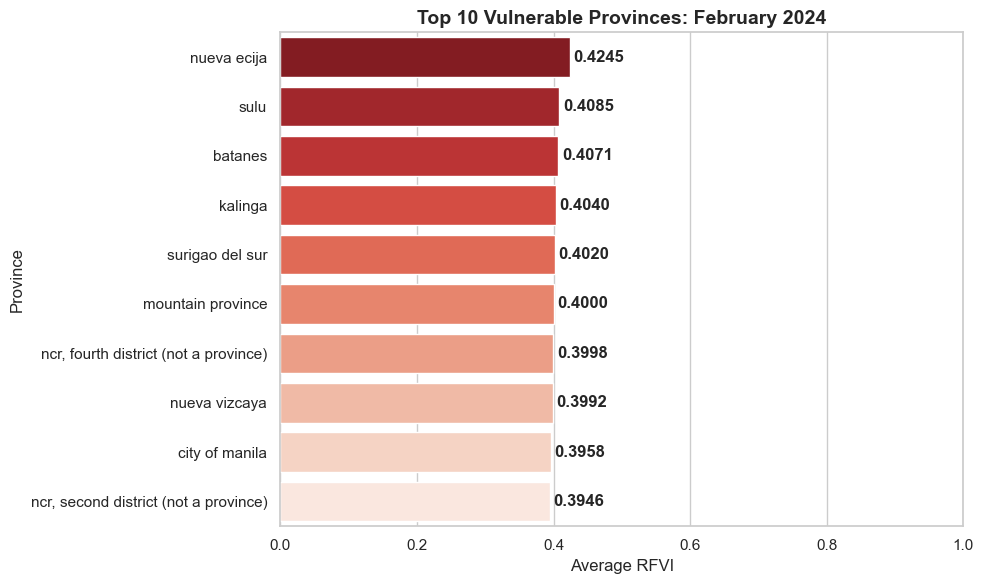

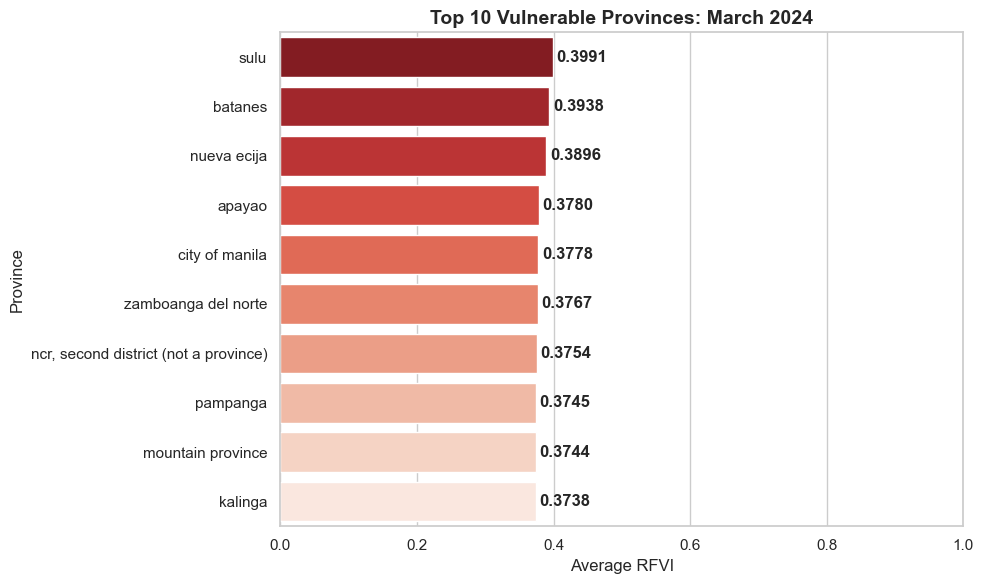

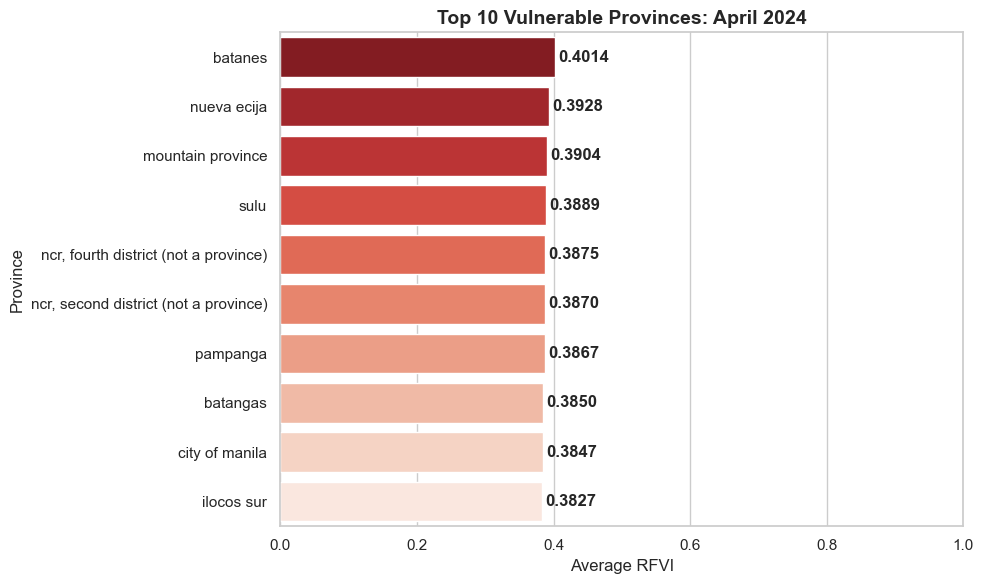

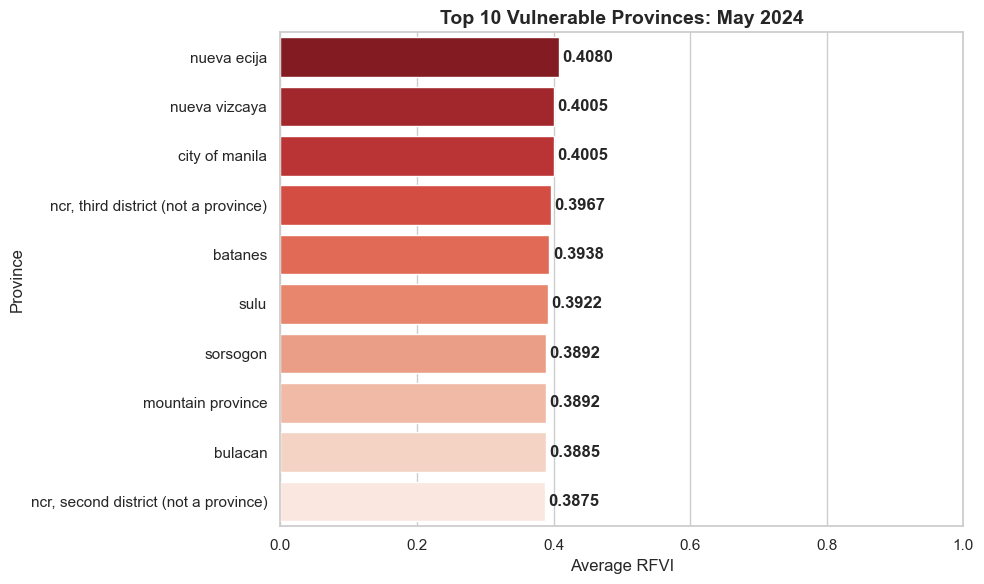

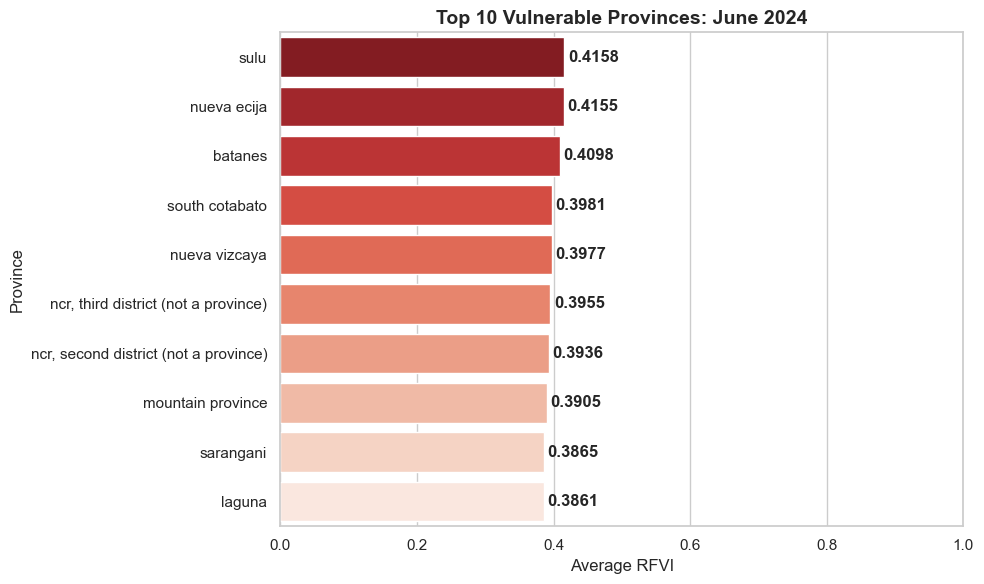

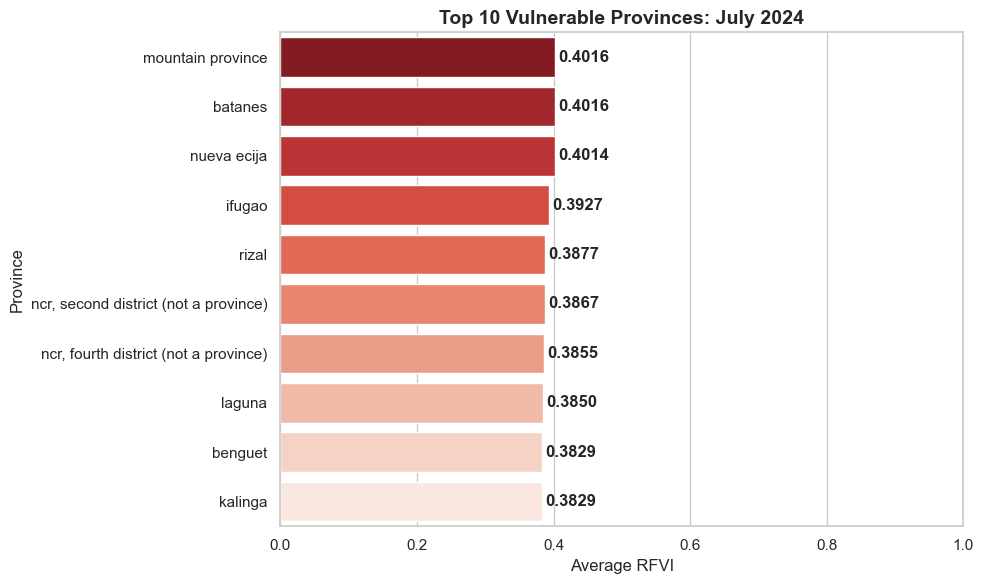

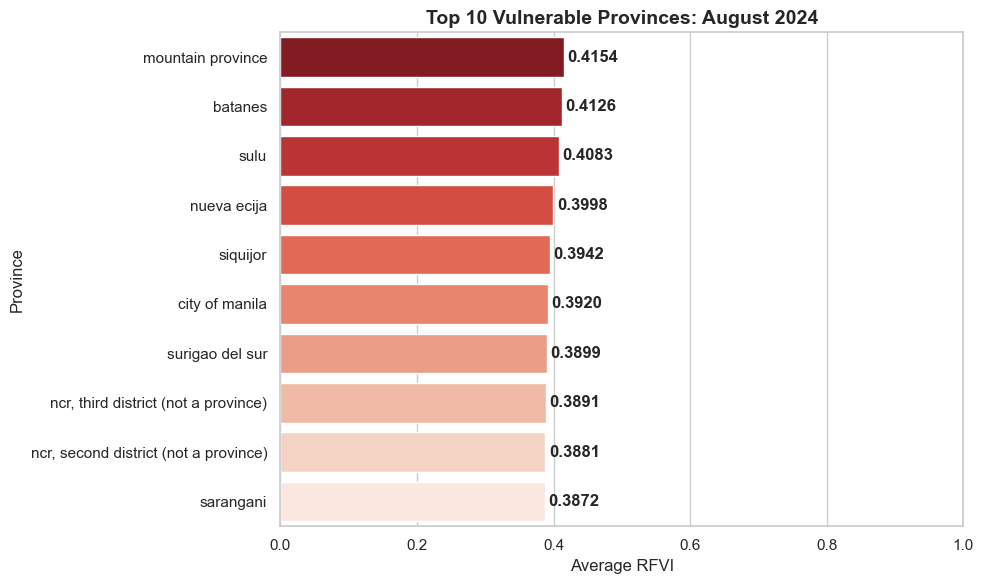

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import gc

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
except Exception as e:
    print(f"Error loading config: {e}")

# Helper for chronological sorting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

def plot_top_10_per_month():
    # 1. Get and sort folders by Year then Month
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    
    def sort_key(f):
        parts = f.name.split('_') # Expects format "YYYY_Month"
        return (int(parts[0]), month_order.index(parts[1]))
    
    sorted_folders = sorted(folders, key=sort_key)

    print(f"Generating Top 10 rankings for {len(sorted_folders)} months...")

    for folder in sorted_folders:
        file_path = folder / f"RFVI_{folder.name}.csv"
        year_val, month_val = folder.name.split('_')
        
        if file_path.exists():
            try:
                # 2. Load and calculate for THIS month only
                df = pd.read_csv(file_path, usecols=['Province', 'RFVI'], low_memory=False)
                
                # Get mean per province
                monthly_rank = df.groupby('Province')['RFVI'].mean().reset_index()
                
                # Sort and take top 10
                top_10_monthly = monthly_rank.sort_values('RFVI', ascending=False).head(10)

                # 3. Plotting
                plt.figure(figsize=(10, 6))
                sns.set_theme(style="whitegrid")
                
                sns.barplot(
                    data=top_10_monthly, 
                    x='RFVI', 
                    y='Province', 
                    palette='Reds_r',
                    hue='Province',
                    legend=False
                )

                plt.title(f"Top 10 Vulnerable Provinces: {month_val} {year_val}", 
                          fontsize=14, weight='bold')
                plt.xlabel("Average RFVI")
                plt.ylabel("Province")
                plt.xlim(0, 1.0) # Consistent scale for comparison

                # Data Labels
                for i, val in enumerate(top_10_monthly['RFVI']):
                    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontweight='bold')

                plt.tight_layout()
                plt.show() # Plot individual month
                plt.close() # Close plot to free up RAM

                # 4. Clean up
                del df, monthly_rank, top_10_monthly
                gc.collect()

            except Exception as e:
                print(f"   [ERR] Failed to plot {folder.name}: {e}")

if __name__ == "__main__":
    plot_top_10_per_month()

Key Insight:

- The **top 10 most vulnerable provinces vary across survey months**, showing that provincial RFVI rankings are not fixed over time.
- Differences in rankings may reflect actual month-to-month changes as well as **variation in survey coverage** or design, where not all provinces are observed in every survey period.

Implication:

Because provincial rankings change and depend on the survey month, financial vulnerability should be interpreted in a time-specific context.

Monthly results are useful for identifying which provinces appear more vulnerable in a given period, but should be complemented with long-term or aggregated analyses to avoid overinterpreting short-term or design-driven differences.

---
### Monthly Top 10 City/Municipality RFVI Rankings

RFVI is summarized at the **city/municipality level** for each survey month.

For each month:

- Average RFVI is computed per city/municipality
- Cities/municipalities are ranked by RFVI
- The **top 10 most financially vulnerable cities/municipalities** are visualized

This step shows which cities or municipalities appear most vulnerable in each survey month and how these rankings change over time.

Generating City/Municipality rankings for 40 months...
--------------------------------------------------
No City/Municipality in:
January 2018
------------------------------
No City/Municipality in:
April 2018
------------------------------
No City/Municipality in:
July 2018
------------------------------
No City/Municipality in:
October 2018
------------------------------
No City/Municipality in:
January 2019
------------------------------
No City/Municipality in:
April 2019
------------------------------
No City/Municipality in:
July 2019
------------------------------
No City/Municipality in:
October 2019
------------------------------


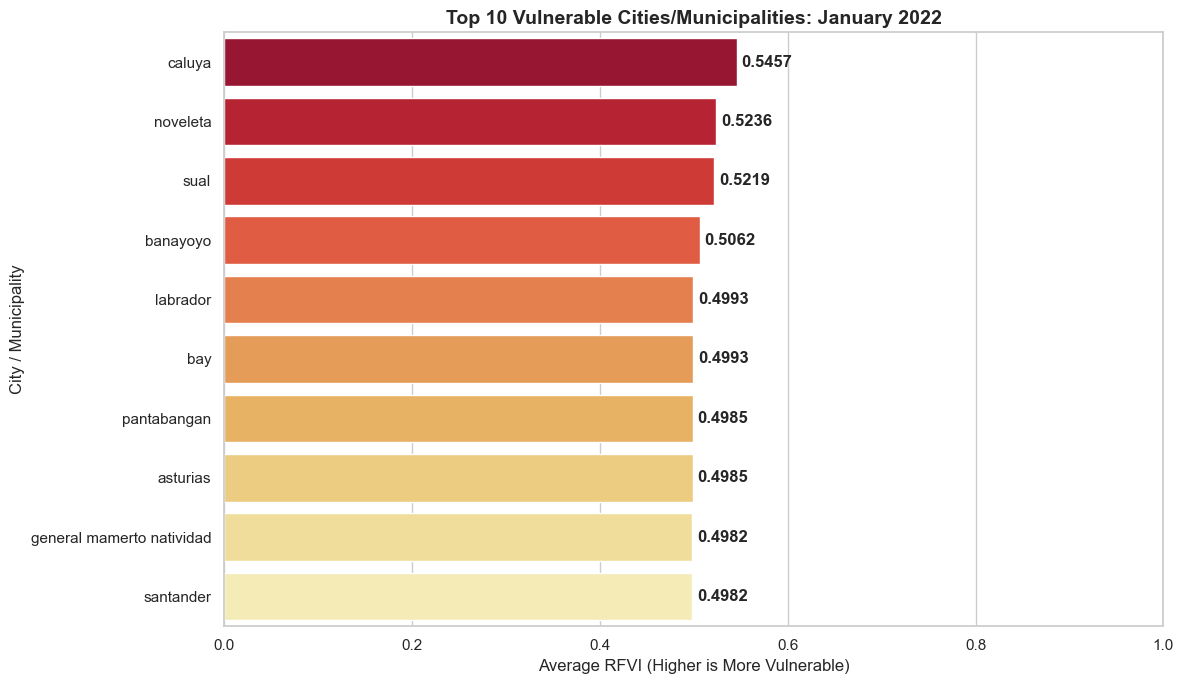

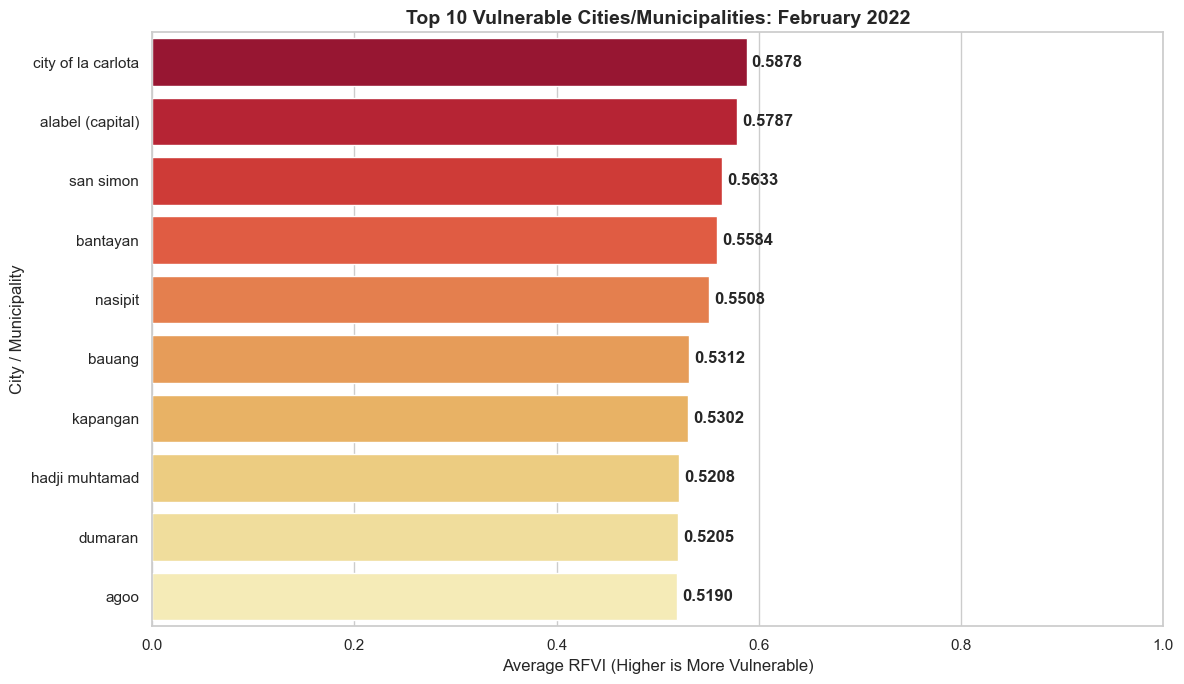

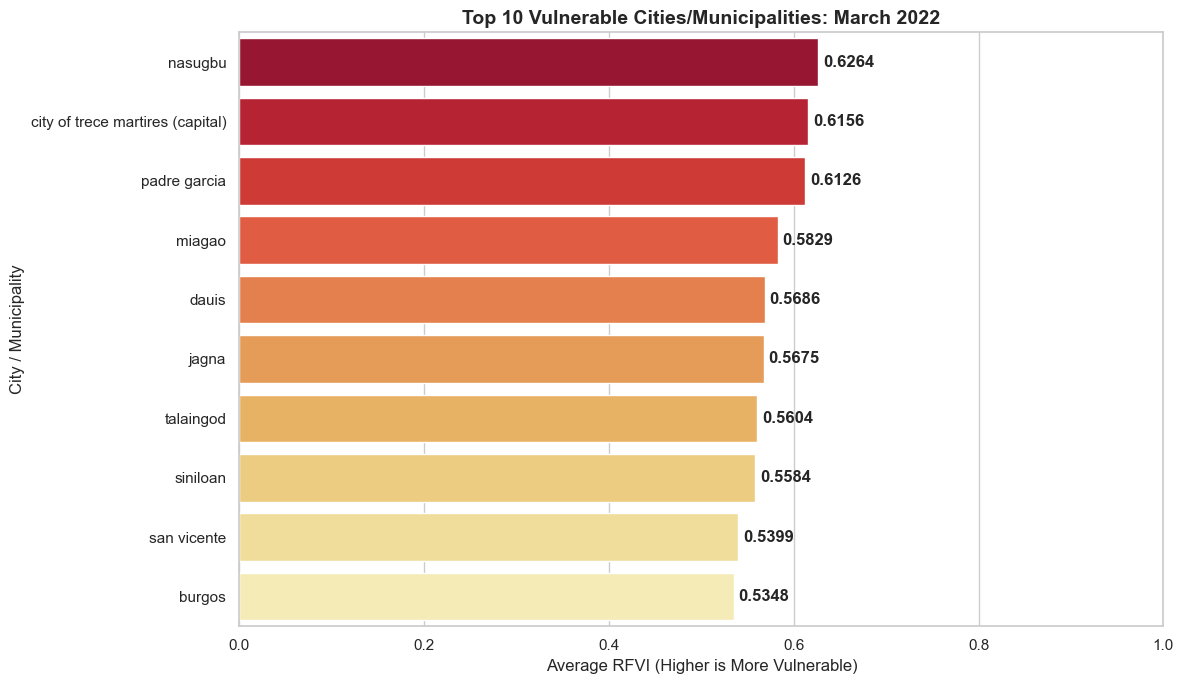

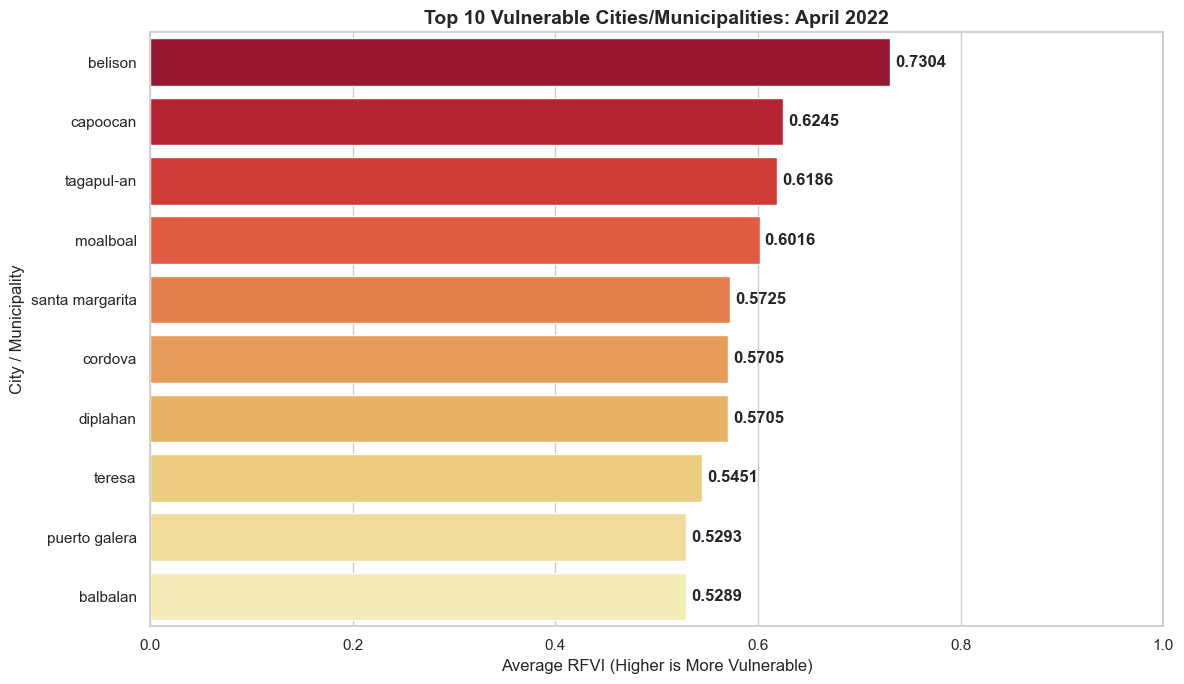

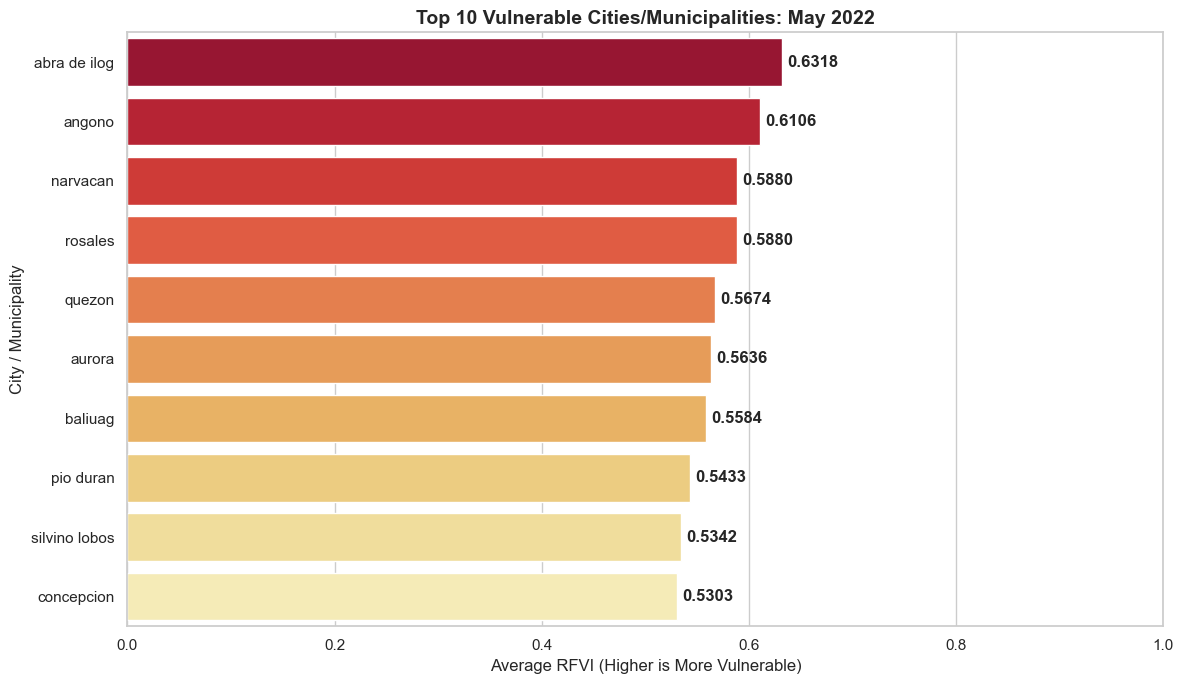

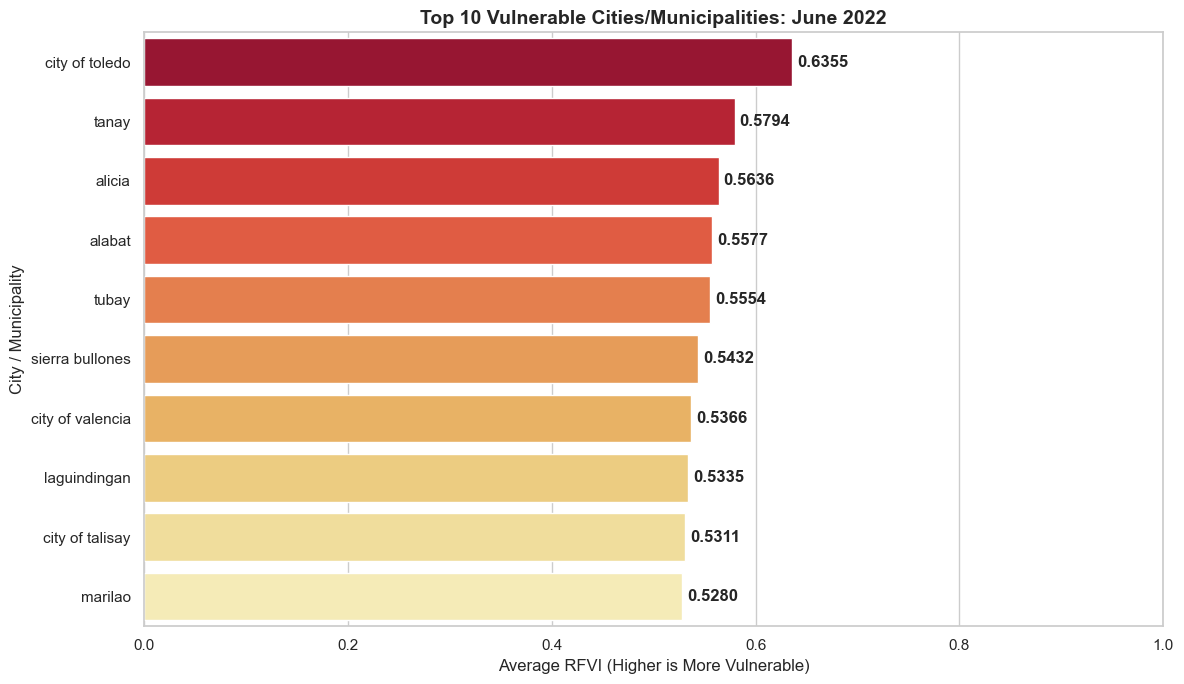

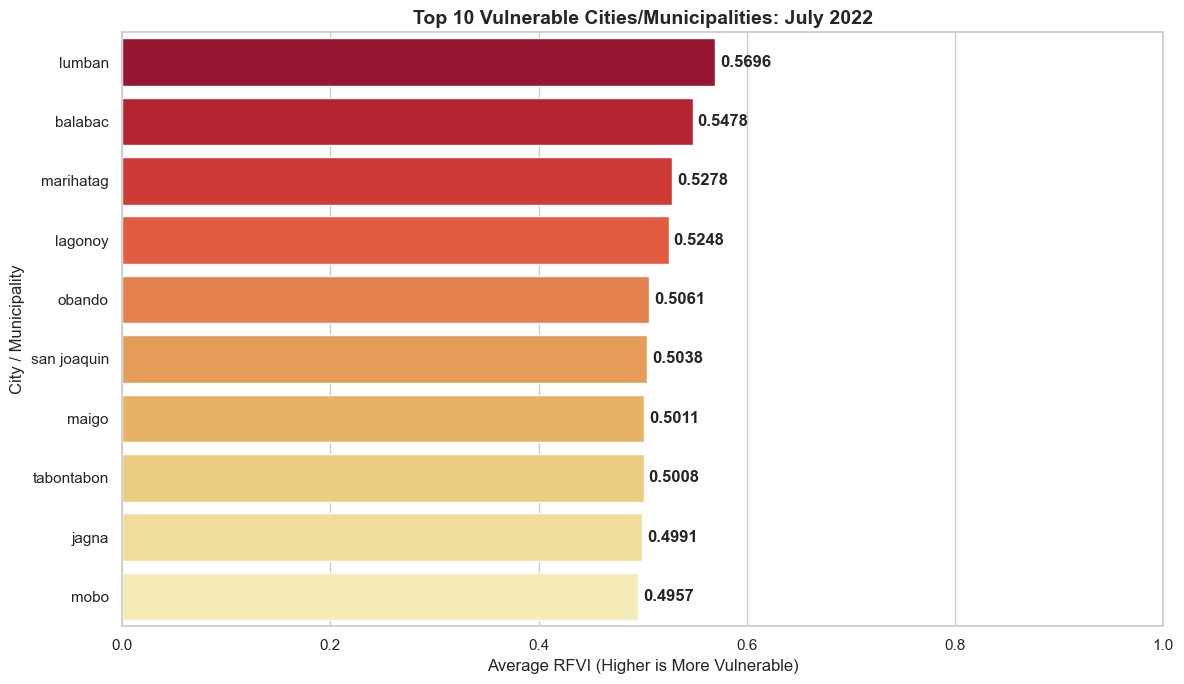

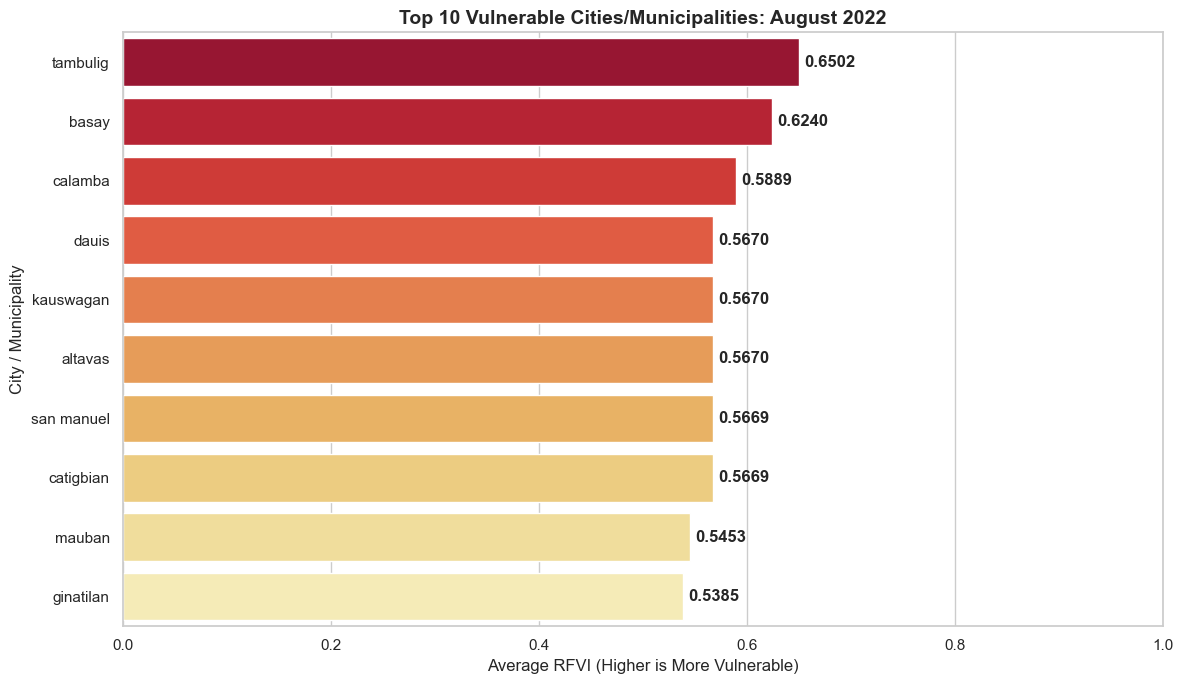

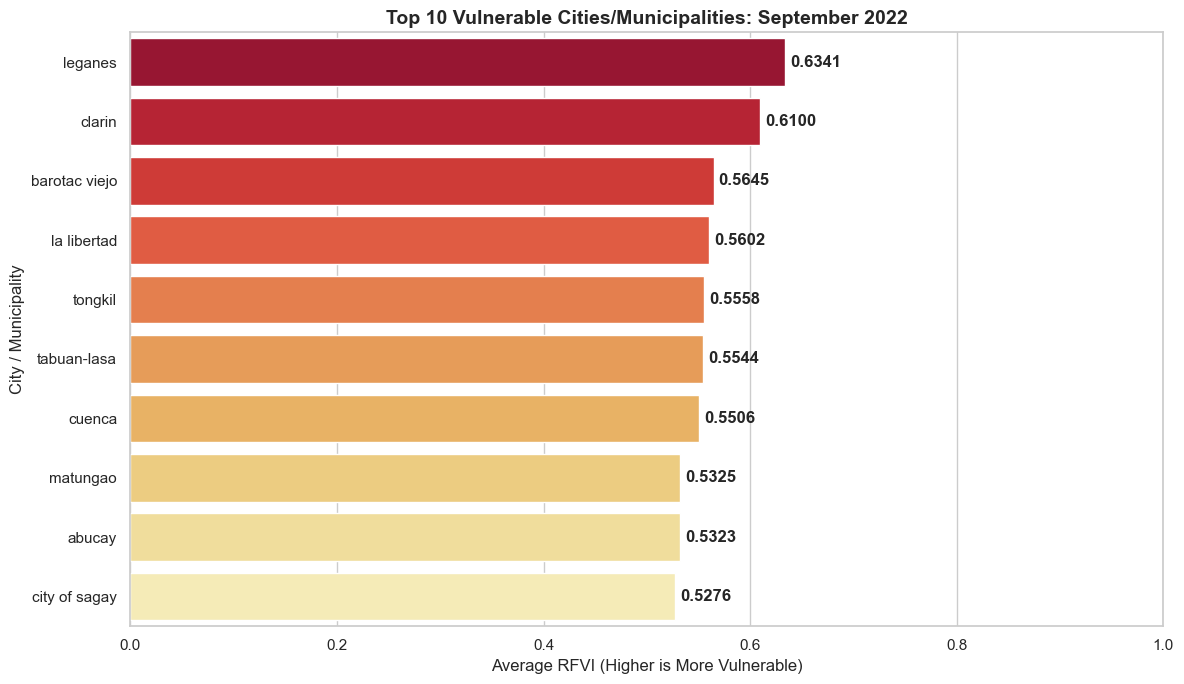

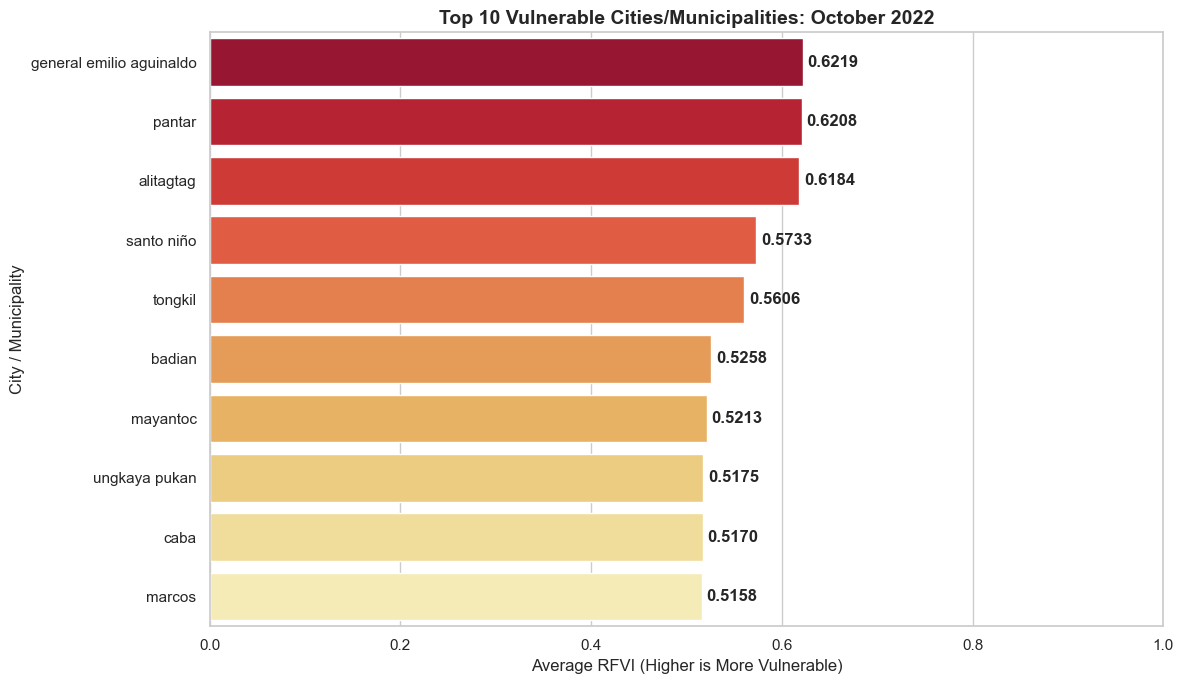

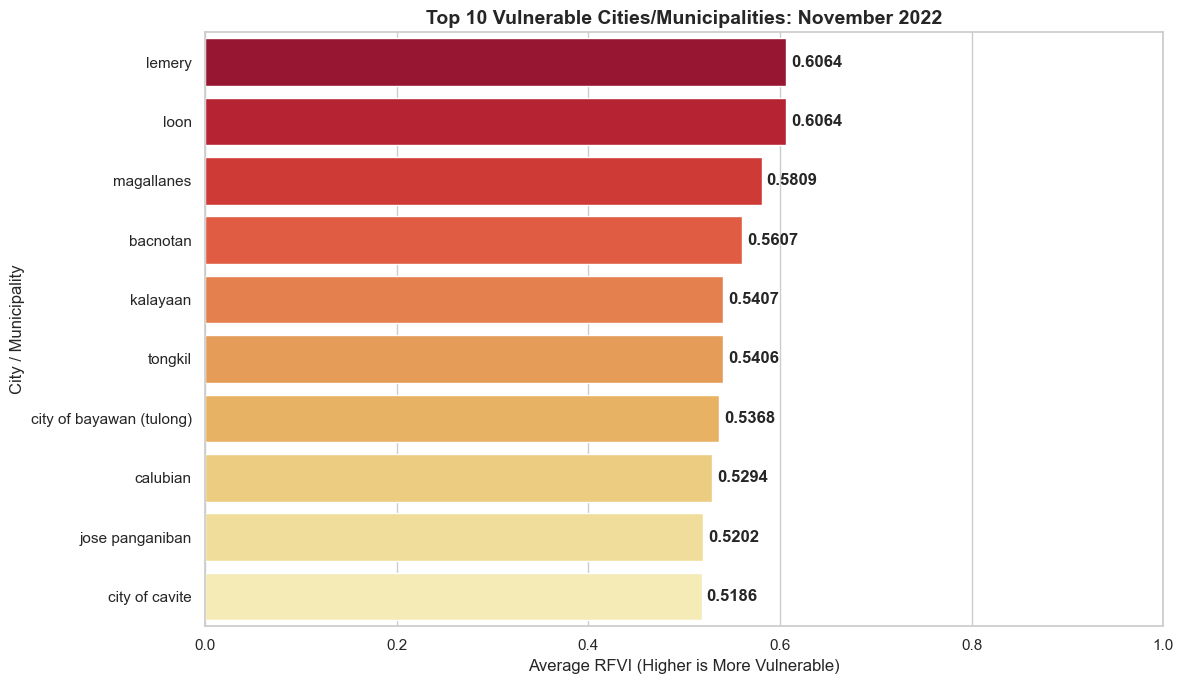

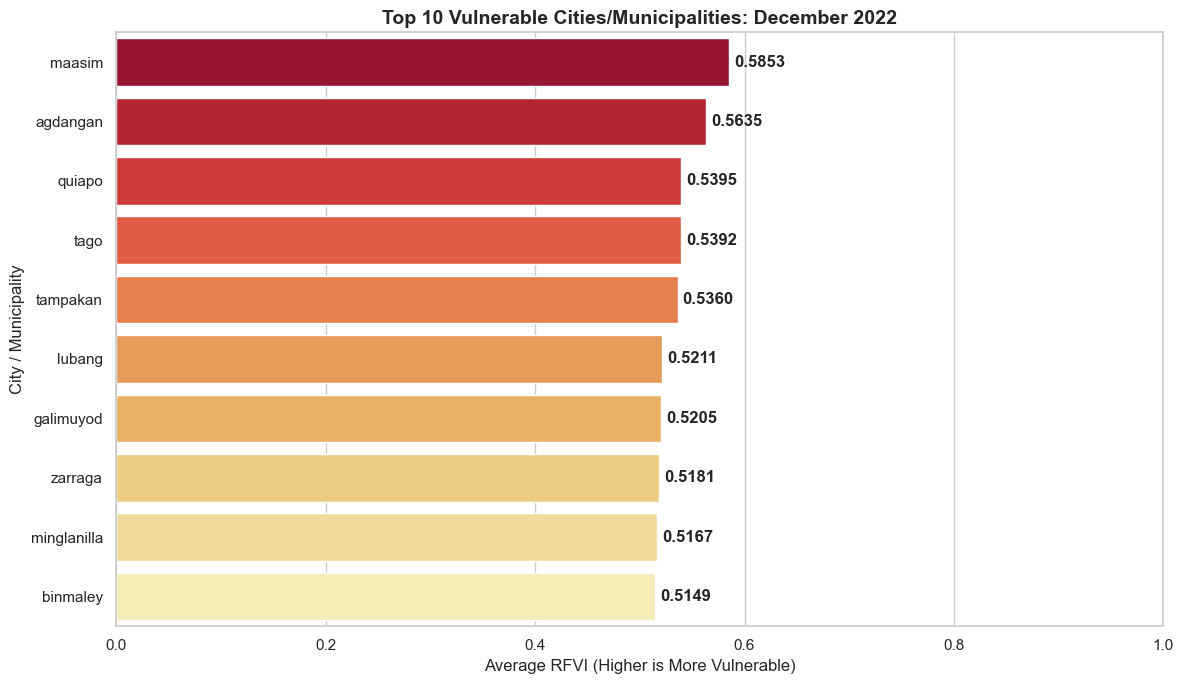

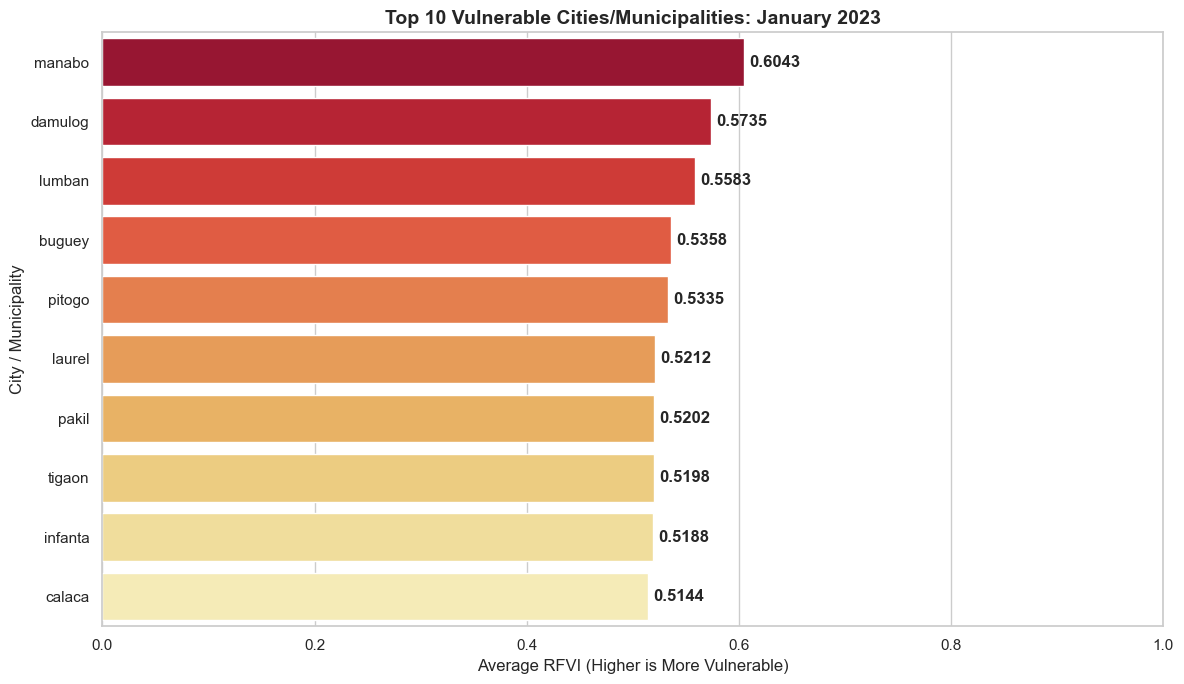

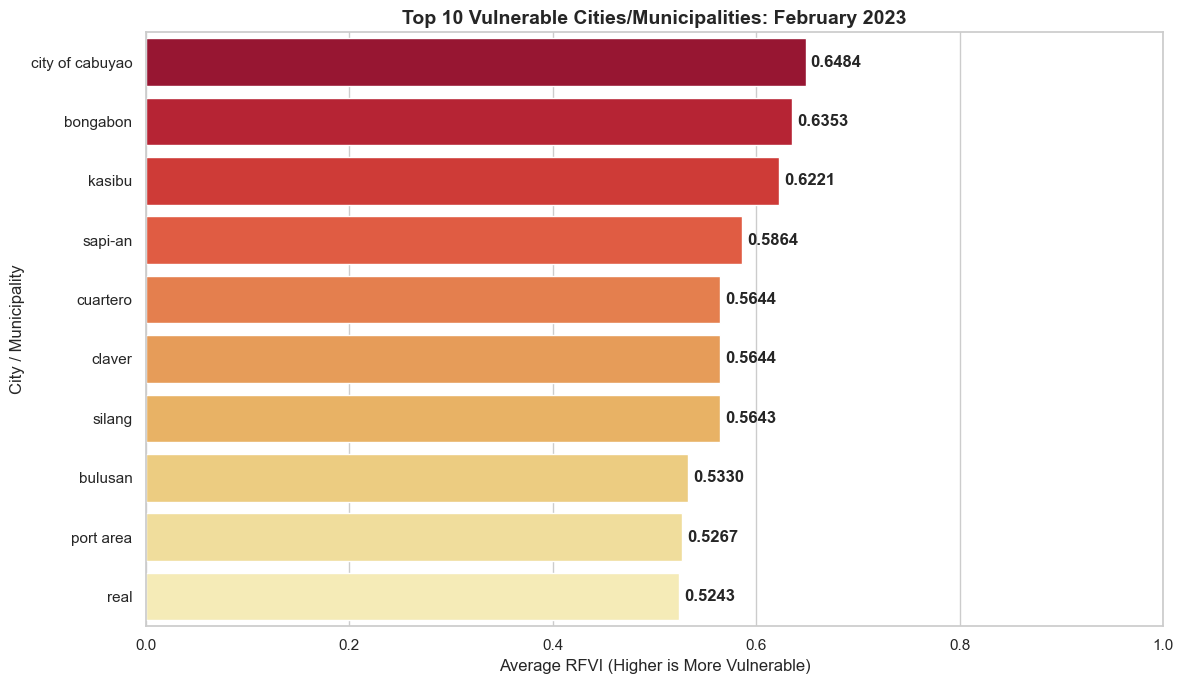

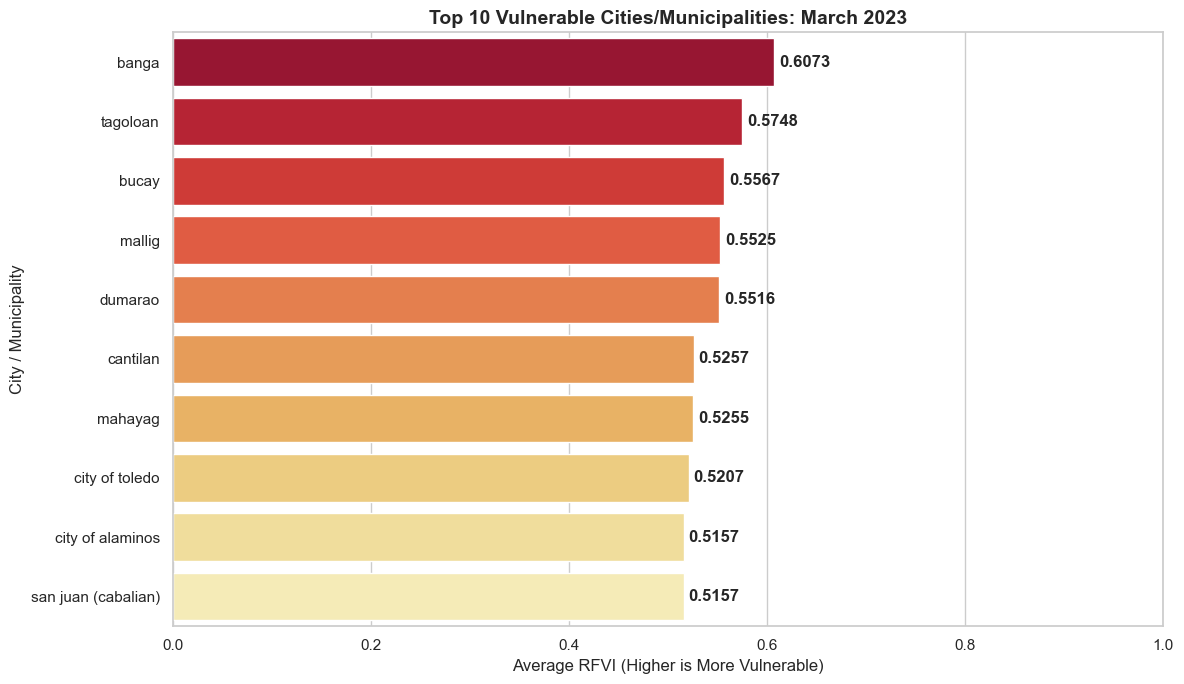

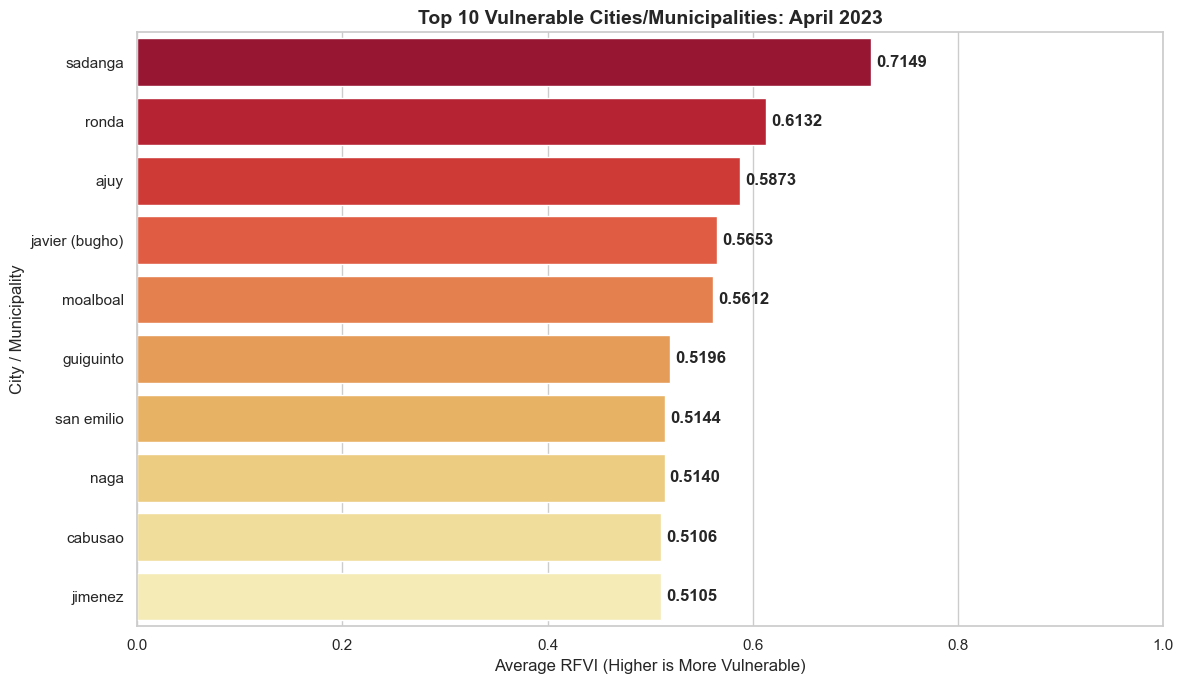

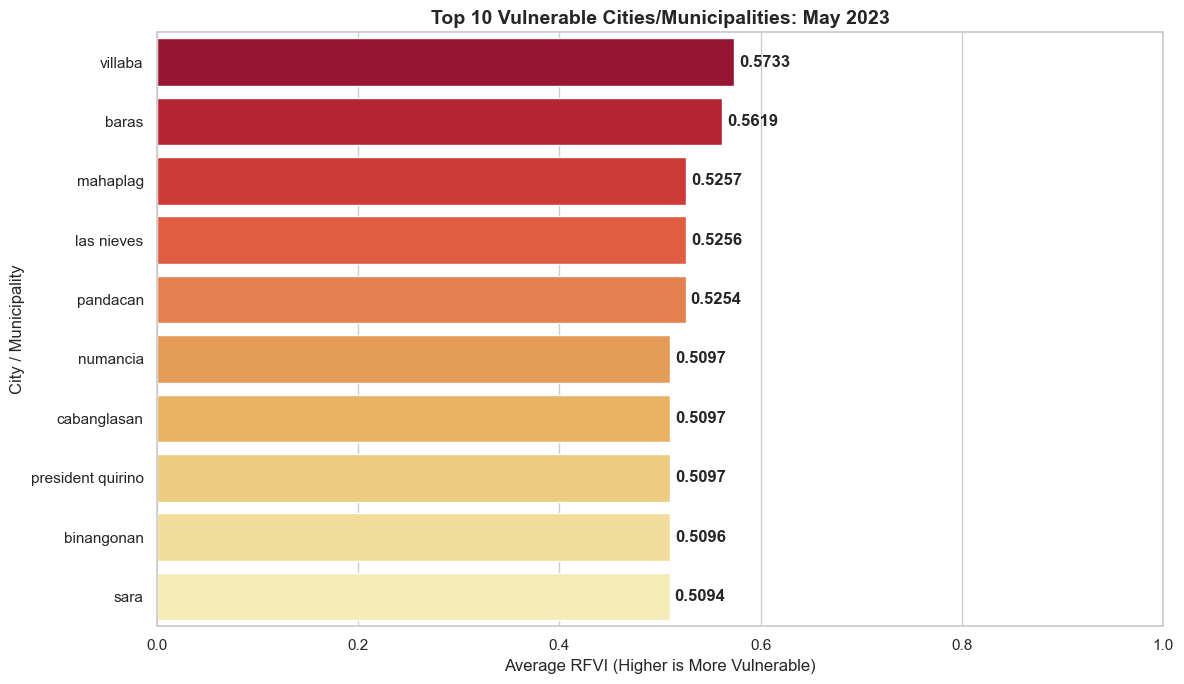

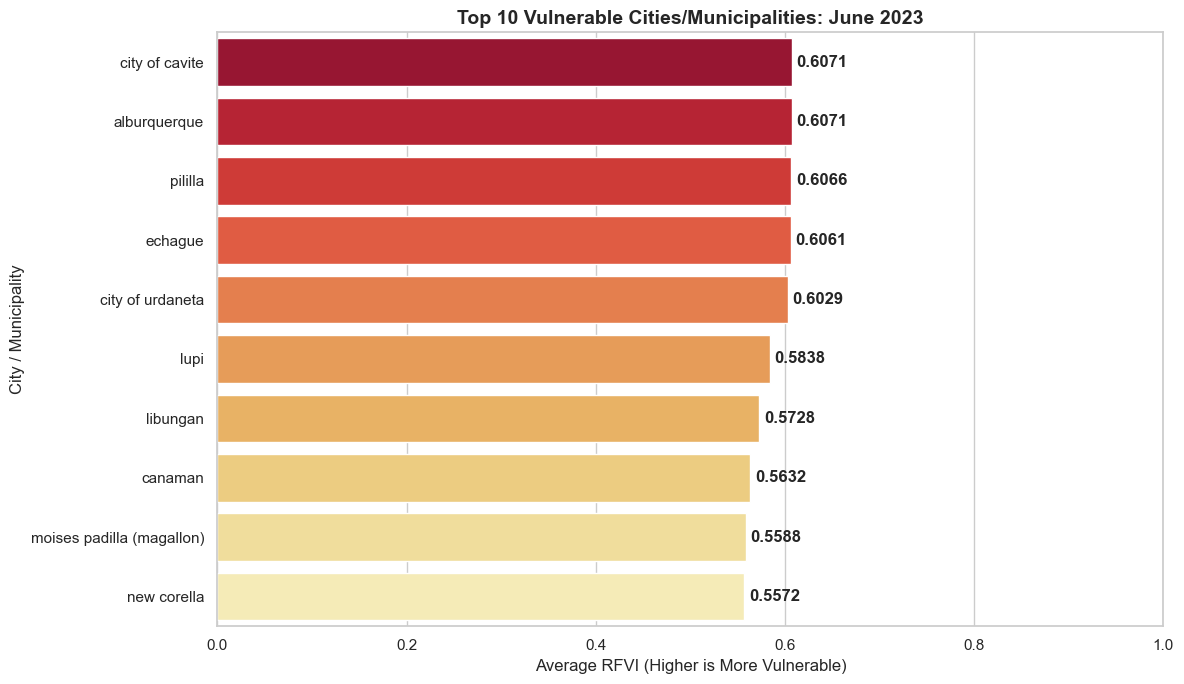

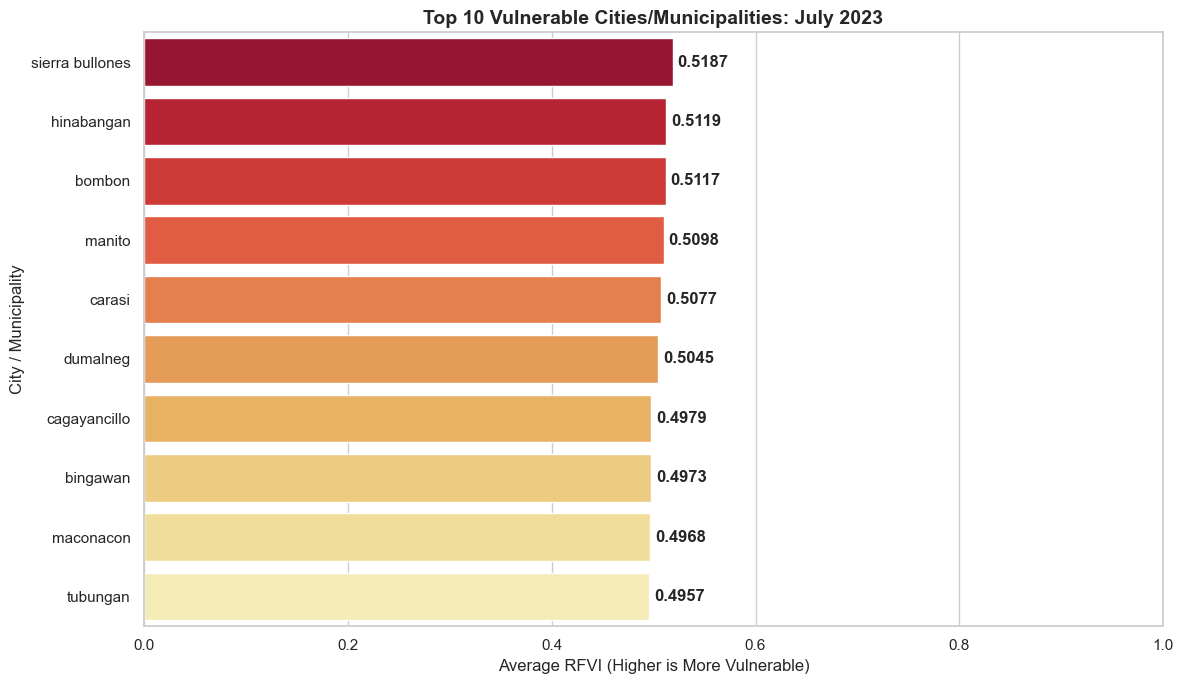

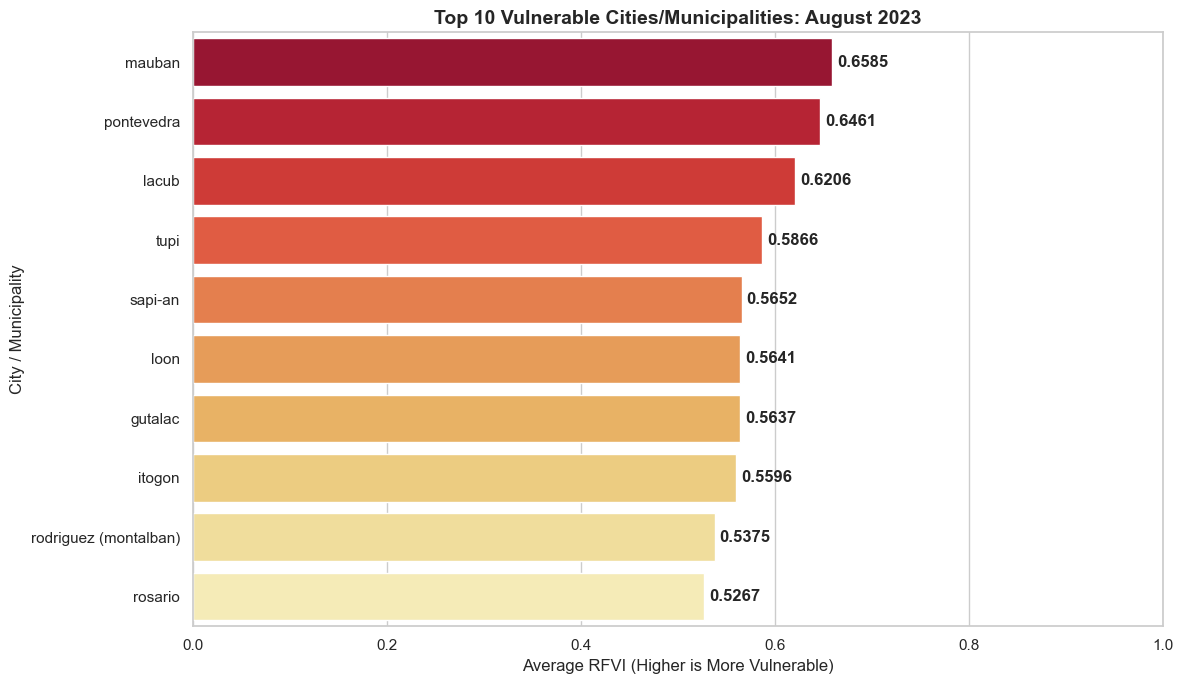

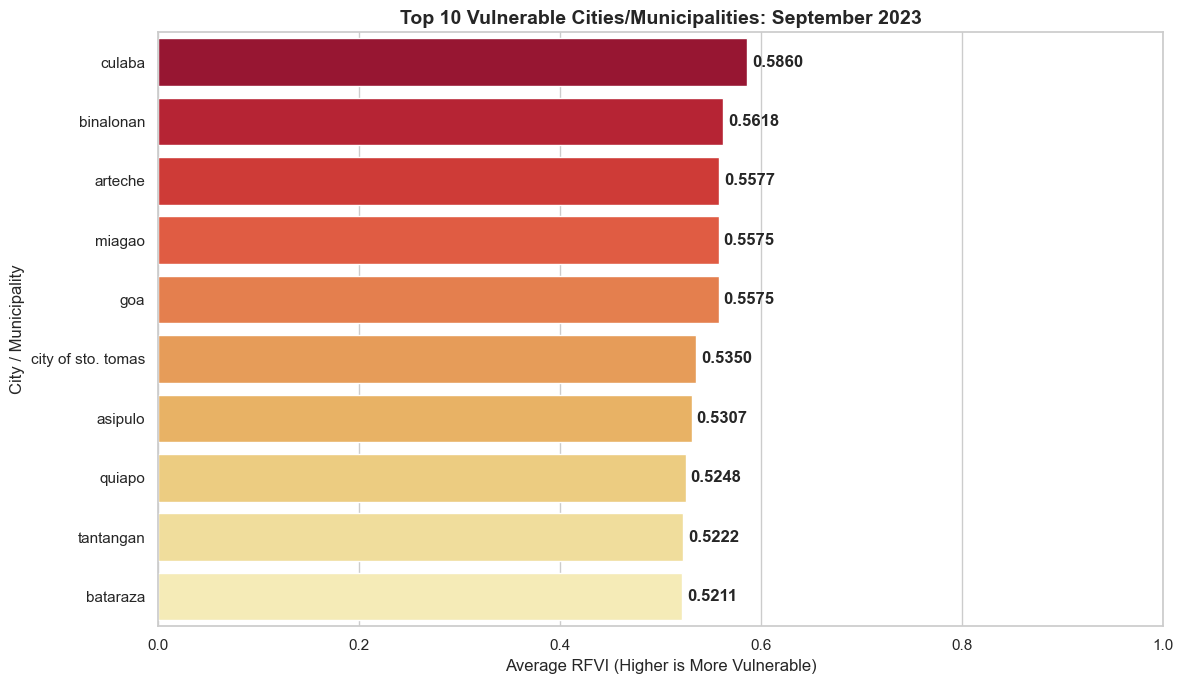

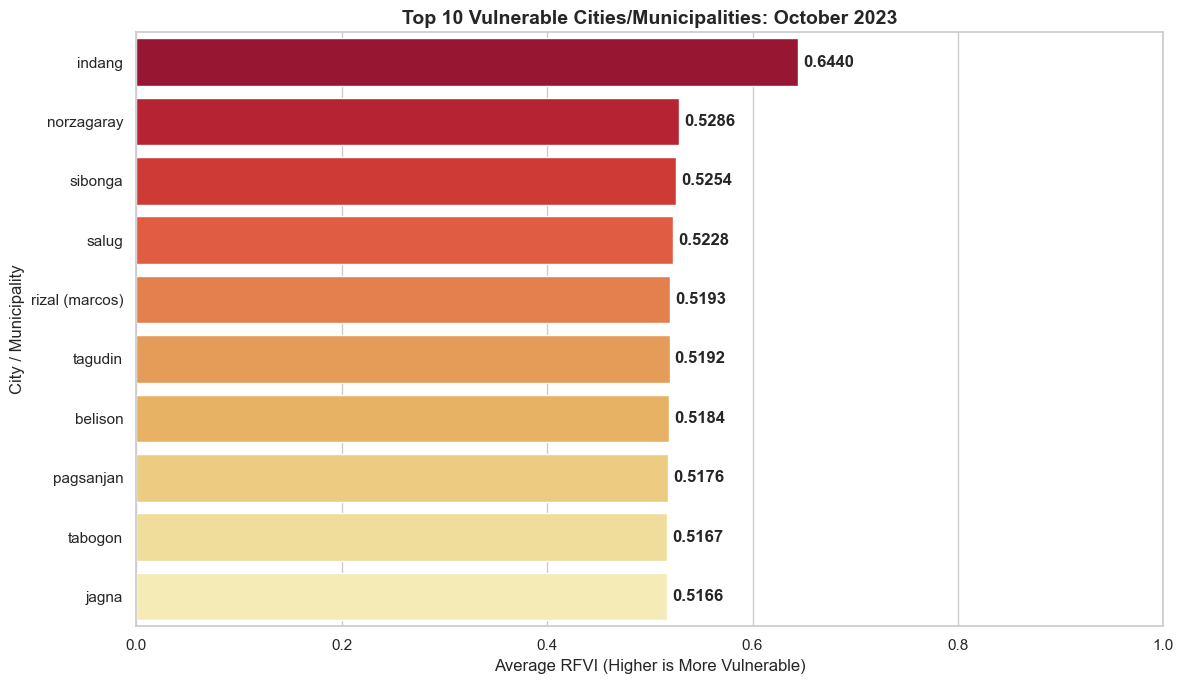

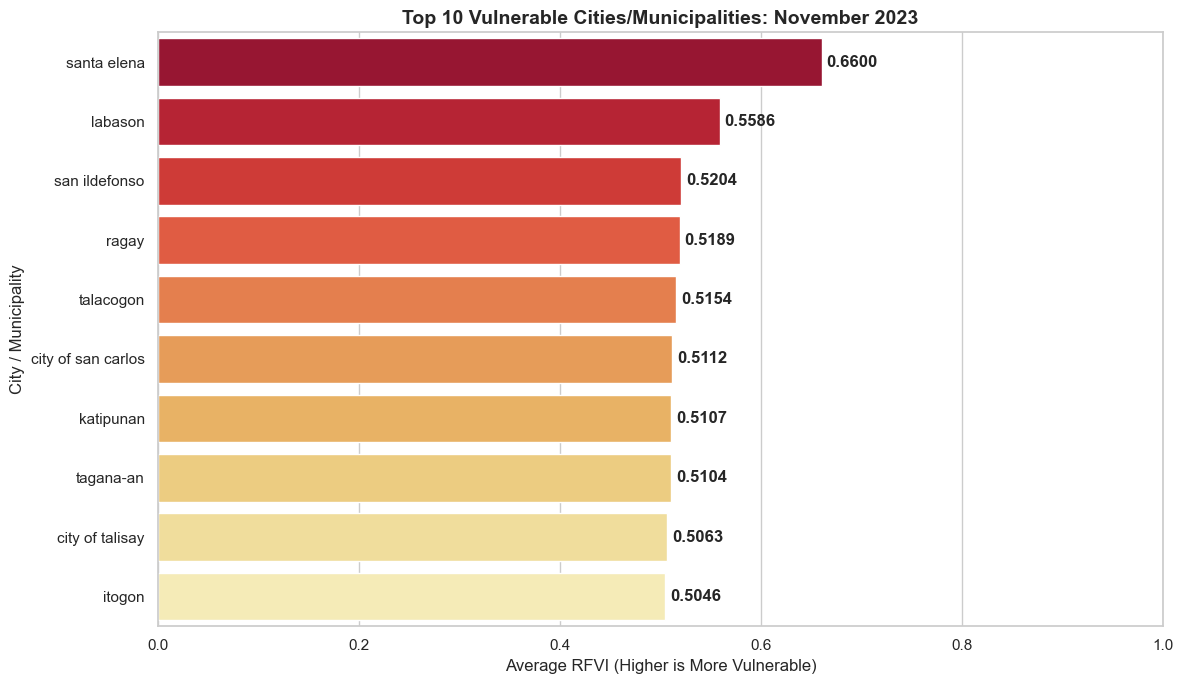

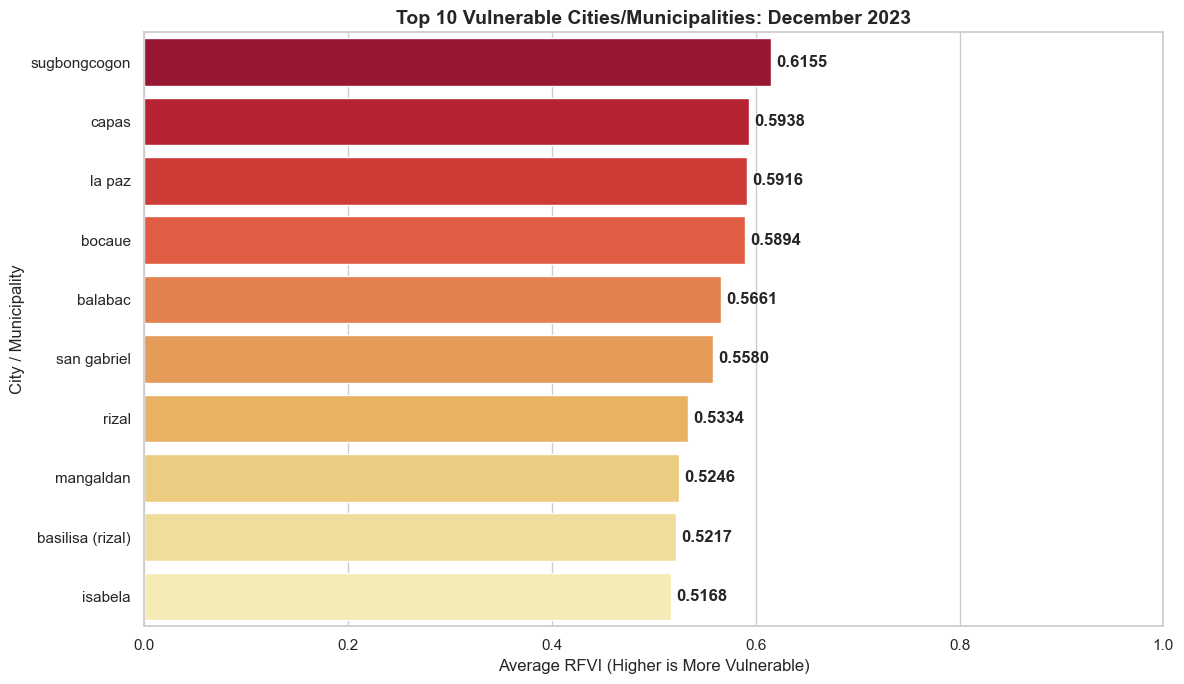

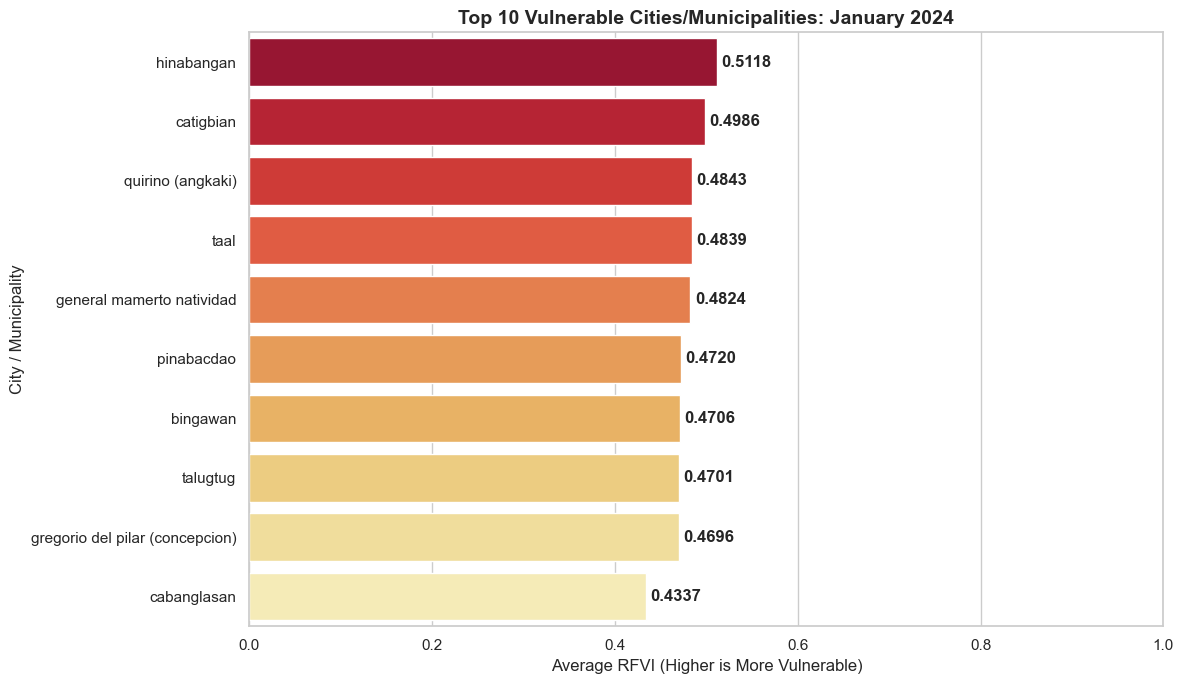

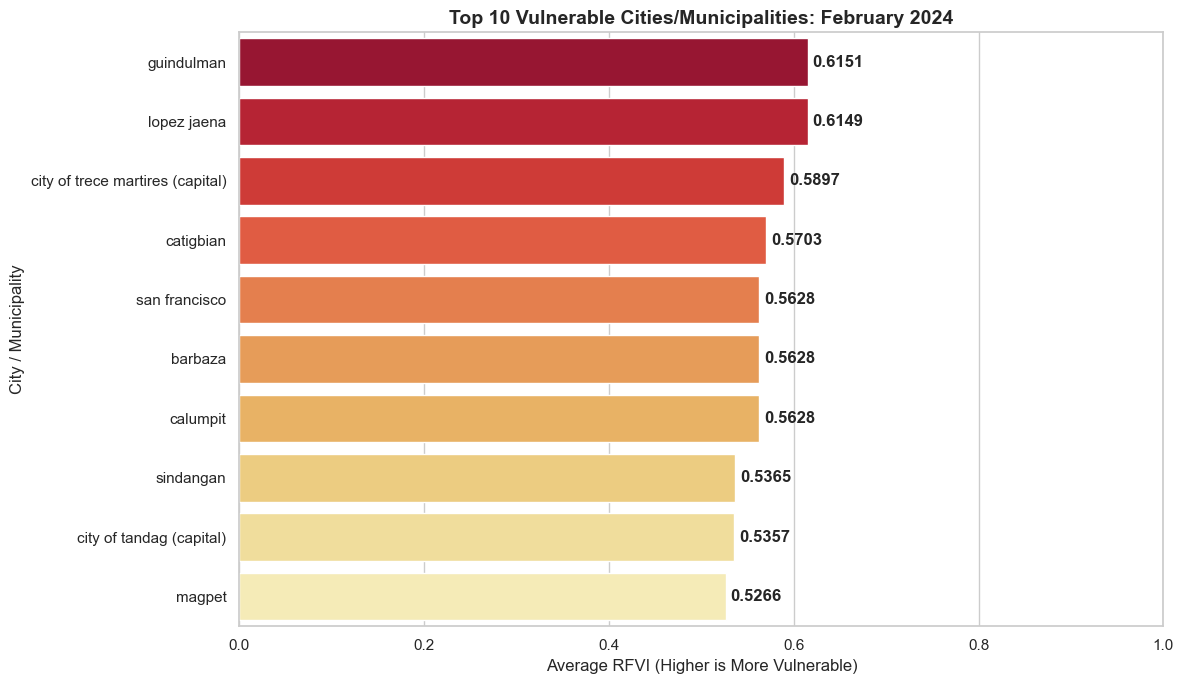

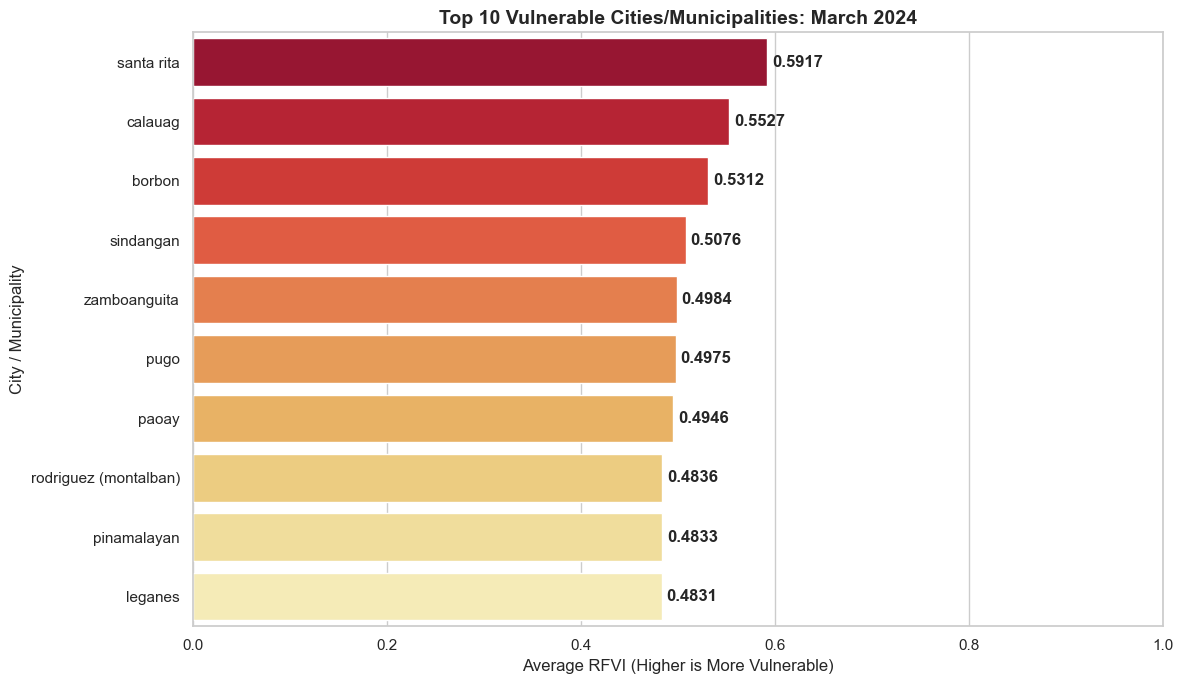

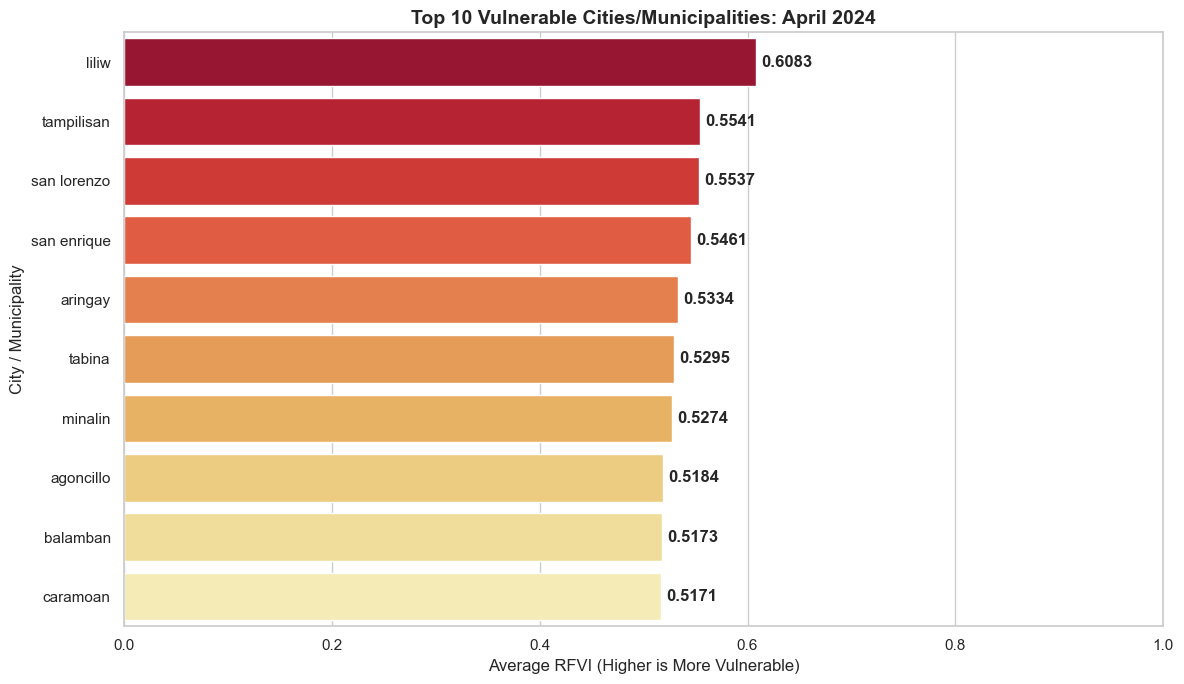

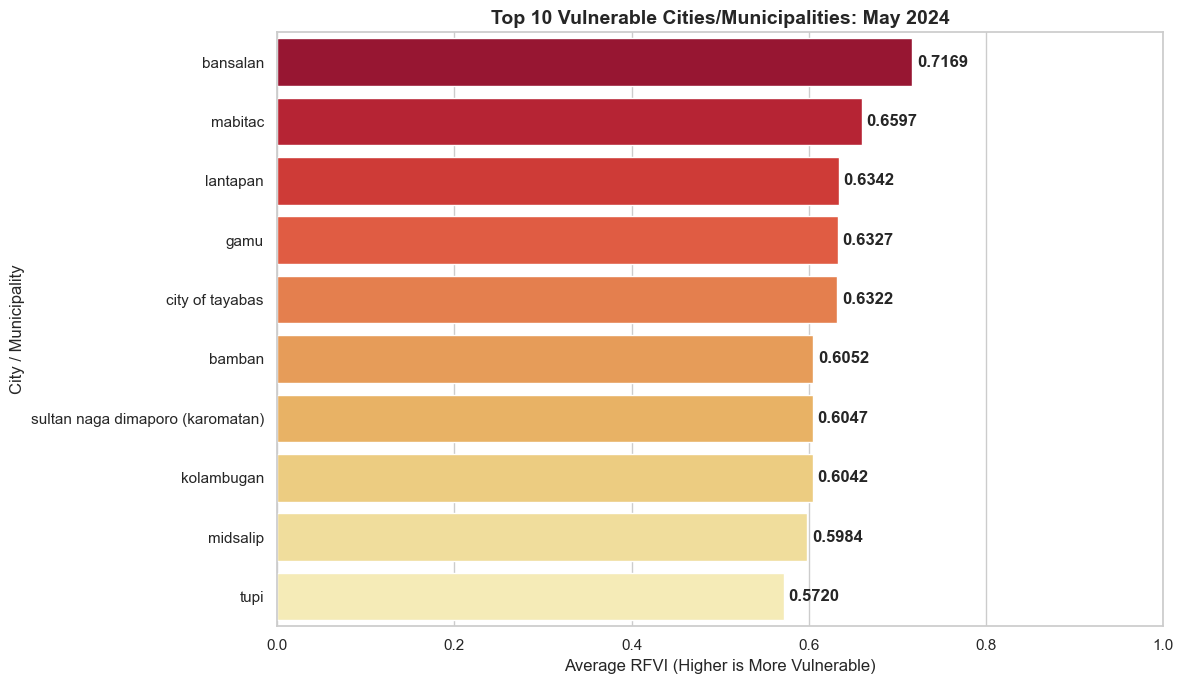

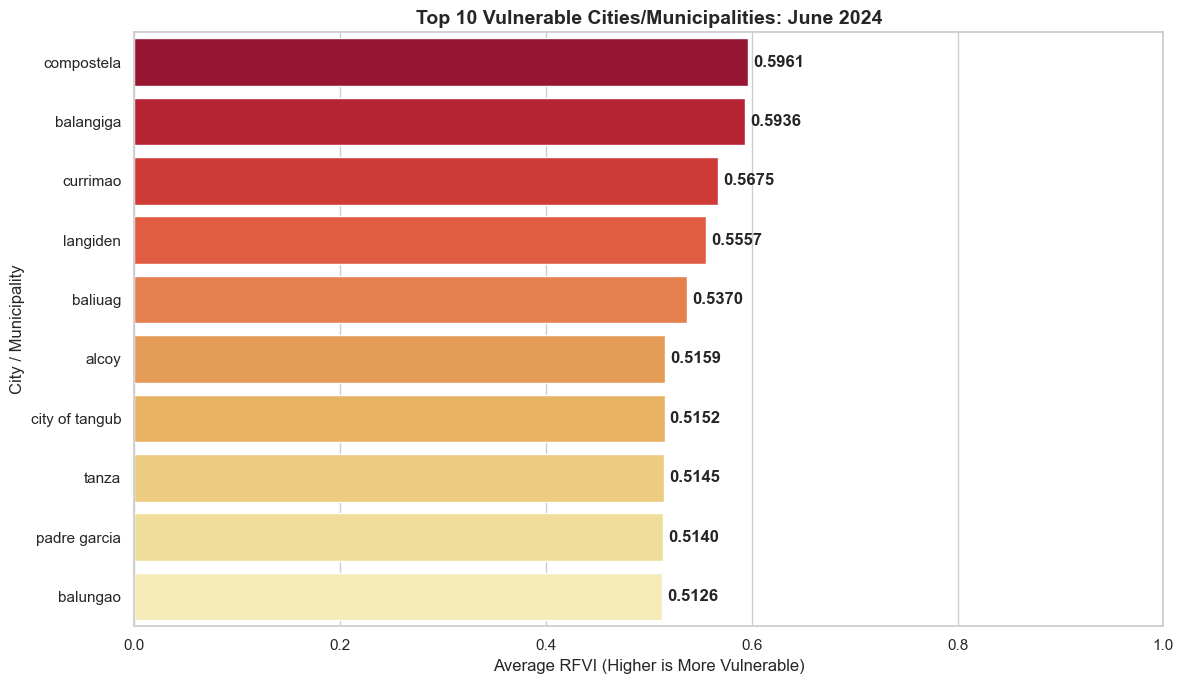

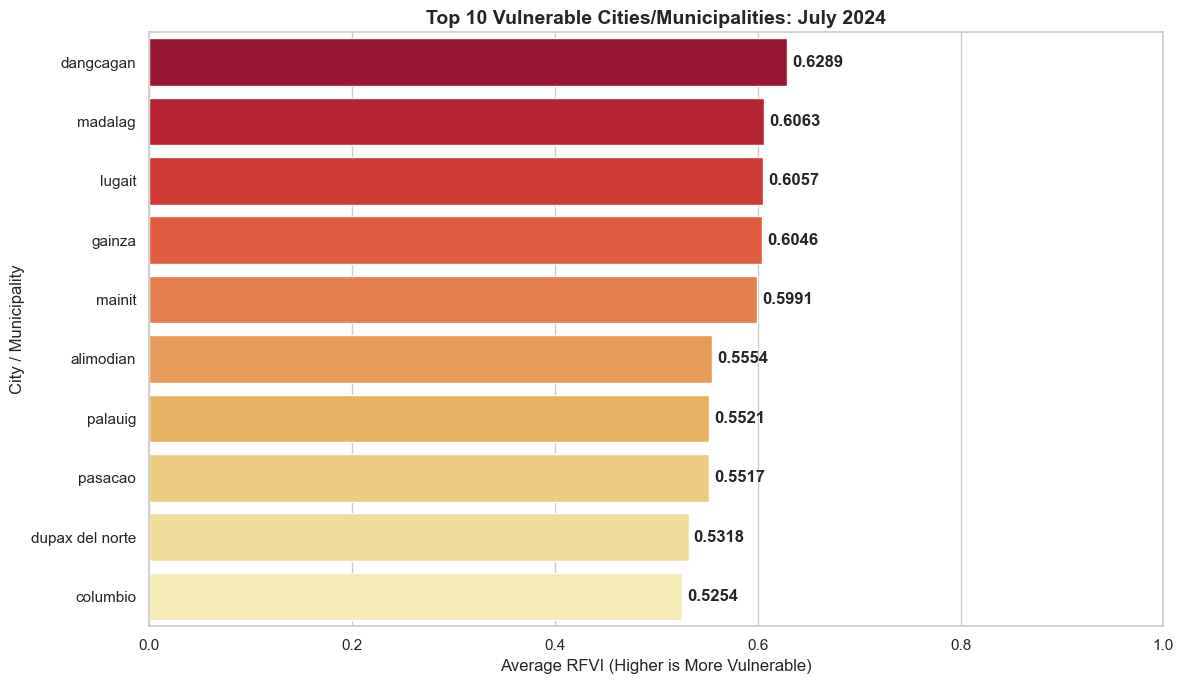

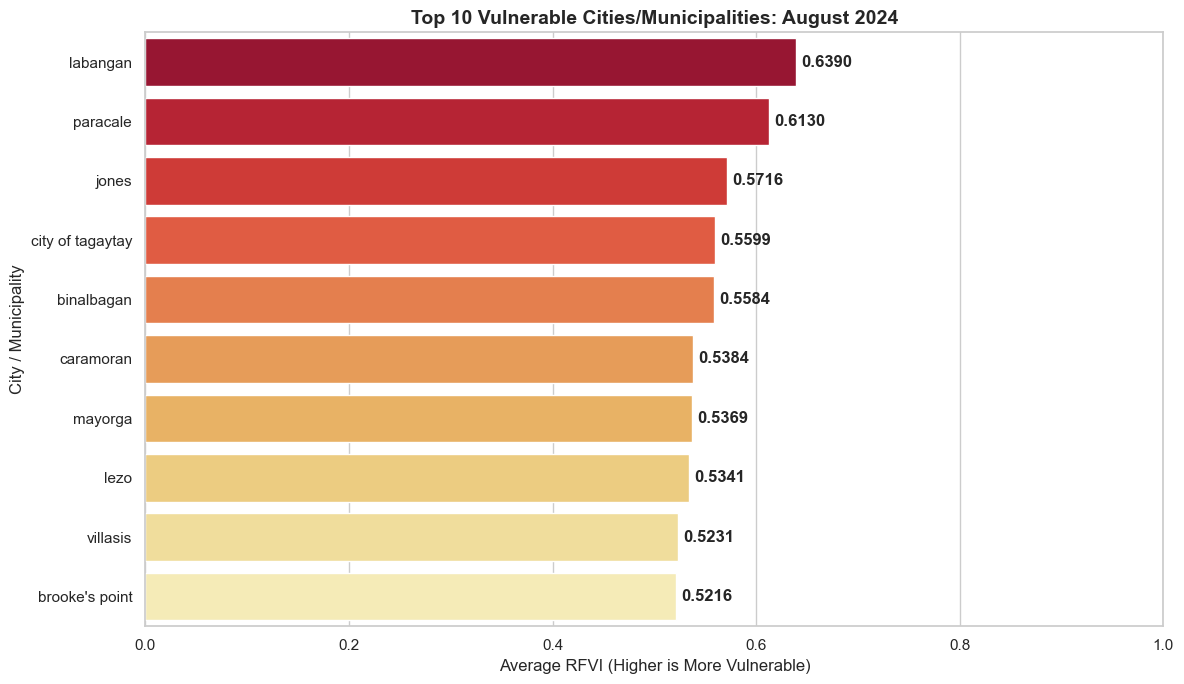

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import gc

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
except Exception as e:
    print(f"Error loading config: {e}")

# Helper for chronological sorting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

def plot_top_10_cities_per_month():
    # 1. Get and sort folders chronologically
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    
    def sort_key(f):
        parts = f.name.split('_') 
        return (int(parts[0]), month_order.index(parts[1]))
    
    sorted_folders = sorted(folders, key=sort_key)

    print(f"Generating City/Municipality rankings for {len(sorted_folders)} months...")
    print("-" * 50)

    for folder in sorted_folders:
        file_path = folder / f"RFVI_{folder.name}.csv"
        year_val, month_val = folder.name.split('_')
        
        if file_path.exists():
            try:
                # 2. Load data
                df = pd.read_csv(file_path, usecols=['City_Municipality', 'RFVI'], low_memory=False)
                
                # --- FILTERING STEP ---
                # Remove 'Unknown City' 
                df = df[df['City_Municipality'].astype(str).str.strip().str.lower() != 'unknown city']
                
                # --- CHECK IF DATA EXISTS AFTER FILTERING ---
                if df.empty:
                    print(f"No City/Municipality in:\n{month_val} {year_val}")
                    print("-" * 30)
                    continue # Skip to the next folder/month
                
                # 3. Calculate mean per City/Municipality
                city_rank = df.groupby('City_Municipality')['RFVI'].mean().reset_index()
                
                # Sort and take top 10
                top_10_cities = city_rank.sort_values('RFVI', ascending=False).head(10)

                # 4. Plotting
                plt.figure(figsize=(12, 7))
                sns.set_theme(style="whitegrid")
                
                sns.barplot(
                    data=top_10_cities, 
                    x='RFVI', 
                    y='City_Municipality', 
                    palette='YlOrRd_r', 
                    hue='City_Municipality',
                    legend=False
                )

                plt.title(f"Top 10 Vulnerable Cities/Municipalities: {month_val} {year_val}", 
                          fontsize=14, weight='bold')
                plt.xlabel("Average RFVI (Higher is More Vulnerable)")
                plt.ylabel("City / Municipality")
                plt.xlim(0, 1.0)

                # Add numeric labels to bars
                for i, val in enumerate(top_10_cities['RFVI']):
                    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontweight='bold')

                plt.tight_layout()
                plt.show() 
                plt.close()

                # Clean up
                del df, city_rank, top_10_cities
                gc.collect()

            except Exception as e:
                print(f"   [SKIP] Error in {folder.name}: {e}")

if __name__ == "__main__":
    plot_top_10_cities_per_month()

Key Insight:

- The **top 10 most vulnerable cities or municipalities changes from month to month**, indicating that city-level RFVI rankings are dynamic rather than fixed.
- Rankings may shift due to actual changes in vulnerability or differences in survey coverage each month.

Implication:

City/municipality rankings should be viewed as specific to each survey period.

Monthly results help highlight which cities or municipalities are most vulnerable at a given time, but longer-term averages are needed to see consistent patterns over time.

---
### Regional Vulnerability SRE Distribution (2018-2024)

After constructing the RFVI, the three pillars are aggregated at the regional level to identify the **structural drivers of vulnerability**.

The process:
- Reconstructs regional averages from monthly datasets containing SRE scores and RFVI
- Computes overall regional means (2018-2024)
- Ranks regions by RFVI (highest to lowest vulnerability)

The visualization:
- Displays Sensitivity, Exposure, and Resilience per region
- Identifies whether vulnerability is driven by internal fragility, external shocks, or weak adaptive capacity
- Enhances interpretability prior to clustering

This establishes the validated regional vulnerability structure before clustering analysis.

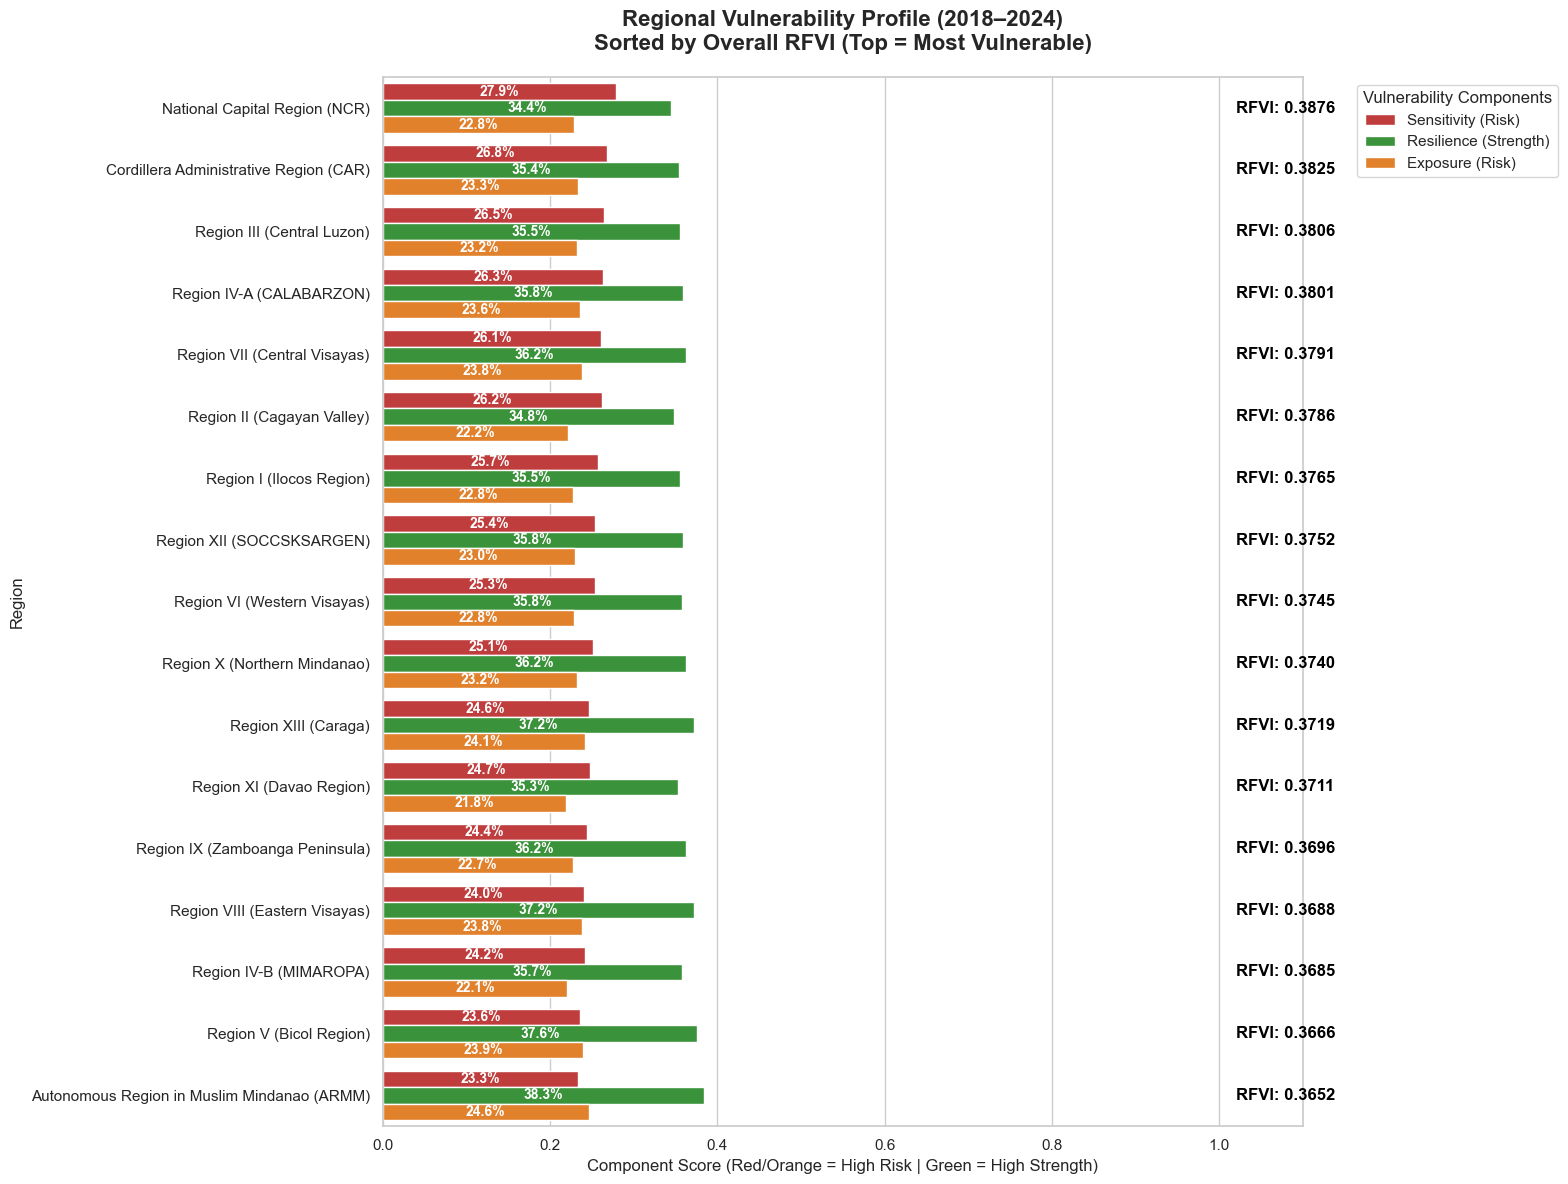

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import gc

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
except Exception as e:
    print(f"Error loading config: {e}")

def plot_self_explanatory_sre():
    # 1. Aggregate Regional Data
    folders = [d for d in SOURCE_DIR.iterdir() if d.is_dir()]
    all_means = []

    for folder in folders:
        file_path = folder / f"RFVI_{folder.name}.csv"
        if file_path.exists():
            try:
                # Load scores and RFVI
                df = pd.read_csv(file_path, usecols=['Region', 'Sensitivity_norm', 'Resilience_norm', 'Exposure_norm', 'RFVI'])
                monthly_avg = df.groupby('Region').mean().reset_index()
                all_means.append(monthly_avg)
                del df
                gc.collect()
            except Exception as e:
                print(f"   [SKIP] {folder.name}: {e}")

    # 2. Grand Average Calculation
    master_df = pd.concat(all_means, ignore_index=True)
    overall_sre = master_df.groupby('Region').mean().reset_index()

    # --- 3. SORTING ---
    # Sorted by RFVI (Highest Overall Vulnerability at the top)
    overall_sre = overall_sre.sort_values('RFVI', ascending=False)
    region_order = overall_sre['Region'].tolist()

    # --- 4. TRANSFORM FOR PLOTTING ---
    melted_df = overall_sre.melt(
        id_vars='Region', 
        value_vars=['Sensitivity_norm', 'Resilience_norm', 'Exposure_norm'],
        var_name='Dimension', 
        value_name='Score'
    )

    # 5. PLOTTING
    plt.figure(figsize=(16, 12))
    sns.set_theme(style="whitegrid")

    # Define a custom "Traffic Light" palette for immediate understanding
    # Sensitivity = Red (Risk), Exposure = Orange (Risk), Resilience = Green (Strength)
    custom_palette = {
        'Sensitivity_norm': '#d62728', # Red
        'Exposure_norm': '#ff7f0e',    # Orange
        'Resilience_norm': '#2ca02c'   # Green
    }

    ax = sns.barplot(
        data=melted_df,
        x='Score',
        y='Region',
        hue='Dimension',
        order=region_order,
        palette=custom_palette
    )

    # --- 6. ADD PERCENTAGE LABELS ---
    for p in ax.patches:
        width = p.get_width()
        if width > 0.04: 
            ax.annotate(f'{width*100:.1f}%', 
                        (width / 2, p.get_y() + p.get_height() / 2),
                        ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=10)

    # Formatting
    plt.title("Regional Vulnerability Profile (2018–2024)\nSorted by Overall RFVI (Top = Most Vulnerable)", 
              fontsize=16, weight='bold', pad=20)
    plt.xlabel("Component Score (Red/Orange = High Risk | Green = High Strength)", fontsize=12)
    plt.ylabel("Region", fontsize=12)
    
    # Clean up Legend Labels
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ['Sensitivity (Risk)', 'Resilience (Strength)', 'Exposure (Risk)']
    plt.legend(handles, new_labels, title='Vulnerability Components', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xlim(0, 1.1)

    # Add RFVI value labels on the right
    for i, region in enumerate(region_order):
        rfvi_val = overall_sre.loc[overall_sre['Region'] == region, 'RFVI'].values[0]
        plt.text(1.02, i, f'RFVI: {rfvi_val:.4f}', va='center', fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_self_explanatory_sre()

Key Insight

- **Resilience is consistently the highest component** across all regions, indicating that regions generally have stronger coping capacity relative to risk.
- **Sensitivity and Exposure vary in their relative heights**, showing that the level of risk differs across regions and months.
- The **gap between components changes**. In some months the difference between Resilience and risk components is large, while in others it is smaller.

Implication

- Regions are strongest in Resilience, but variations in Sensitivity and Exposure mean that some regions are more at certain risk during certain periods.
- Monitoring all three components together provides a more complete picture of regional vulnerability than looking at overall RFVI alone.